In [14]:
#import pygad
#import pyeasyga
#import pymoo
#import evopy


In [ ]:
import math
import sys
import numpy as np
!{sys.executable} -m pip install matplotlib
import random
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install deap

import deap

!{sys.executable} -m pip install cellpylib
import cellpylib as cpl


!{sys.executable} -m pip install py_casim
from py_casim import Casim

#import multiprocessing
#from multiprocessing import Pool

from deap import base, creator, tools
from joblib import Parallel, delayed
import time
import os

In [20]:


#Parámetros AG
IND_SIZE = int(pow(NUM_STATES, 2*VEC_SIZE + 1))
POP_SIZE = 180
CXPB, MUTPB, NGEN = 0.85, 0.03, 320

#Parámetros AC
NUM_STATES = 2
VEC_SIZE = 3
CA_NUM = 125
CA_SIZE = 50
CA_TIMESTEPS = 75


#Creador de fitness y de individuo
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

#Especificación de genes, individuos y poblacion
toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, IND_SIZE)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


#Creador de regla de transición a partir de diccionario de reglas
def create_transition_rule(rule_dict):
    def my_rule(cells, r, t):
        # cells es un array con 2*r+1 elementos
        key = ''.join(str(int(c)) for c in cells)
        return rule_dict[key]
    return my_rule

#Función de fitness
def evaluate_CA_Majority(individual):
    densities = np.linspace(0.0, 1.0, CA_NUM)

    CAs = []


    for i in range(CA_NUM):
        numbers = np.random.rand(CA_SIZE)
        ca_binario = (numbers <= densities[i]).astype(int)

        CAs.append(np.expand_dims(ca_binario, axis=0))

    majority = [1 if np.sum(ca) >= CA_SIZE/2 else 0 for ca in CAs]

    #Diccionario de reglas
    rule_dict = {}
    for i in range(len(individual)):
        binario = format(i, f'0{2*VEC_SIZE + 1}b')
        rule_dict[binario] = individual[i]
    mi_regla = create_transition_rule(rule_dict)

    #Evolucionar autómatas con la regla con paralelización
    evolved_CAs = []
    for i in range(len(CAs)):
        evolved_CA = cpl.evolve(CAs[i], timesteps=CA_TIMESTEPS, apply_rule=mi_regla, r=VEC_SIZE)
        evolved_CAs.append(evolved_CA)

    CAs = evolved_CAs


    #Estudiamos
    common_cells = []

    for i in range(len(CAs)):  # para cada autómata
        common_cells.append(np.sum(CAs[i][-1] == majority[i]))


    success = np.sum(np.array(common_cells) == CA_SIZE)


    return (success/CA_NUM,)


toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb = MUTPB)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate_CA_Majority)

def GA():
    pop = toolbox.population(n=POP_SIZE)


    # Evaluar toda la población
    fitnesses = Parallel(n_jobs=-1)(delayed(toolbox.evaluate)(ind) for ind in pop)
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    for g in range(NGEN):
        # Seleccionar la siguiente generación
        offspring = toolbox.select(pop, len(pop))
        offspring = list(map(toolbox.clone, offspring))

        # Cruce y mutación
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < CXPB:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < MUTPB:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluar individuos con fitness inválido
        #Ver condicion de parada de fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = Parallel(n_jobs=-1)(delayed(toolbox.evaluate)(ind) for ind in invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        pop[:] = offspring

        #top = tools.selBest(pop, 3)
        #if top[0].fitness.values[0] >= 0.95: #Estudiar condición de parada
            #print(f"Parado en la generación {g} con fitness {top[0].fitness.values[0]}")
            #return top

    return tools.selBest(pop, 3)


--- Catálogo de Reglas del AC (Índice -> Configuración -> Resultado) ---
Índice 000:   □□□□□□□   ->   □
Índice 001:   □□□□□□■   ->   □
Índice 002:   □□□□□■□   ->   □
Índice 003:   □□□□□■■   ->   □
Índice 004:   □□□□■□□   ->   □
Índice 005:   □□□□■□■   ->   □
Índice 006:   □□□□■■□   ->   ■
Índice 007:   □□□□■■■   ->   □
Índice 008:   □□□■□□□   ->   □
Índice 009:   □□□■□□■   ->   ■
Índice 010:   □□□■□■□   ->   □
Índice 011:   □□□■□■■   ->   □
Índice 012:   □□□■■□□   ->   □
Índice 013:   □□□■■□■   ->   ■
Índice 014:   □□□■■■□   ->   □
Índice 015:   □□□■■■■   ->   □
Índice 016:   □□■□□□□   ->   □
Índice 017:   □□■□□□■   ->   □
Índice 018:   □□■□□■□   ->   ■
Índice 019:   □□■□□■■   ->   ■
Índice 020:   □□■□■□□   ->   □
Índice 021:   □□■□■□■   ->   ■
Índice 022:   □□■□■■□   ->   ■
Índice 023:   □□■□■■■   ->   ■
Índice 024:   □□■■□□□   ->   ■
Índice 025:   □□■■□□■   ->   ■
Índice 026:   □□■■□■□   ->   □
Índice 027:   □□■■□■■   ->   ■
Índice 028:   □□■■■□□   ->   □
Índice 029:   □□■■■□■   ->  

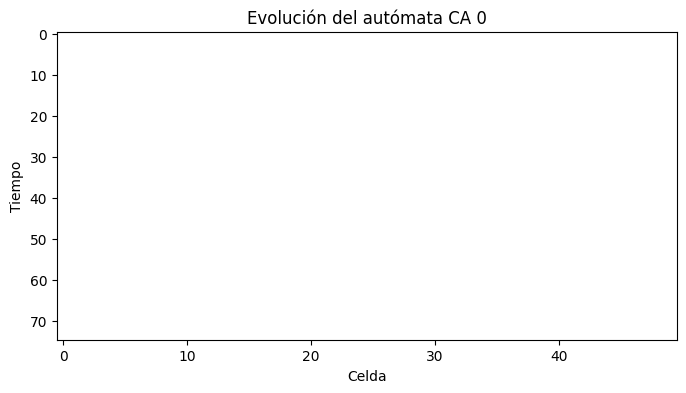

Estado uniforme final:  0


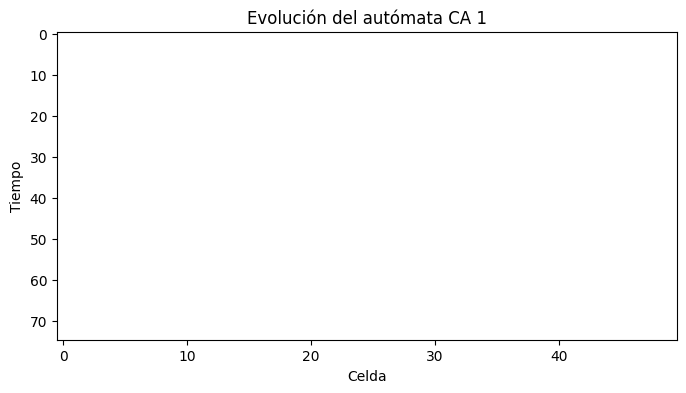

Estado uniforme final:  0


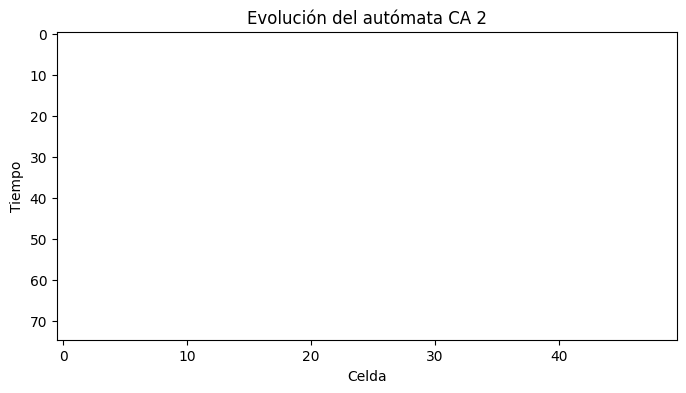

Estado uniforme final:  0


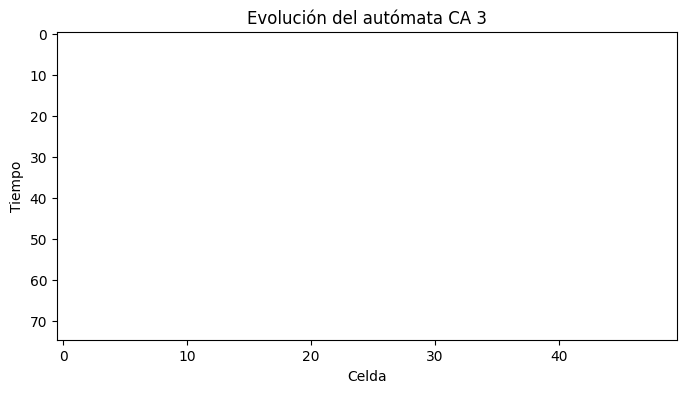

Estado uniforme final:  0


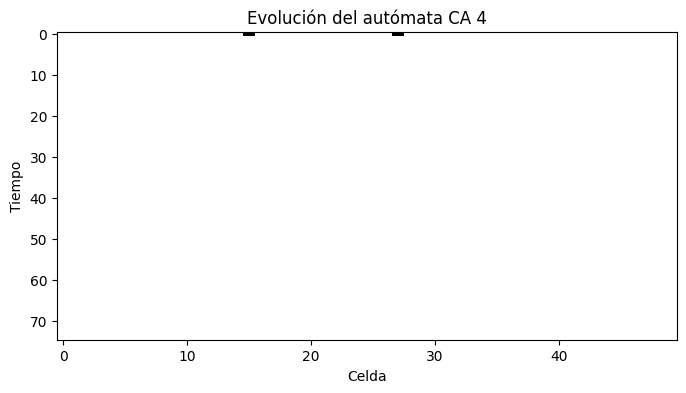

Estado uniforme final:  0


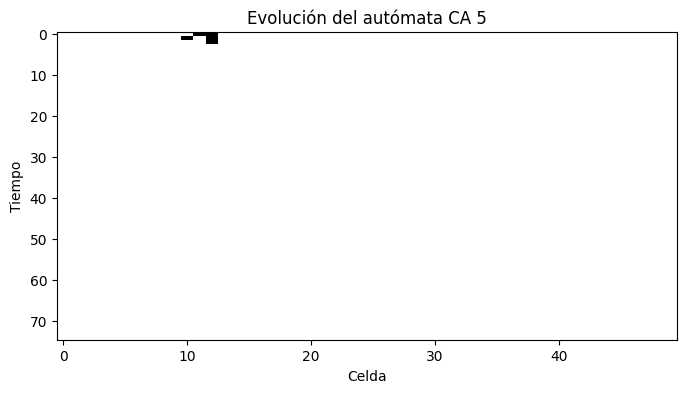

Estado uniforme final:  0


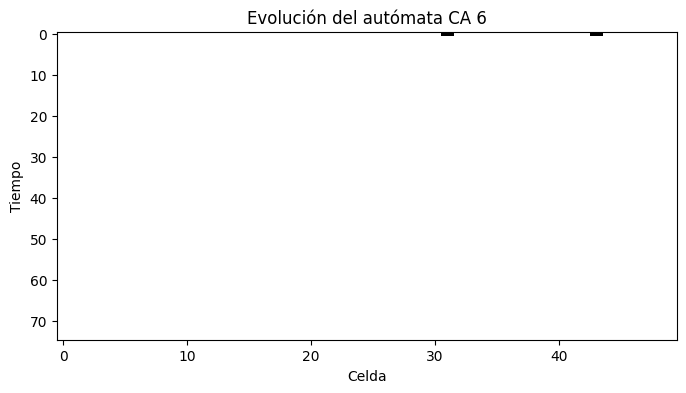

Estado uniforme final:  0


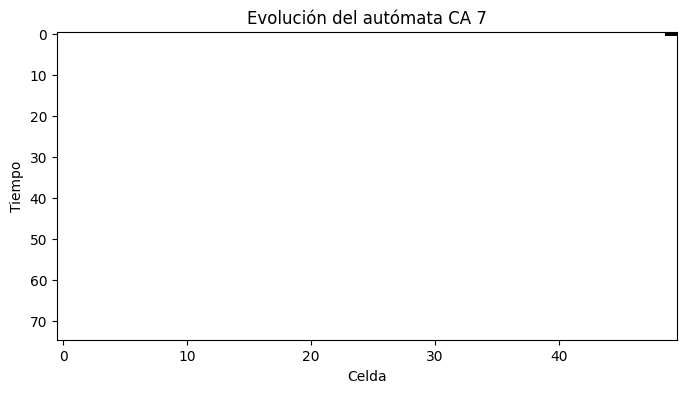

Estado uniforme final:  0


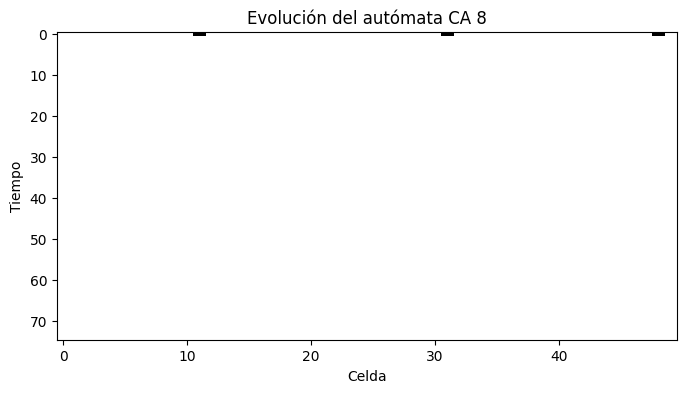

Estado uniforme final:  0


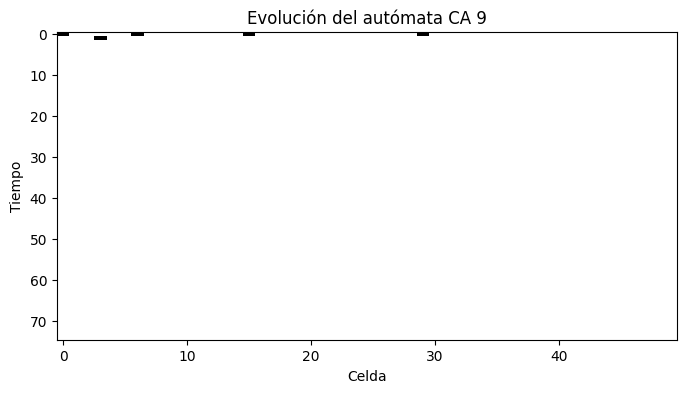

Estado uniforme final:  0


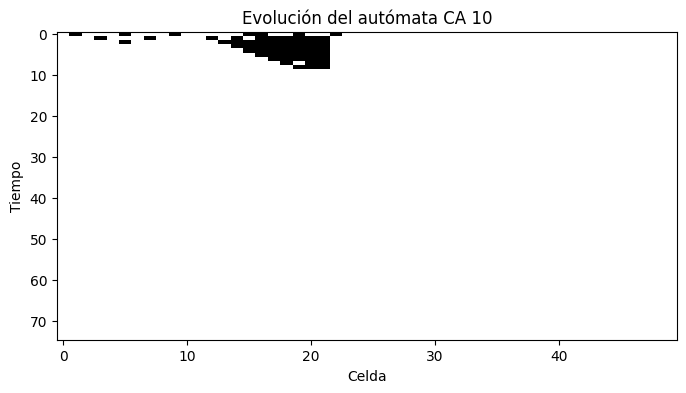

Estado uniforme final:  0


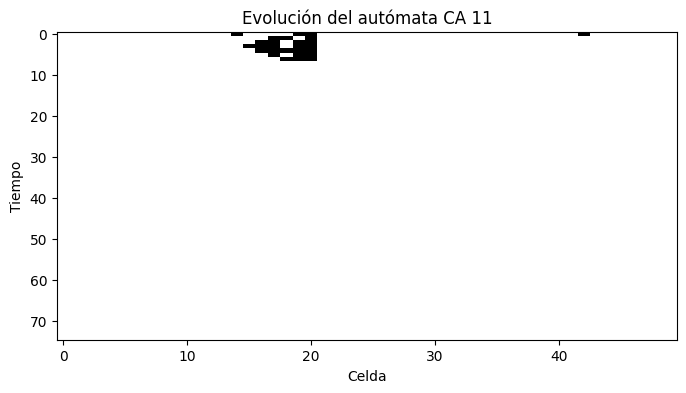

Estado uniforme final:  0


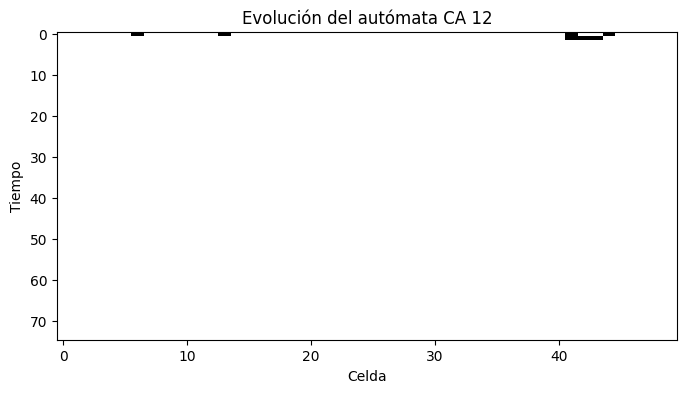

Estado uniforme final:  0


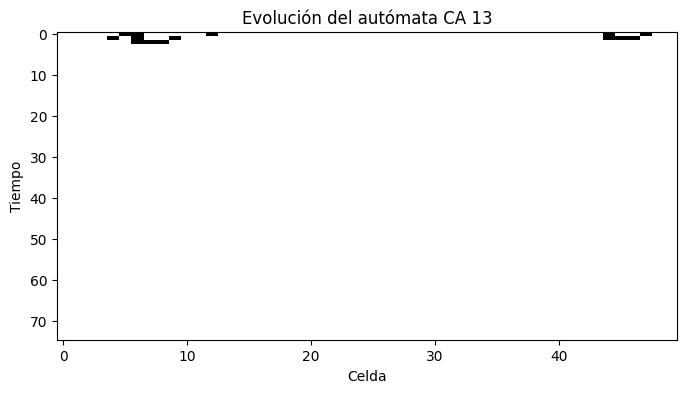

Estado uniforme final:  0


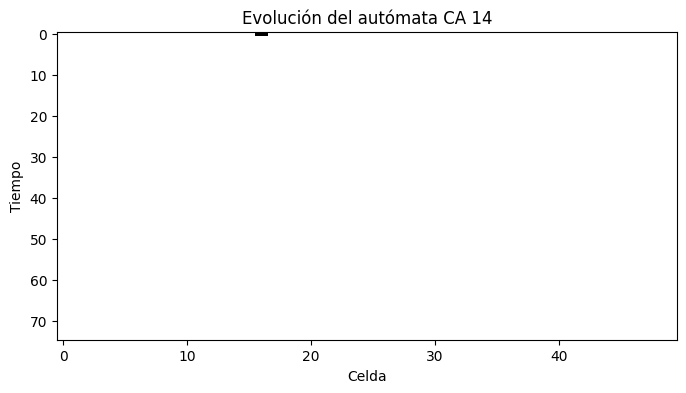

Estado uniforme final:  0


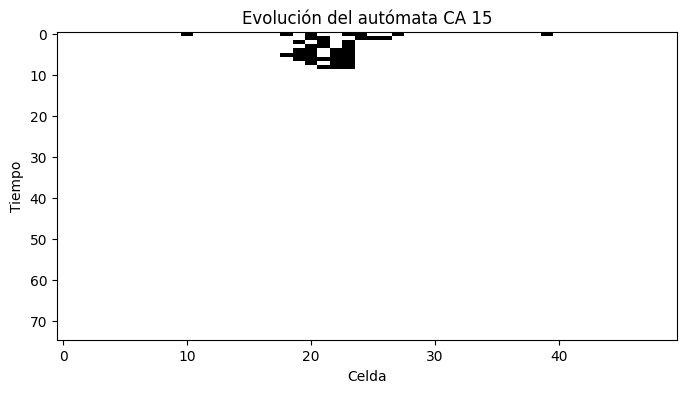

Estado uniforme final:  0


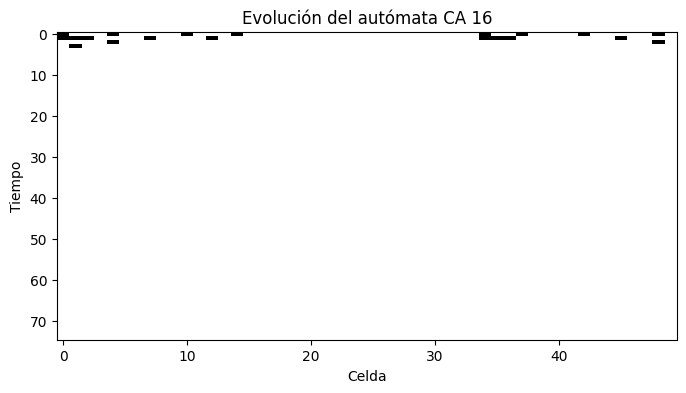

Estado uniforme final:  0


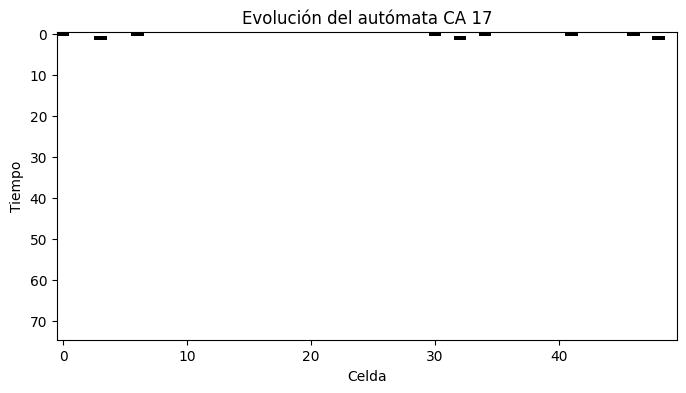

Estado uniforme final:  0


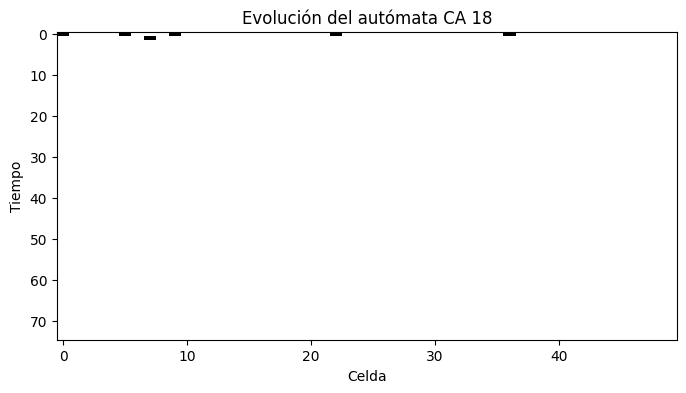

Estado uniforme final:  0


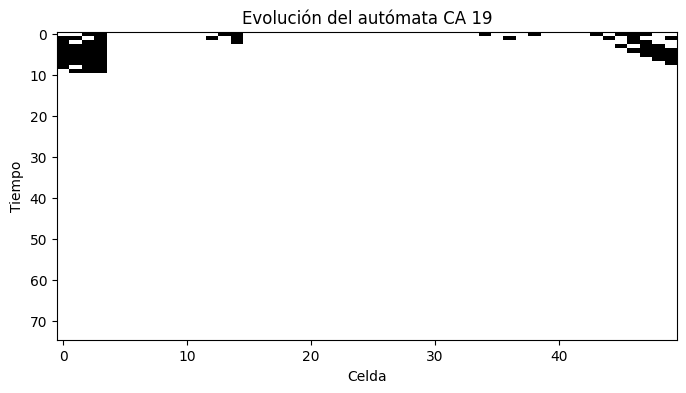

Estado uniforme final:  0


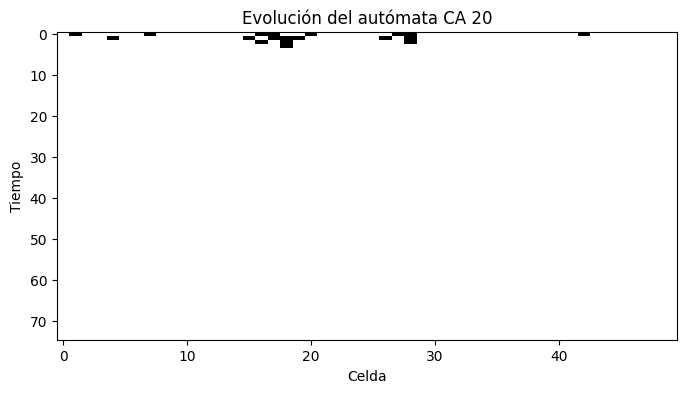

Estado uniforme final:  0


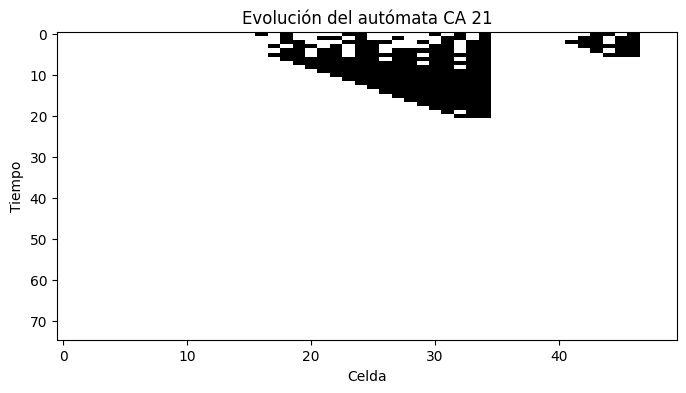

Estado uniforme final:  0


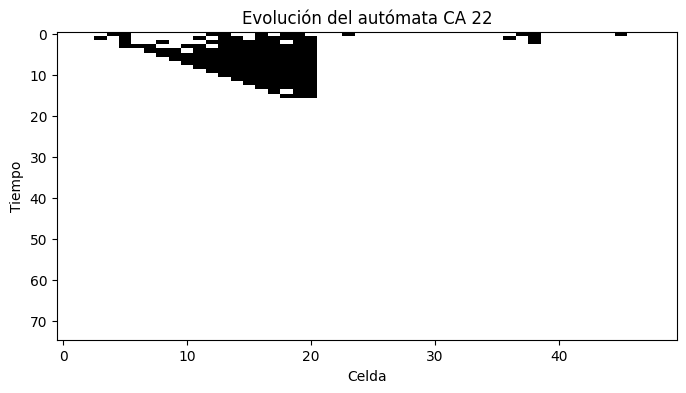

Estado uniforme final:  0


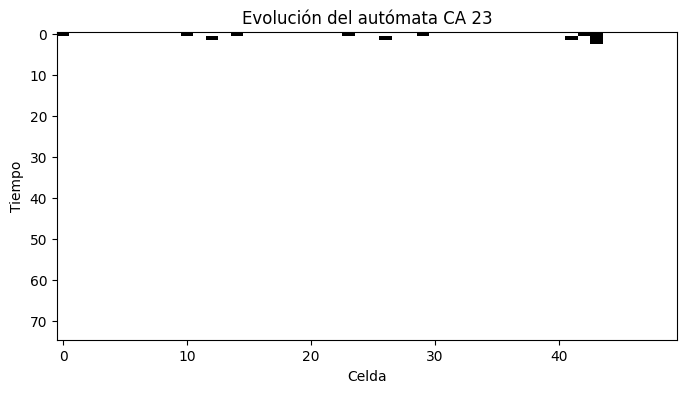

Estado uniforme final:  0


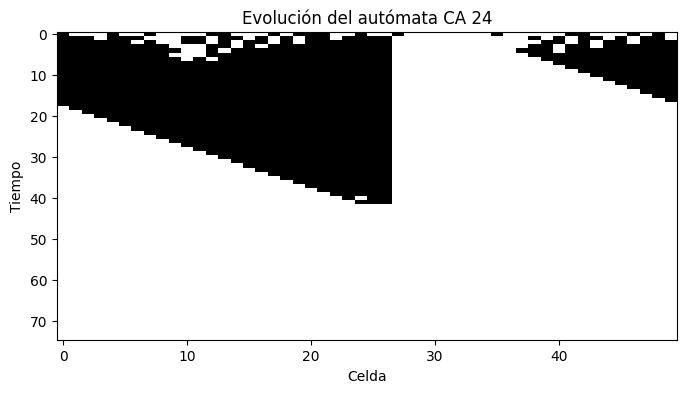

Estado uniforme final:  0


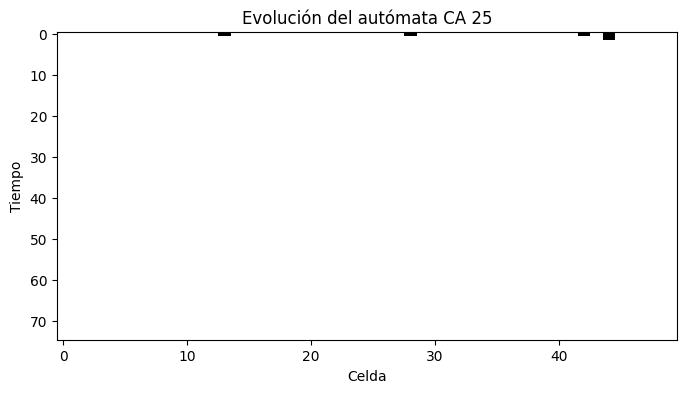

Estado uniforme final:  0


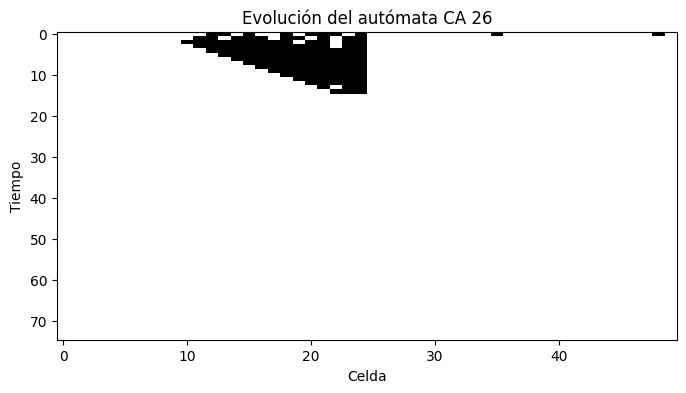

Estado uniforme final:  0


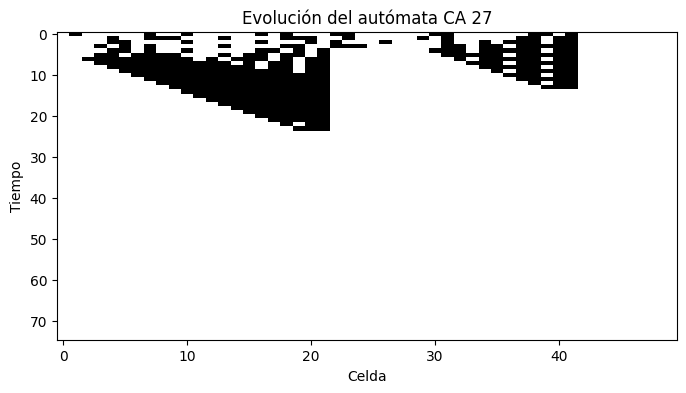

Estado uniforme final:  0


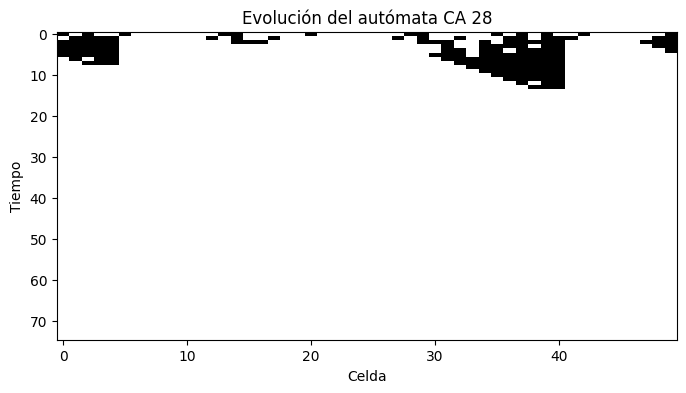

Estado uniforme final:  0


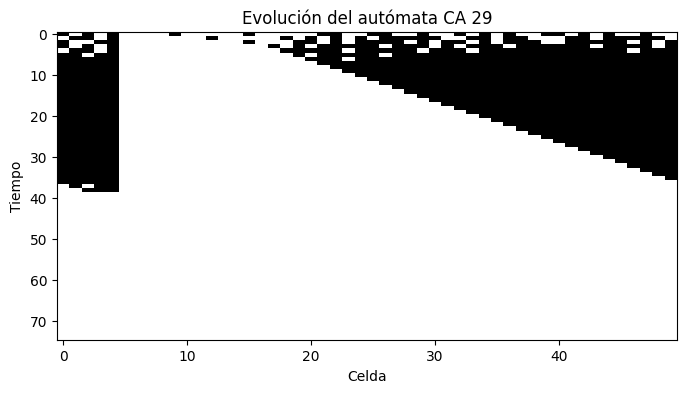

Estado uniforme final:  0


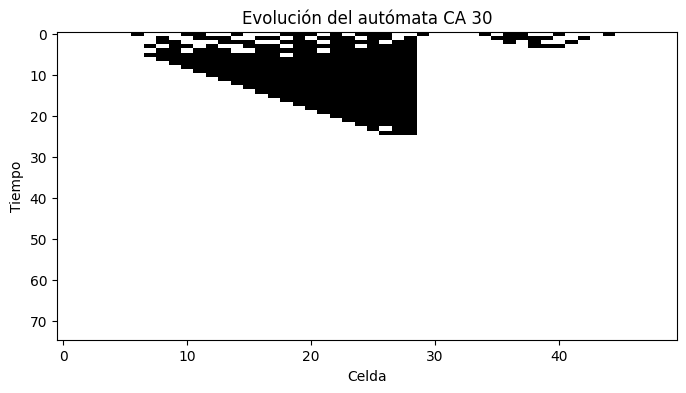

Estado uniforme final:  0


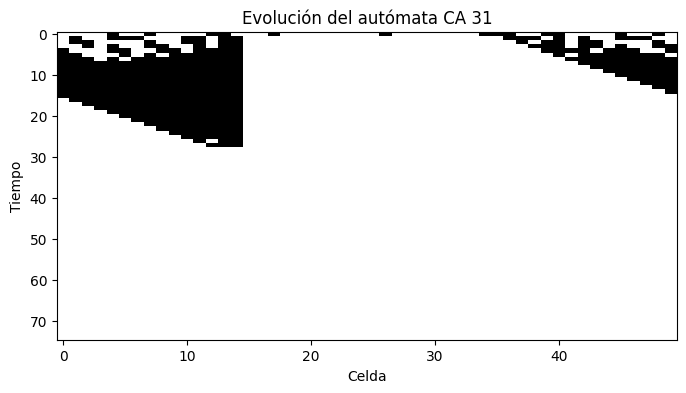

Estado uniforme final:  0


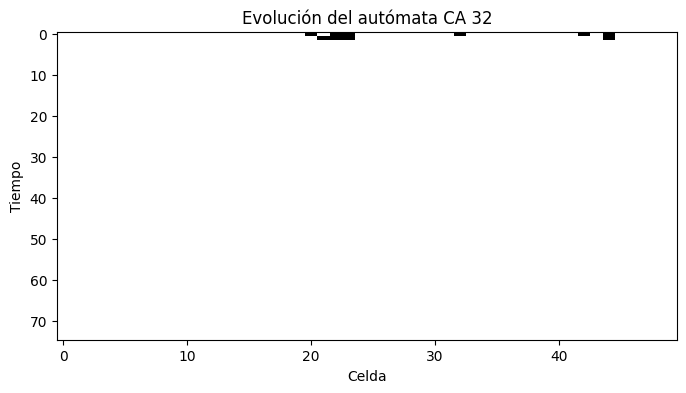

Estado uniforme final:  0


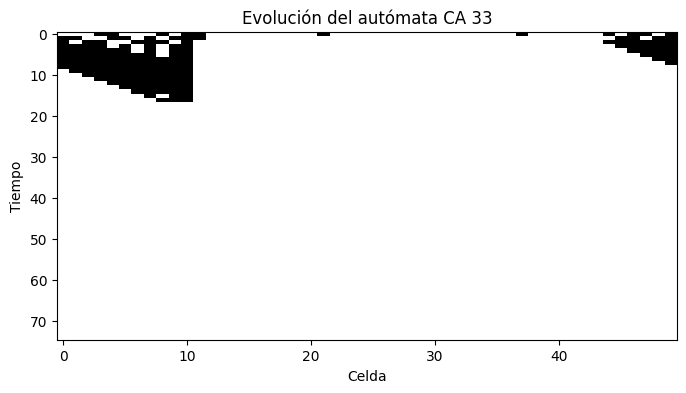

Estado uniforme final:  0


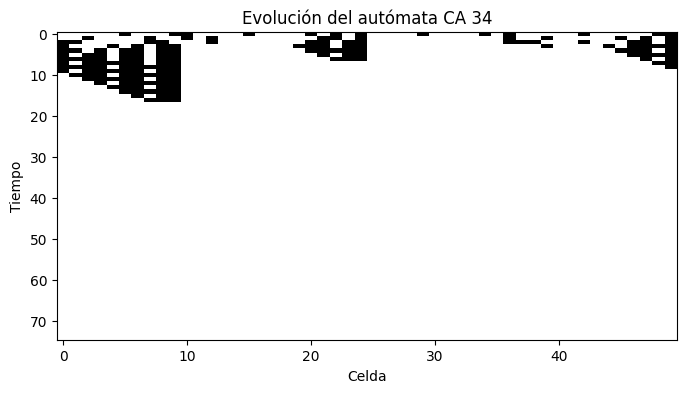

Estado uniforme final:  0


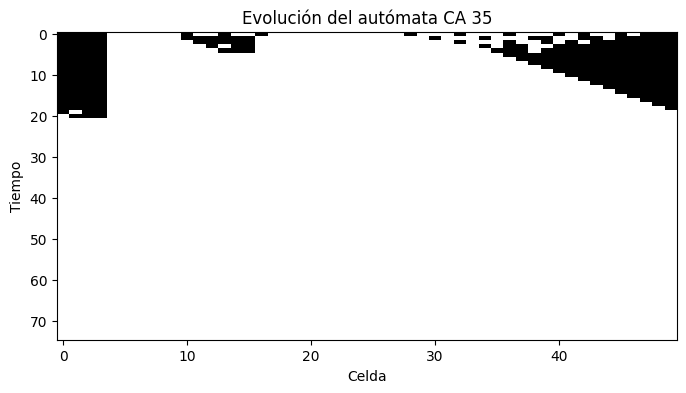

Estado uniforme final:  0


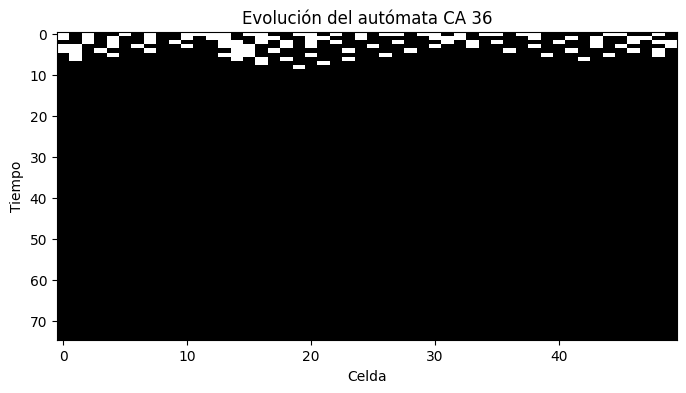

Estado uniforme final:  0


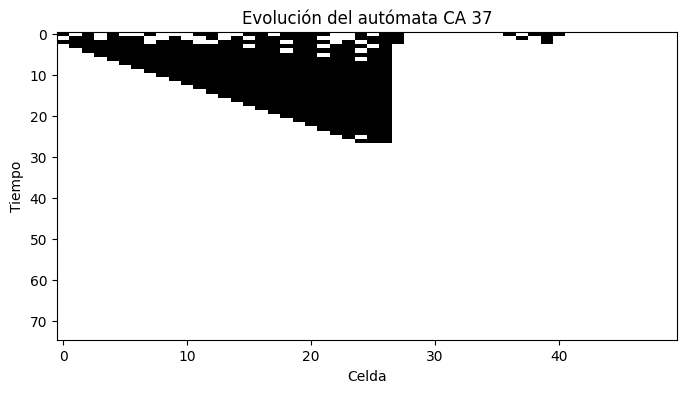

Estado uniforme final:  0


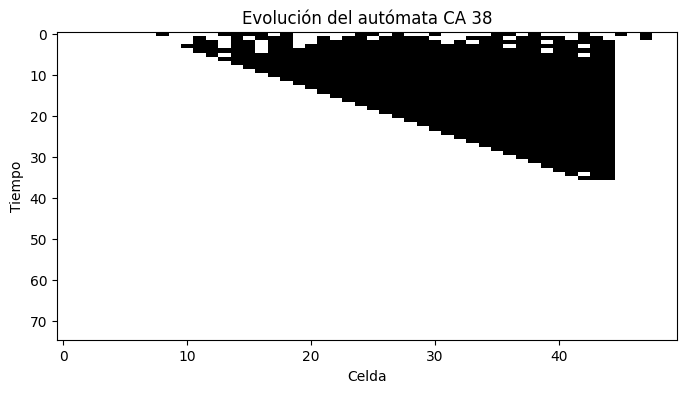

Estado uniforme final:  0


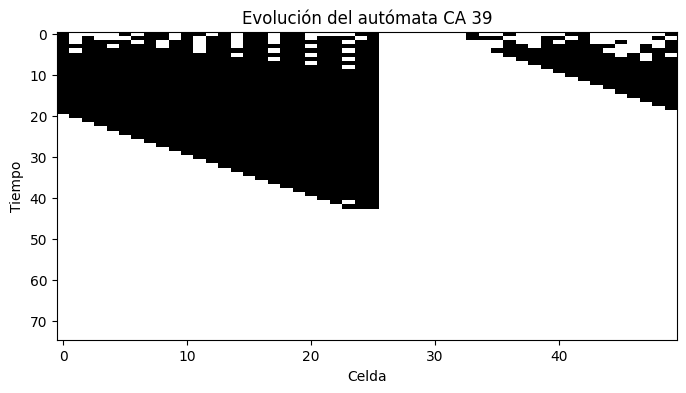

Estado uniforme final:  0


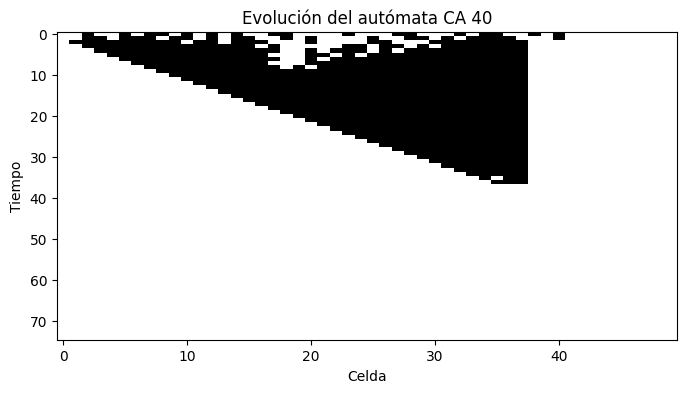

Estado uniforme final:  0


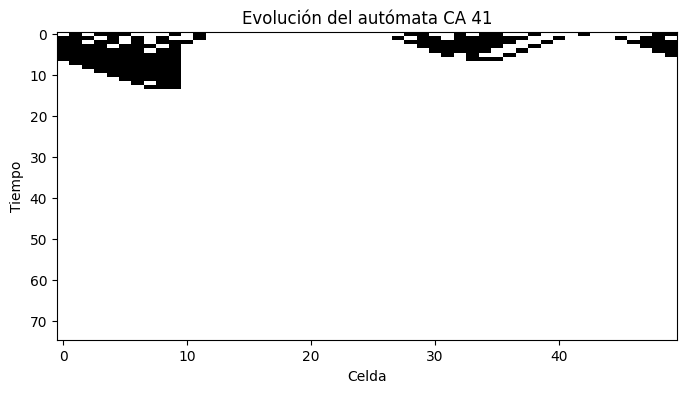

Estado uniforme final:  0


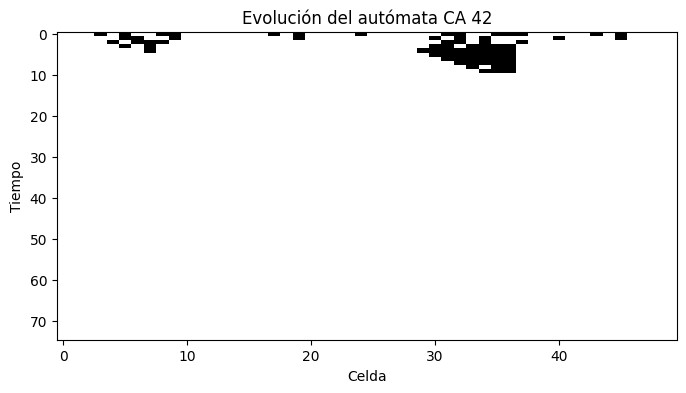

Estado uniforme final:  0


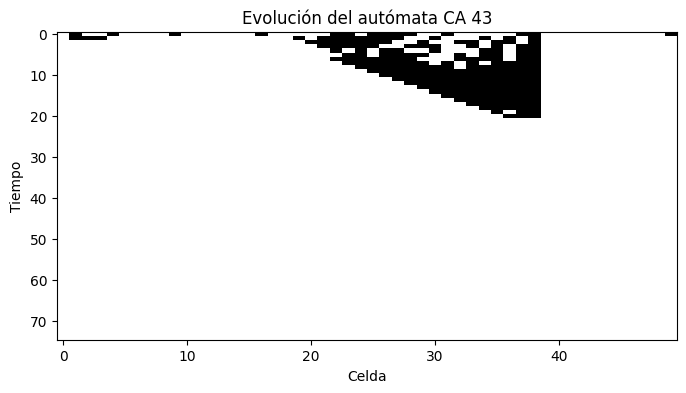

Estado uniforme final:  0


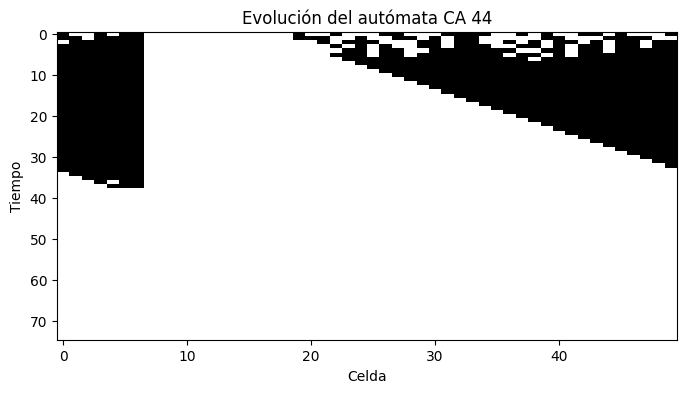

Estado uniforme final:  0


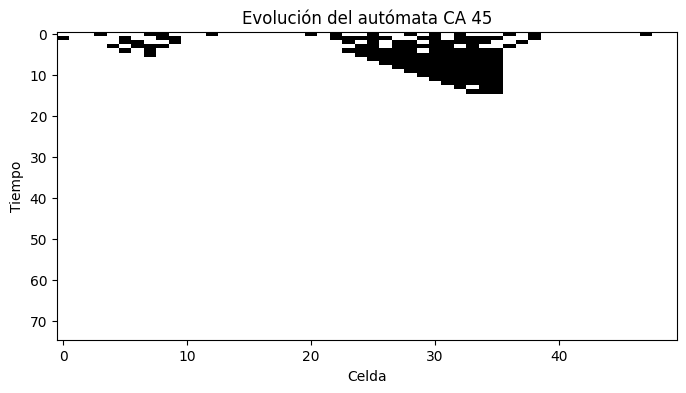

Estado uniforme final:  0


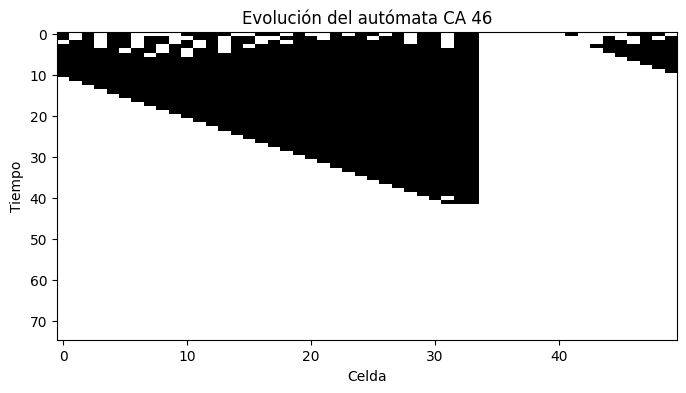

Estado uniforme final:  0


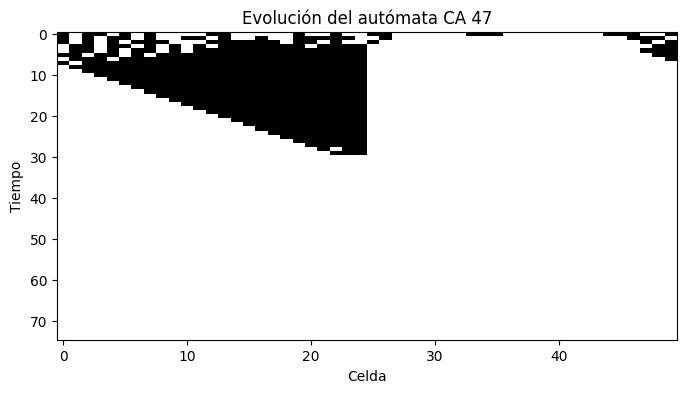

Estado uniforme final:  0


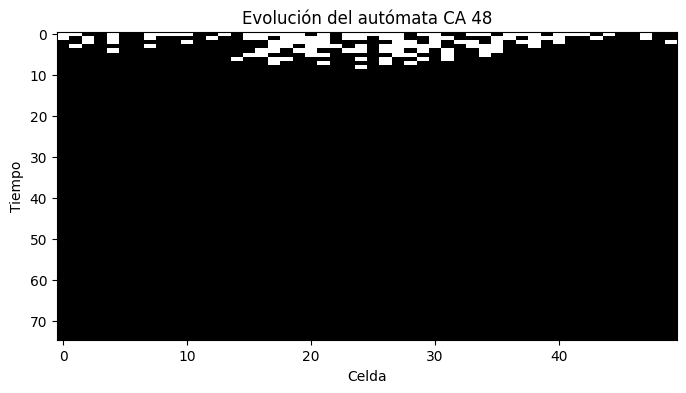

Estado uniforme final:  0


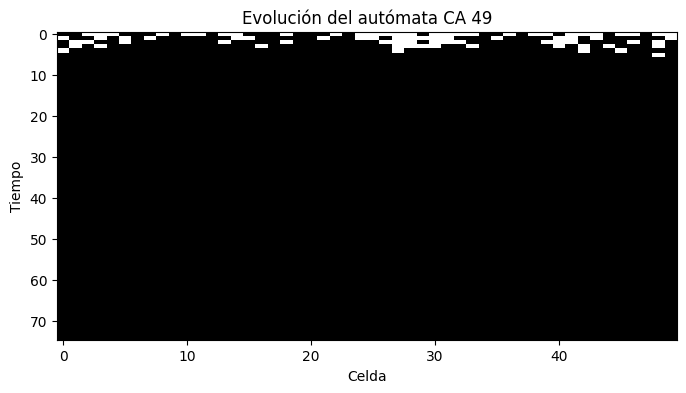

Estado uniforme final:  1


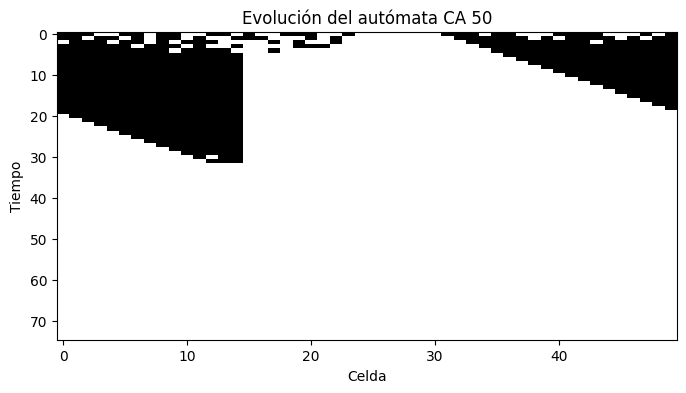

Estado uniforme final:  0


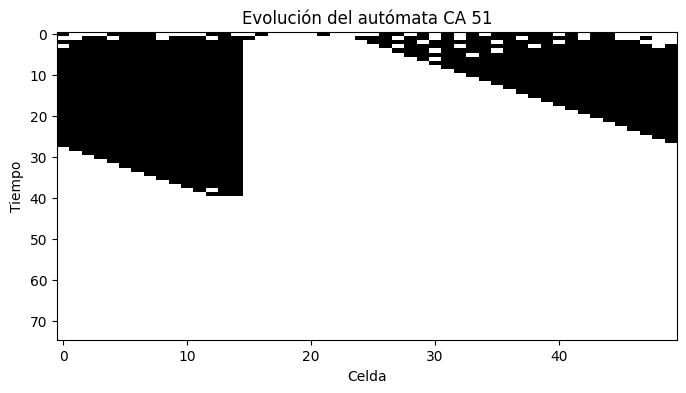

Estado uniforme final:  0


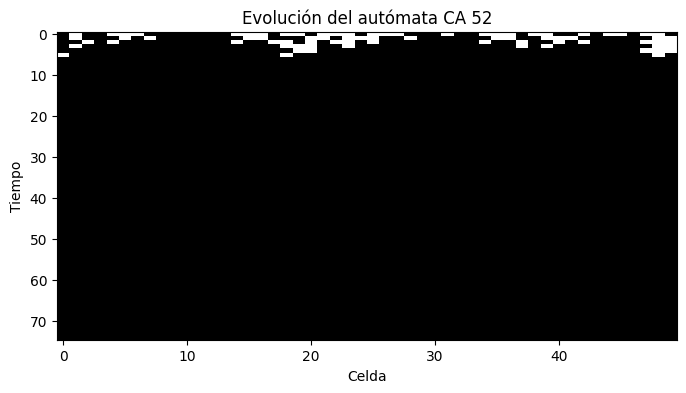

Estado uniforme final:  0


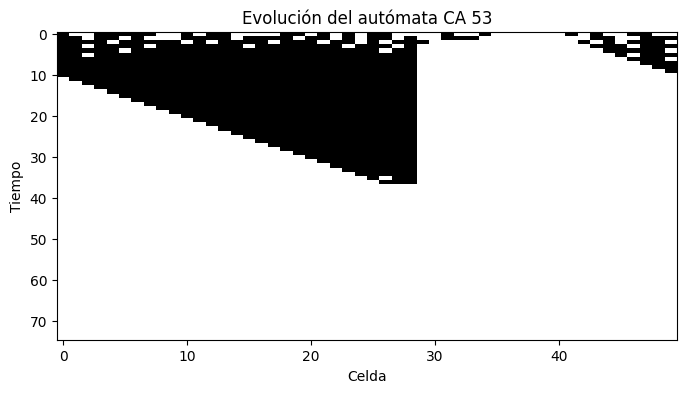

Estado uniforme final:  1


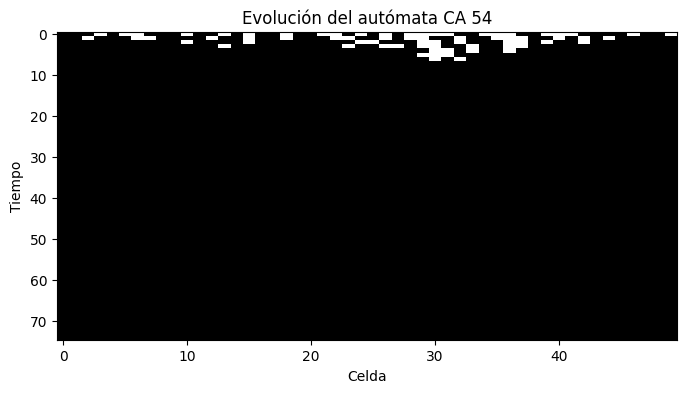

Estado uniforme final:  1


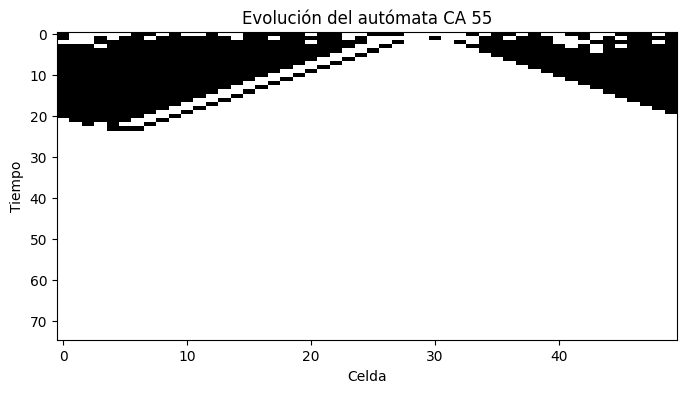

Estado uniforme final:  0


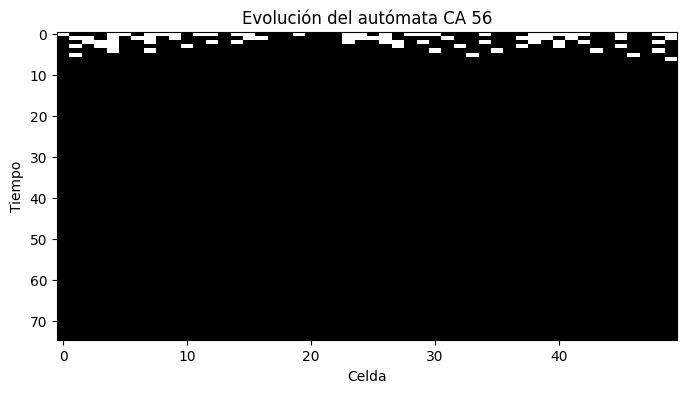

Estado uniforme final:  0


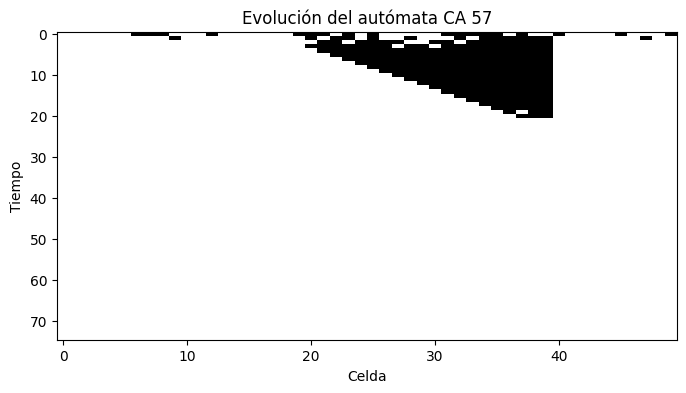

Estado uniforme final:  1


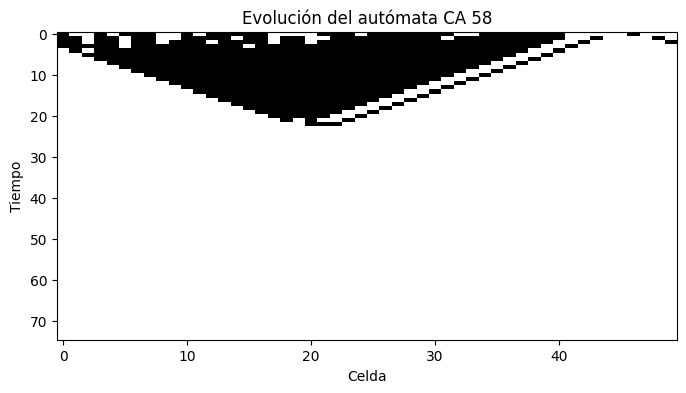

Estado uniforme final:  0


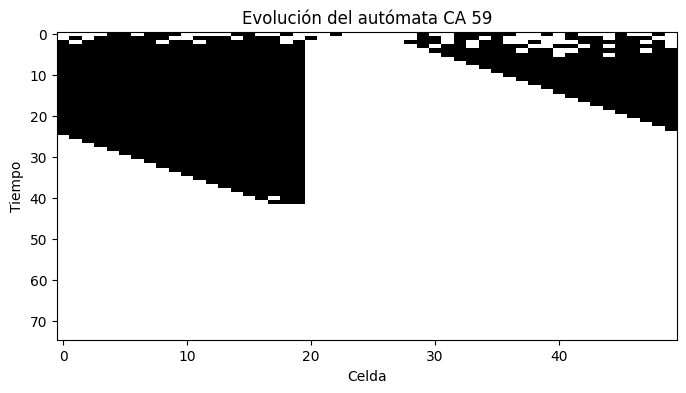

Estado uniforme final:  1


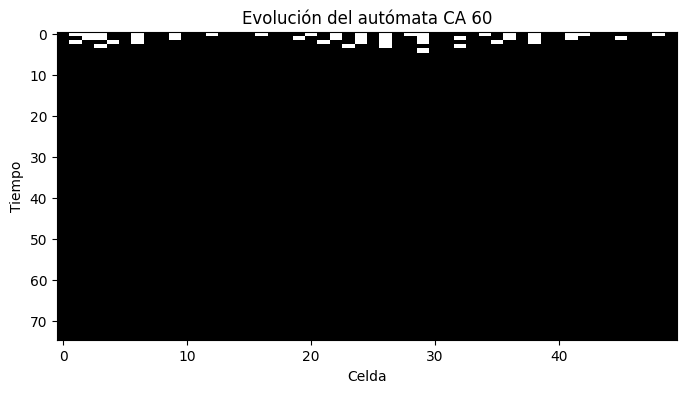

Estado uniforme final:  1


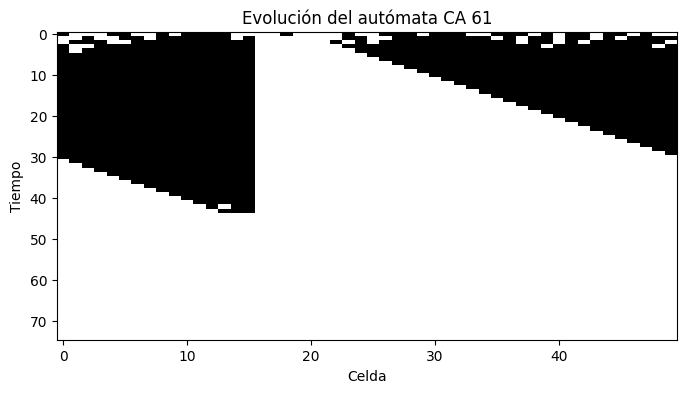

Estado uniforme final:  1


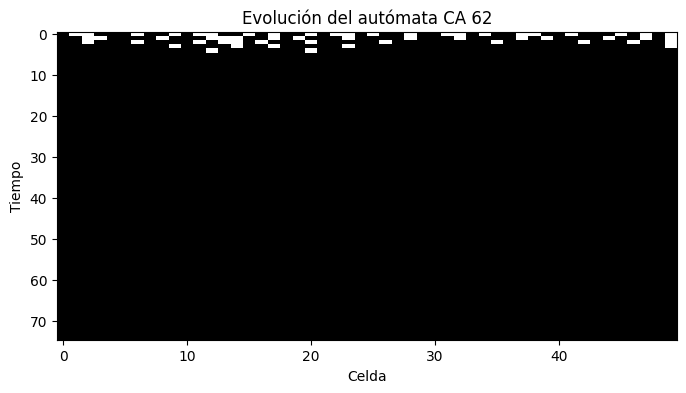

Estado uniforme final:  1


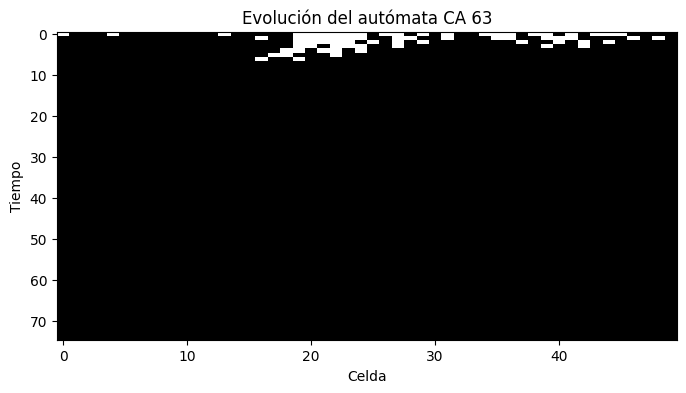

Estado uniforme final:  1


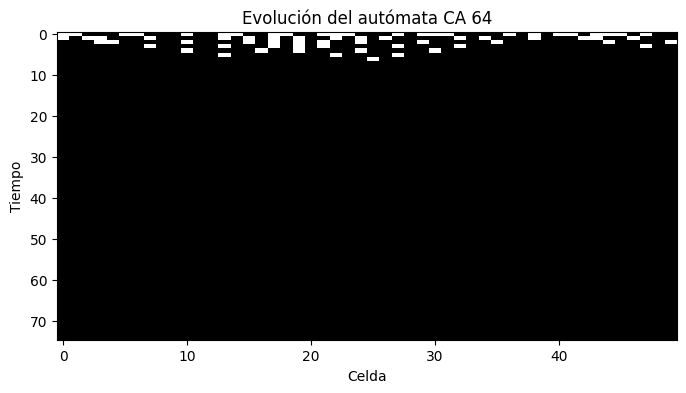

Estado uniforme final:  1


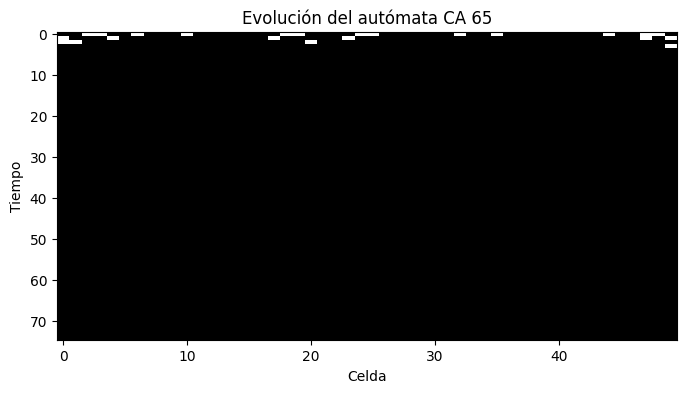

Estado uniforme final:  0


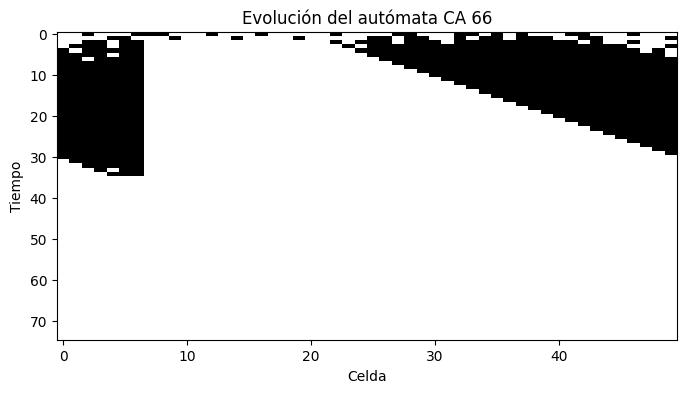

Estado uniforme final:  0


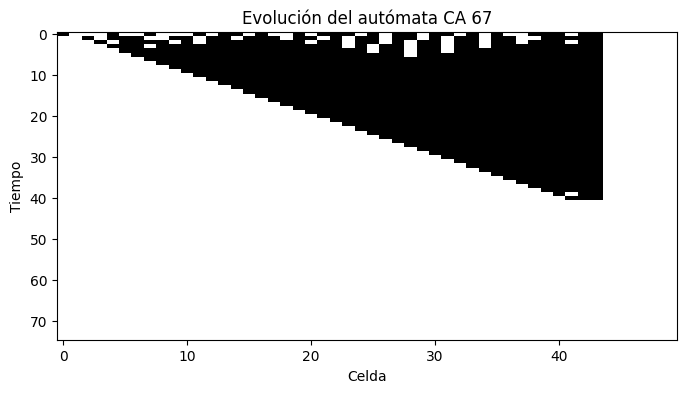

Estado uniforme final:  1


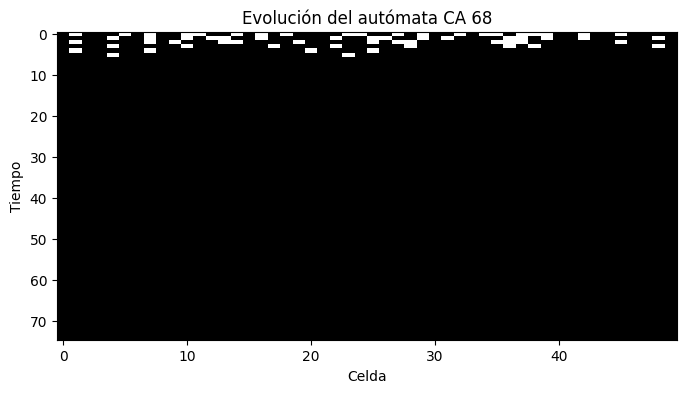

Estado uniforme final:  1


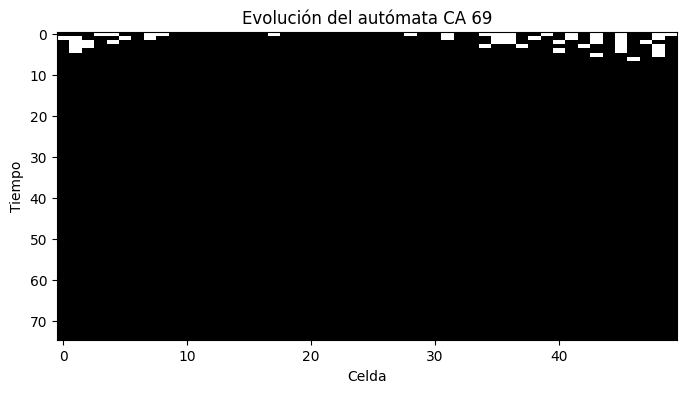

Estado uniforme final:  1


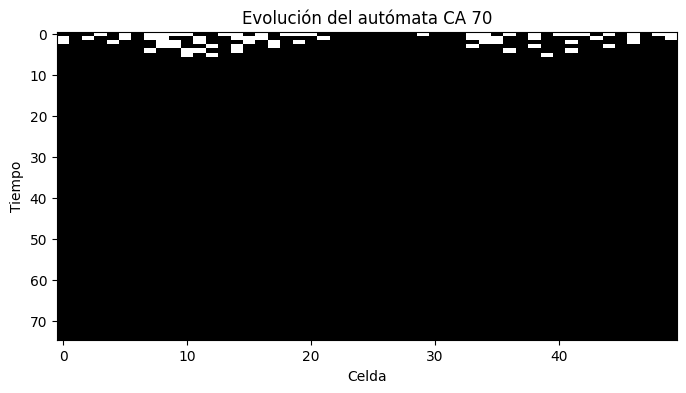

Estado uniforme final:  1


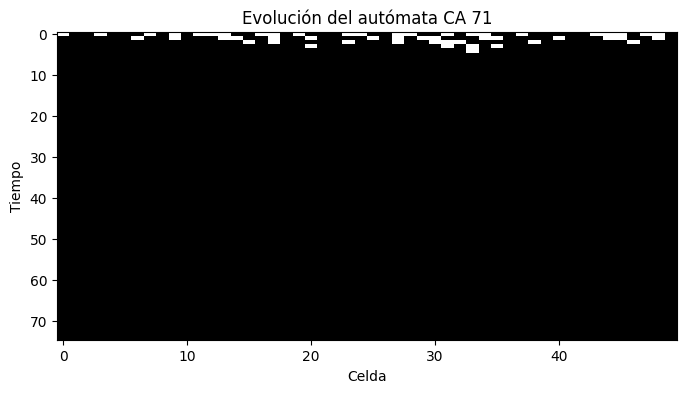

Estado uniforme final:  1


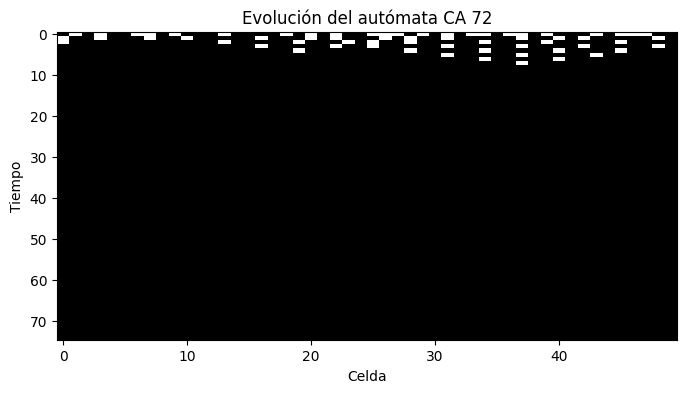

Estado uniforme final:  1


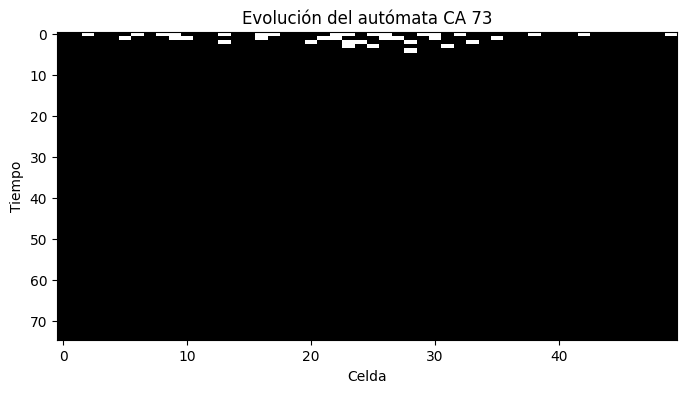

Estado uniforme final:  1


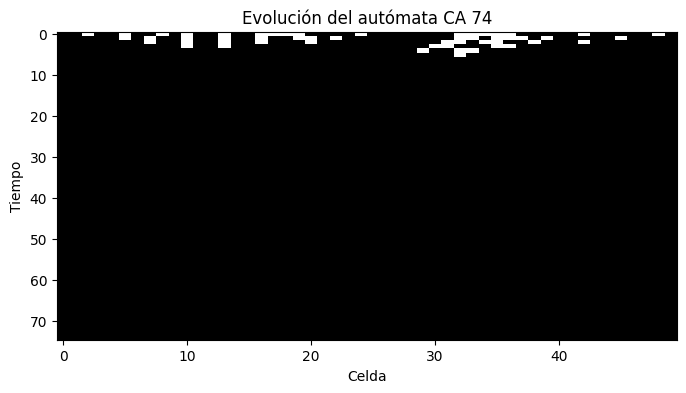

Estado uniforme final:  1


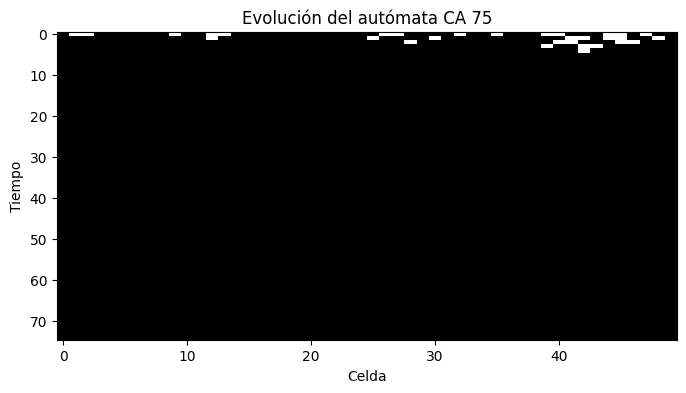

Estado uniforme final:  1


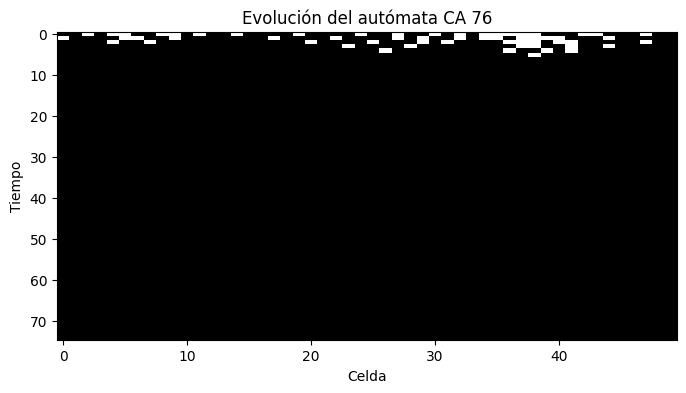

Estado uniforme final:  1


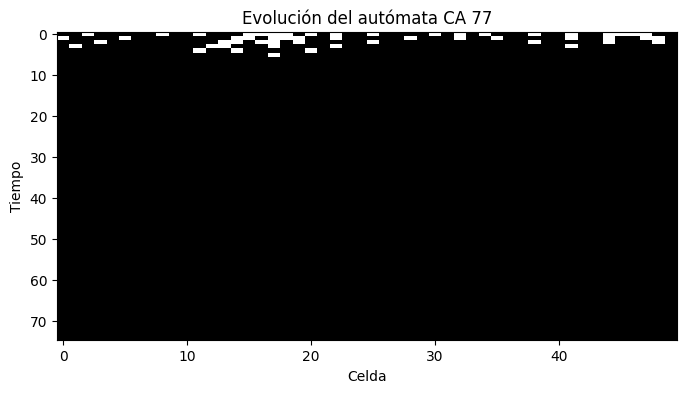

Estado uniforme final:  1


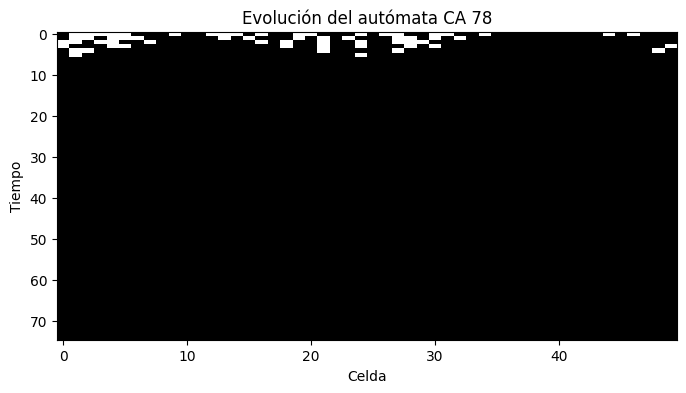

Estado uniforme final:  1


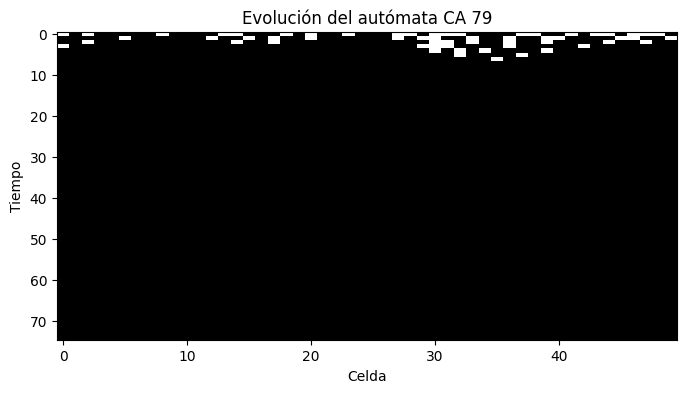

Estado uniforme final:  1


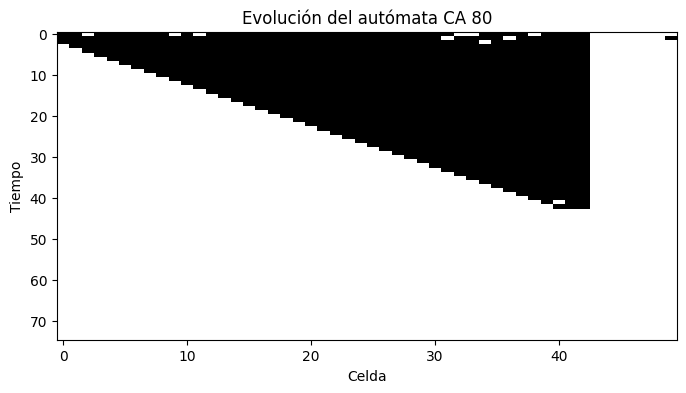

Estado uniforme final:  1


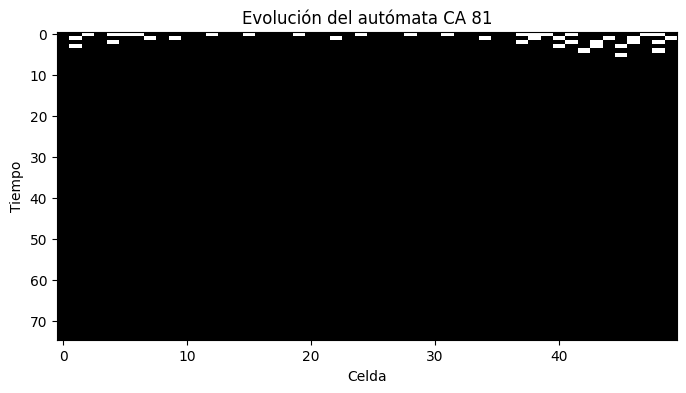

Estado uniforme final:  1


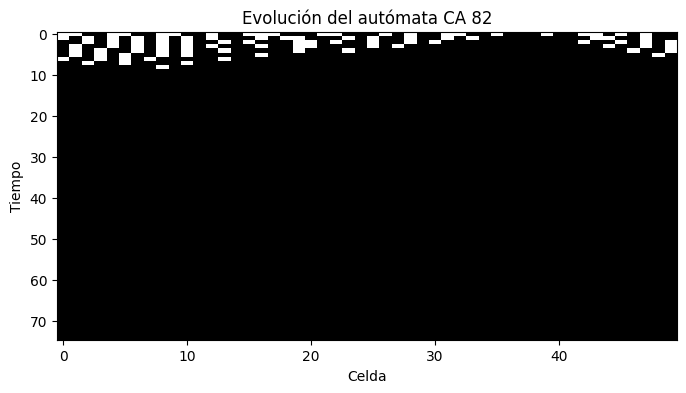

Estado uniforme final:  1


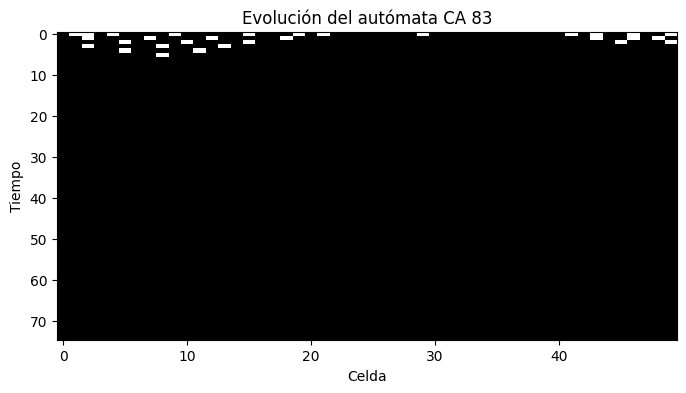

Estado uniforme final:  1


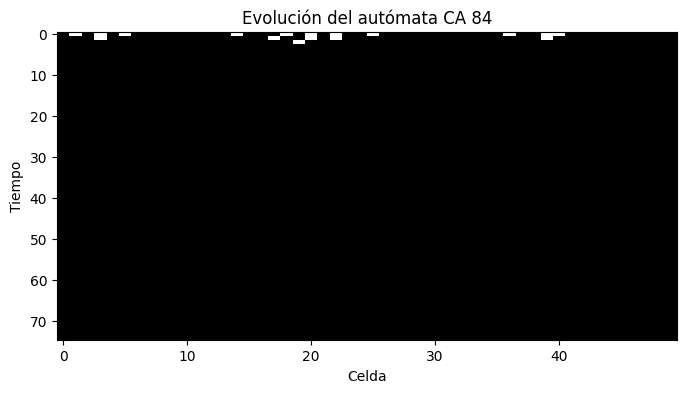

Estado uniforme final:  1


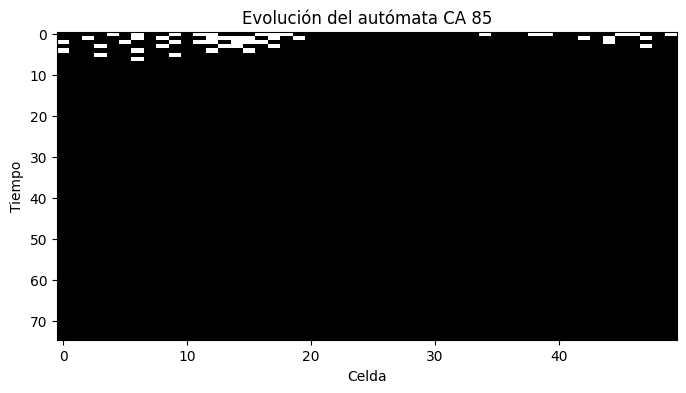

Estado uniforme final:  1


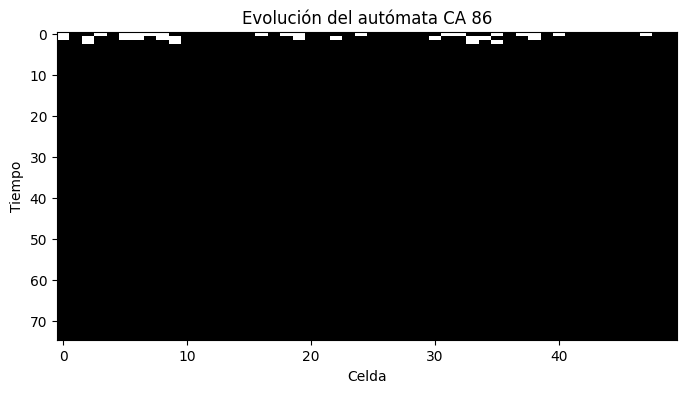

Estado uniforme final:  1


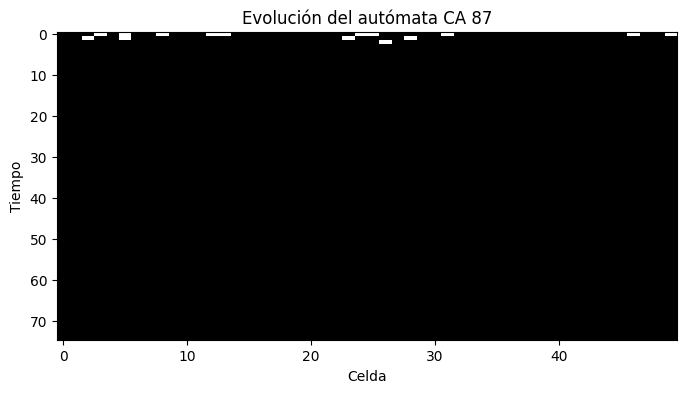

Estado uniforme final:  1


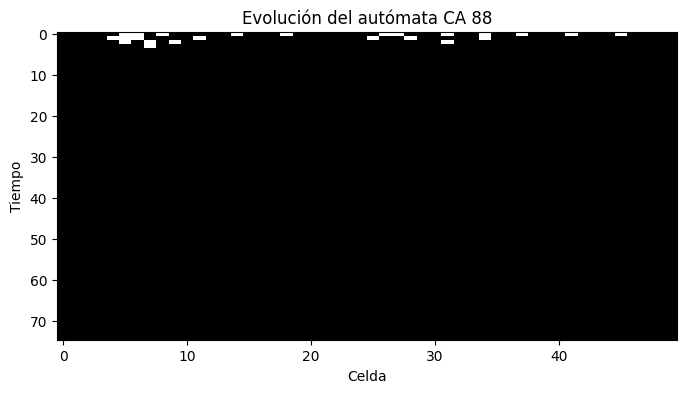

Estado uniforme final:  1


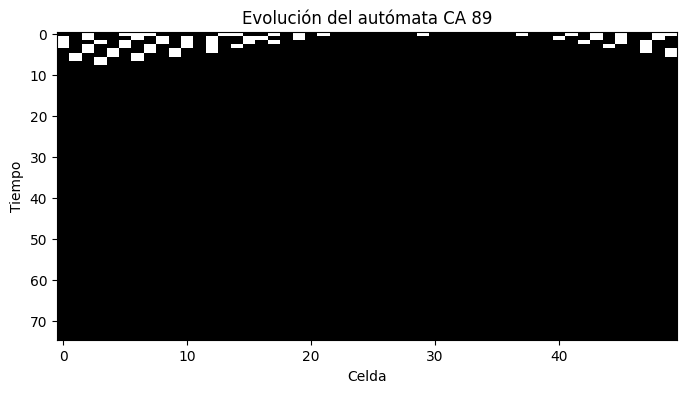

Estado uniforme final:  1


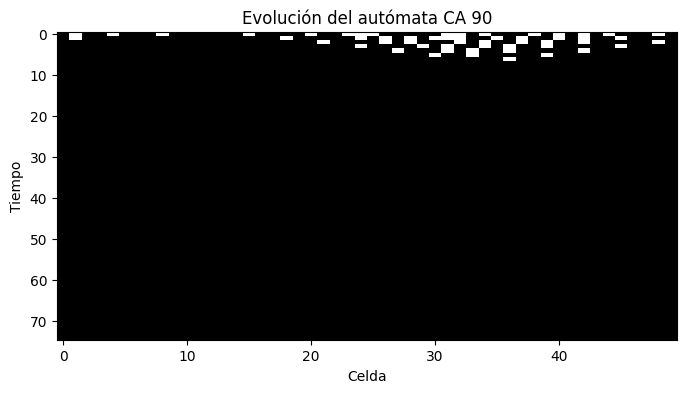

Estado uniforme final:  1


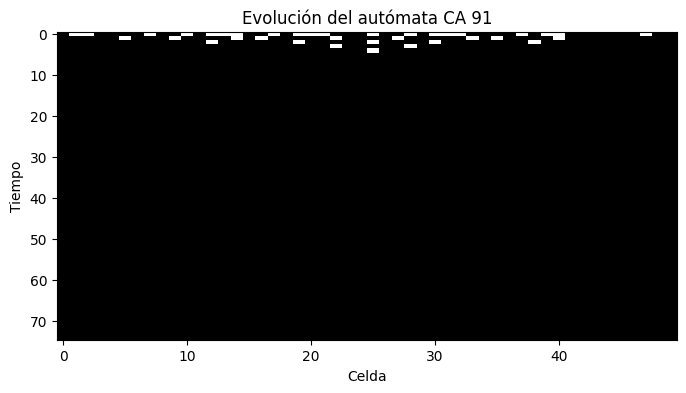

Estado uniforme final:  1


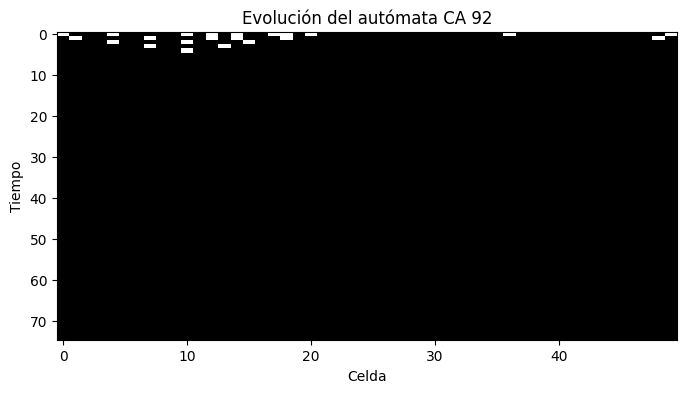

Estado uniforme final:  1


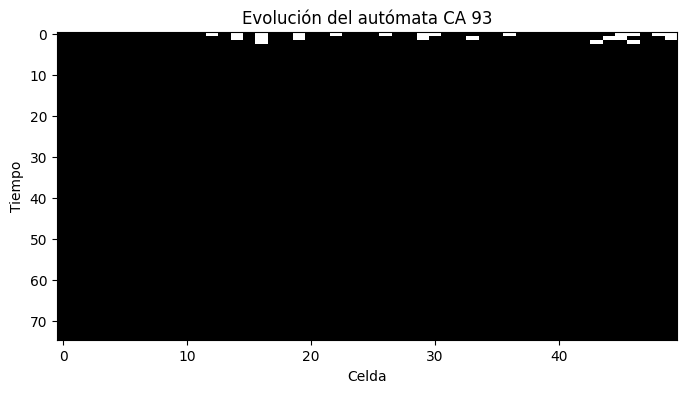

Estado uniforme final:  1


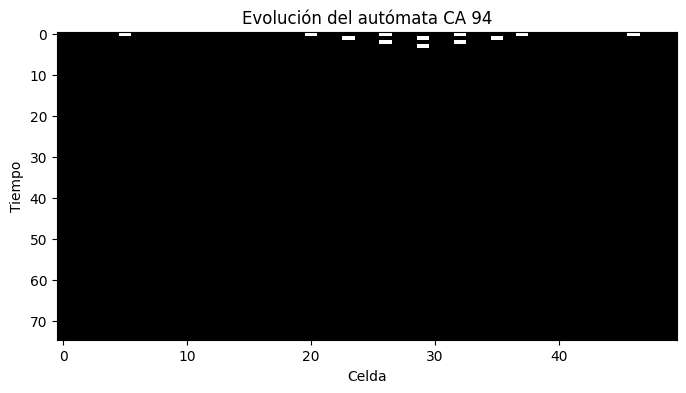

Estado uniforme final:  1


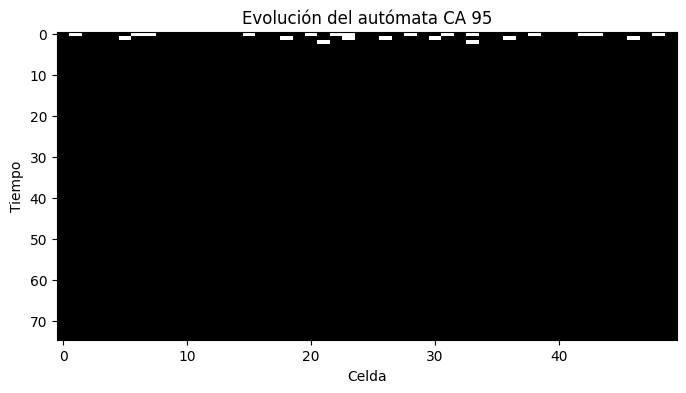

Estado uniforme final:  1


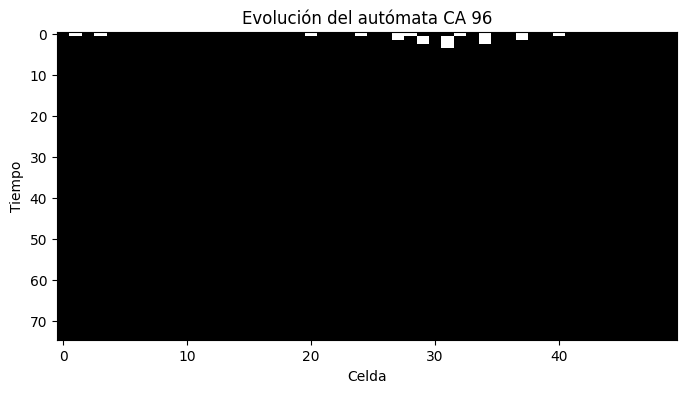

Estado uniforme final:  1


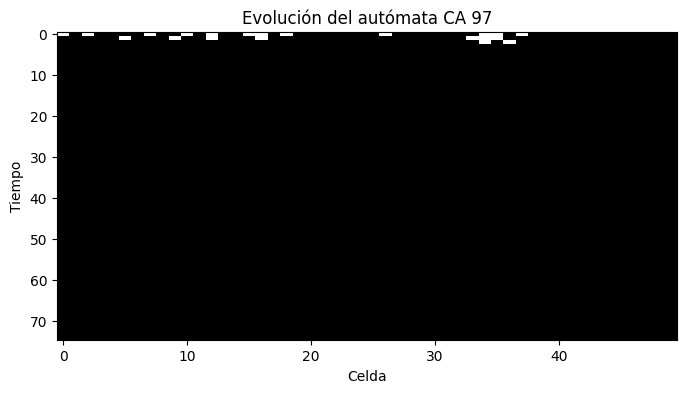

Estado uniforme final:  1


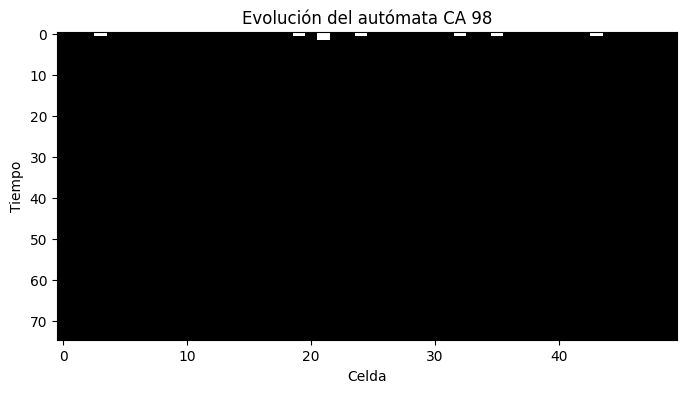

Estado uniforme final:  1


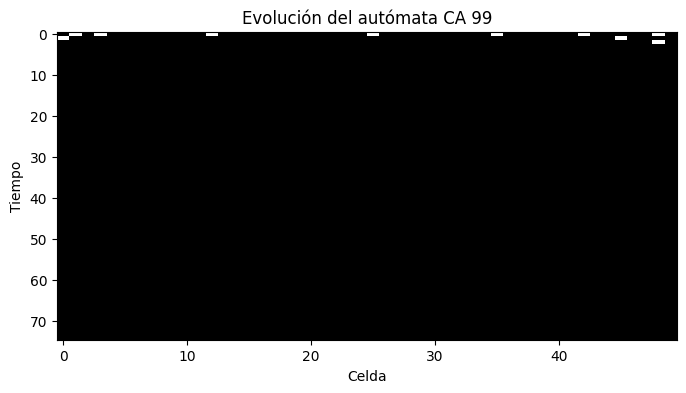

Estado uniforme final:  1


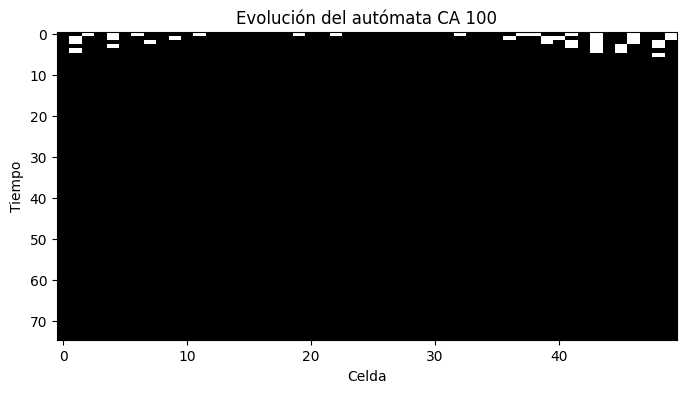

Estado uniforme final:  1


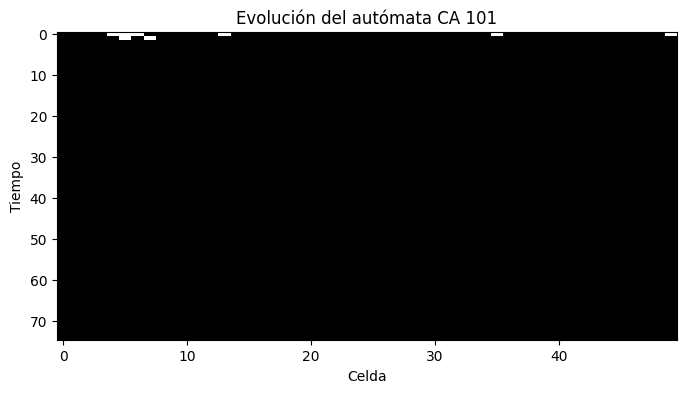

Estado uniforme final:  1


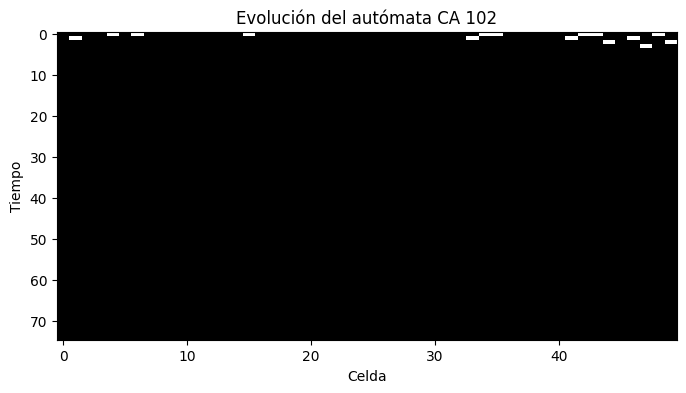

Estado uniforme final:  1


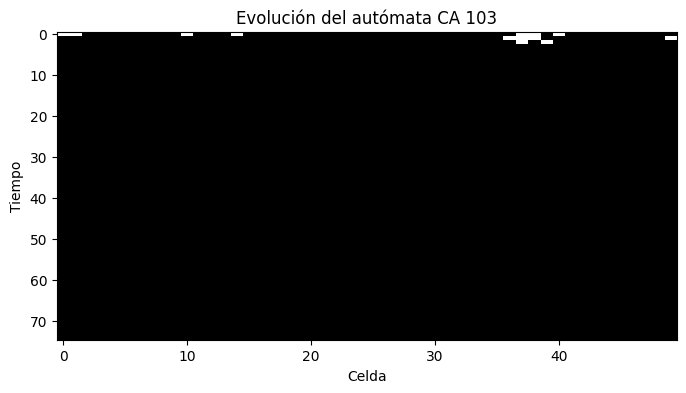

Estado uniforme final:  1


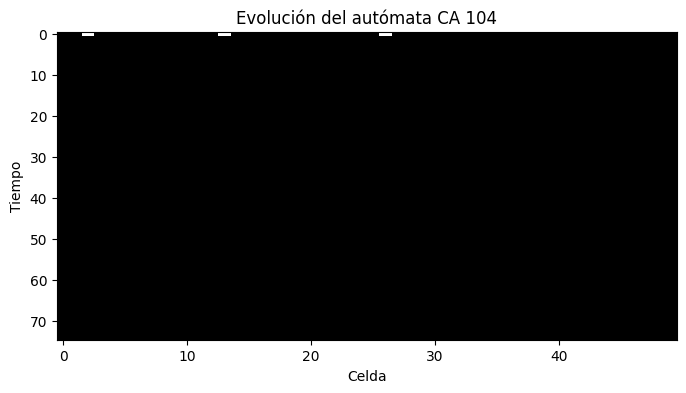

Estado uniforme final:  1


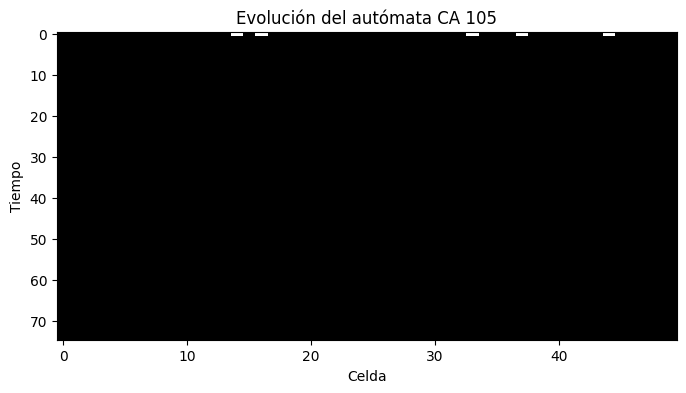

Estado uniforme final:  1


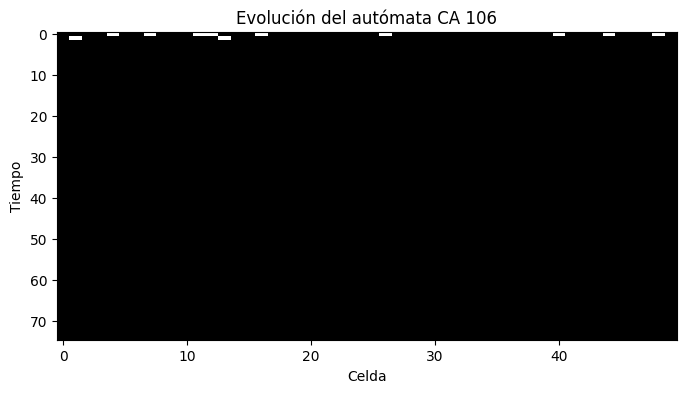

Estado uniforme final:  1


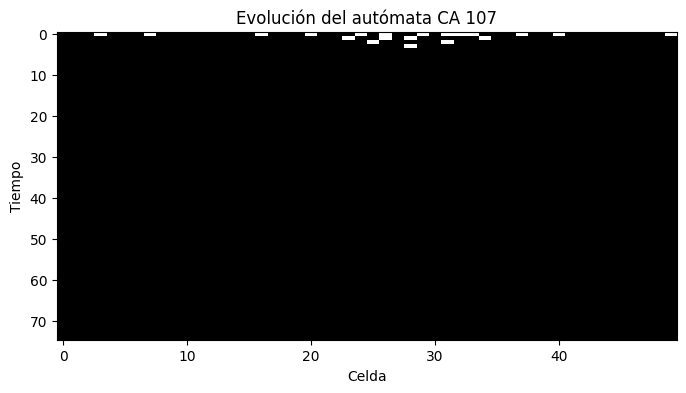

Estado uniforme final:  1


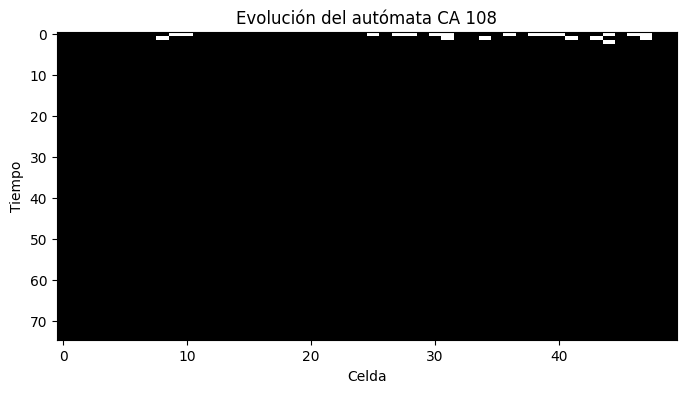

Estado uniforme final:  1


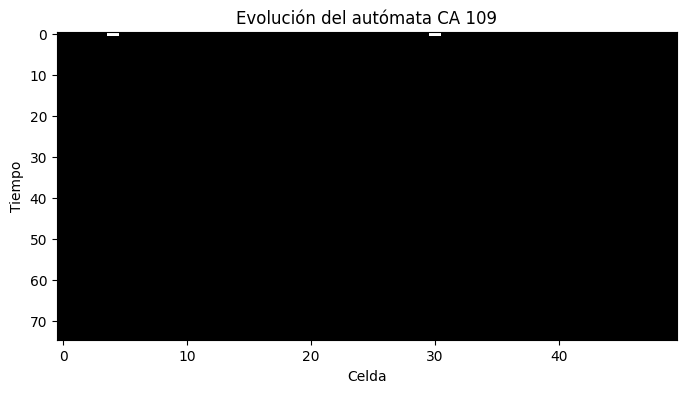

Estado uniforme final:  1


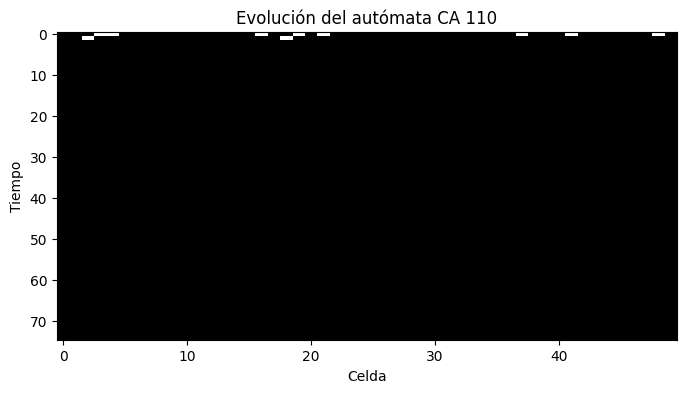

Estado uniforme final:  1


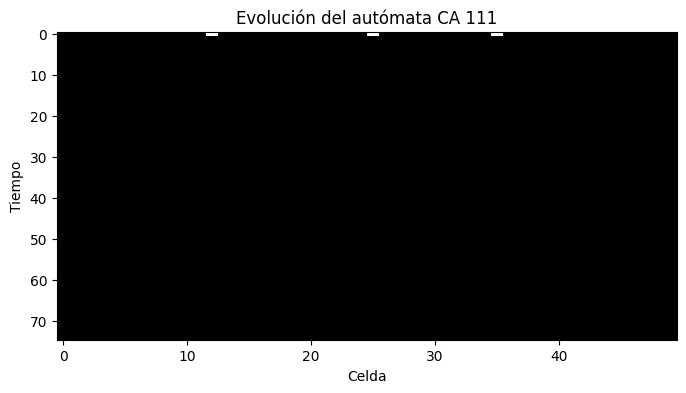

Estado uniforme final:  1


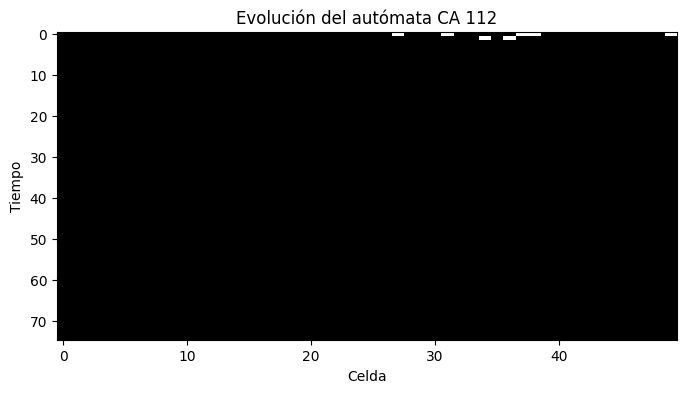

Estado uniforme final:  1


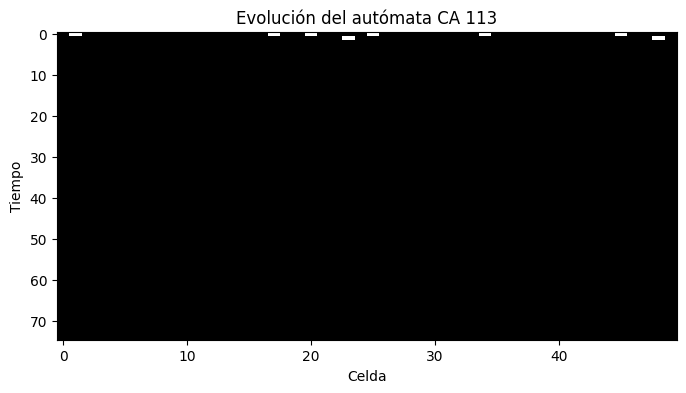

Estado uniforme final:  1


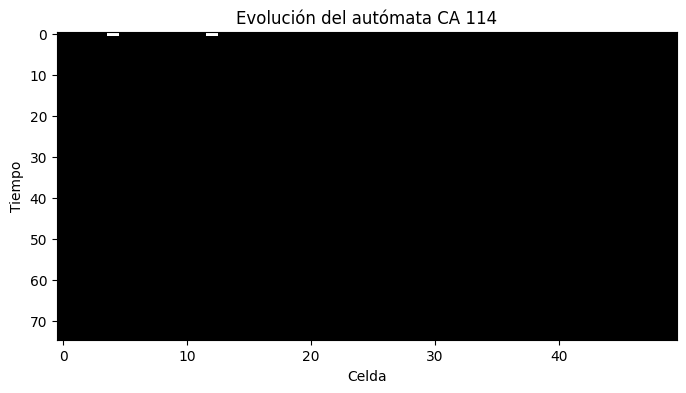

Estado uniforme final:  1


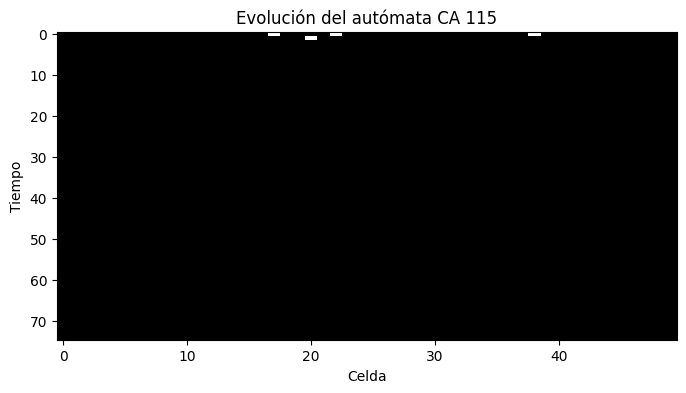

Estado uniforme final:  1


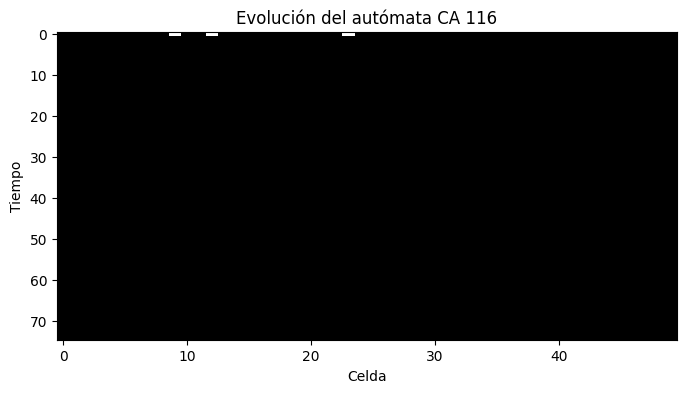

Estado uniforme final:  1


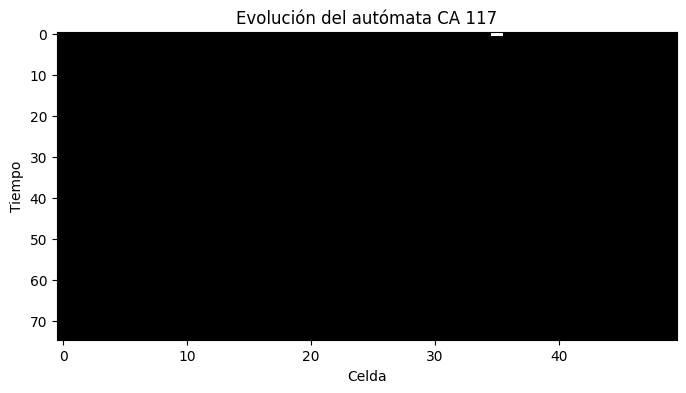

Estado uniforme final:  1


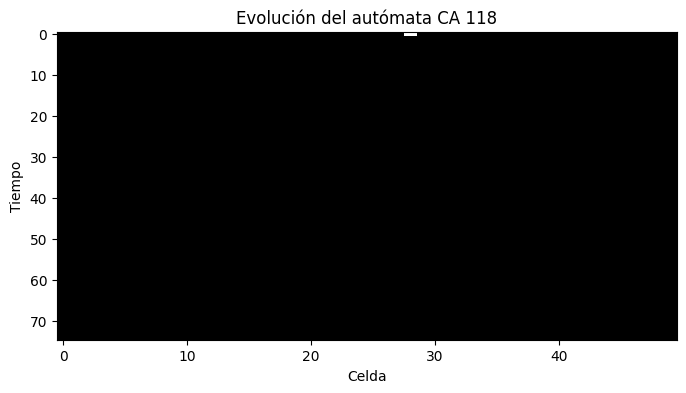

Estado uniforme final:  1


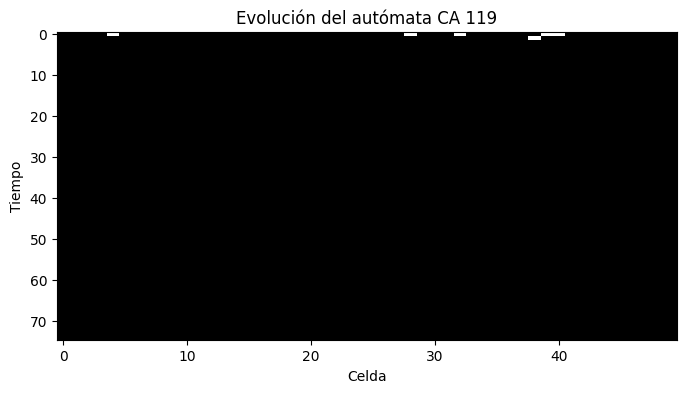

Estado uniforme final:  1


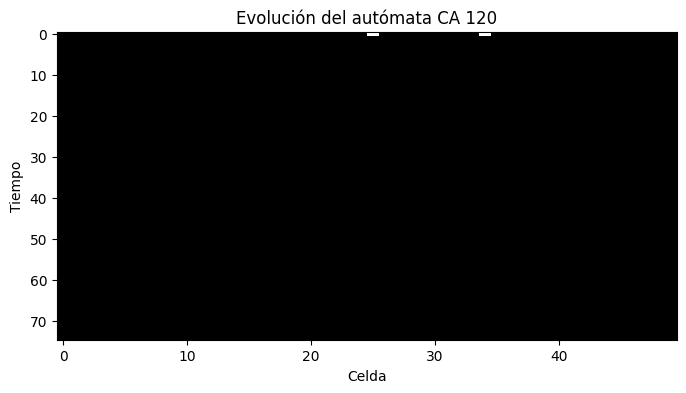

Estado uniforme final:  1


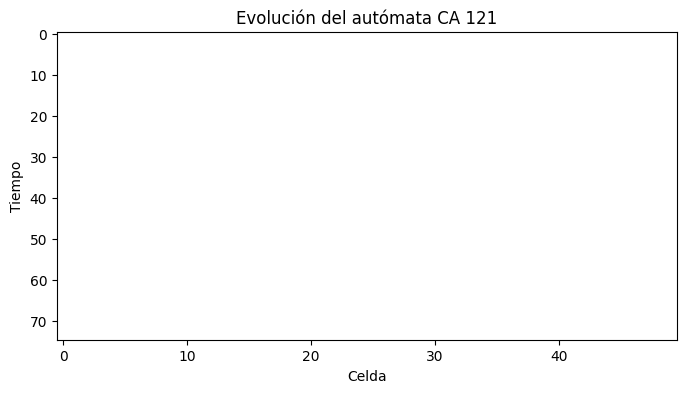

Estado uniforme final:  1


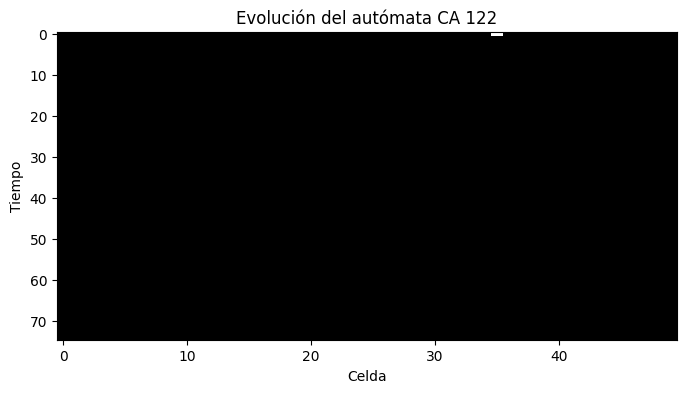

Estado uniforme final:  1


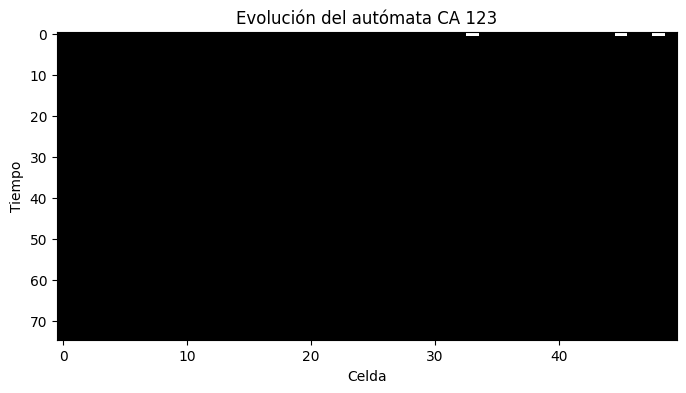

Estado uniforme final:  1


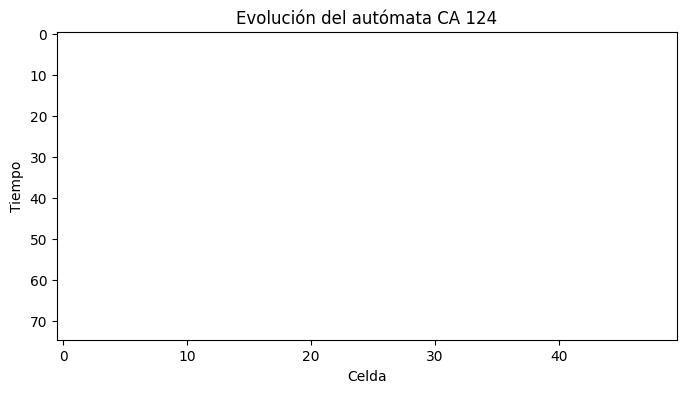

--- Catálogo de Reglas del AC (Índice -> Configuración -> Resultado) ---
Índice 000:   □□□□□□□   ->   □
Índice 001:   □□□□□□■   ->   □
Índice 002:   □□□□□■□   ->   □
Índice 003:   □□□□□■■   ->   □
Índice 004:   □□□□■□□   ->   □
Índice 005:   □□□□■□■   ->   □
Índice 006:   □□□□■■□   ->   ■
Índice 007:   □□□□■■■   ->   □
Índice 008:   □□□■□□□   ->   □
Índice 009:   □□□■□□■   ->   ■
Índice 010:   □□□■□■□   ->   □
Índice 011:   □□□■□■■   ->   □
Índice 012:   □□□■■□□   ->   □
Índice 013:   □□□■■□■   ->   ■
Índice 014:   □□□■■■□   ->   □
Índice 015:   □□□■■■■   ->   □
Índice 016:   □□■□□□□   ->   □
Índice 017:   □□■□□□■   ->   □
Índice 018:   □□■□□■□   ->   ■
Índice 019:   □□■□□■■   ->   ■
Índice 020:   □□■□■□□   ->   □
Índice 021:   □□■□■□■   ->   ■
Índice 022:   □□■□■■□   ->   ■
Índice 023:   □□■□■■■   ->   ■
Índice 024:   □□■■□□□   ->   ■
Índice 025:   □□■■□□■   ->   ■
Índice 026:   □□■■□■□   ->   □
Índice 027:   □□■■□■■   ->   ■
Índice 028:   □□■■■□□   ->   □
Índice 029:   □□■■■□■   ->  

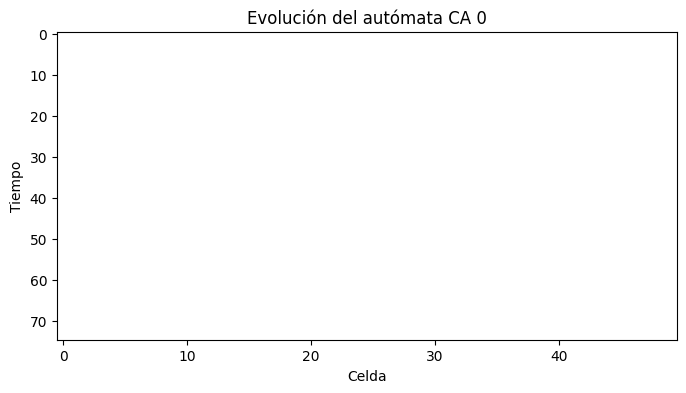

Estado uniforme final:  0


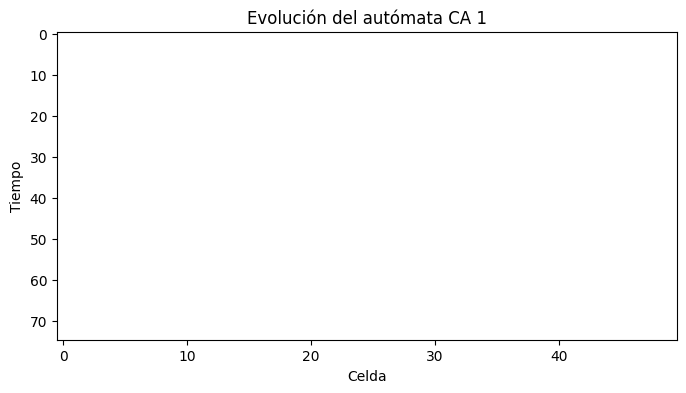

Estado uniforme final:  0


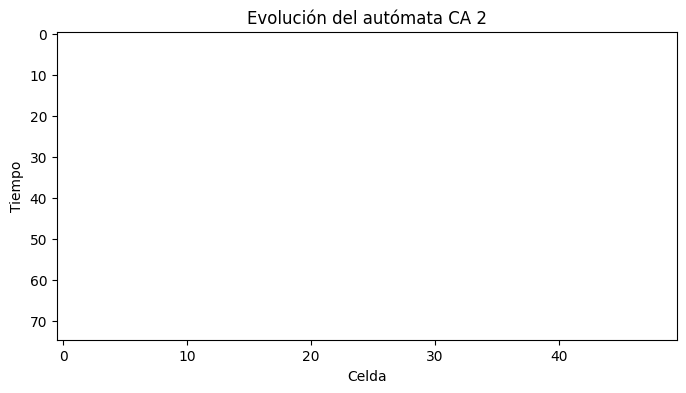

Estado uniforme final:  0


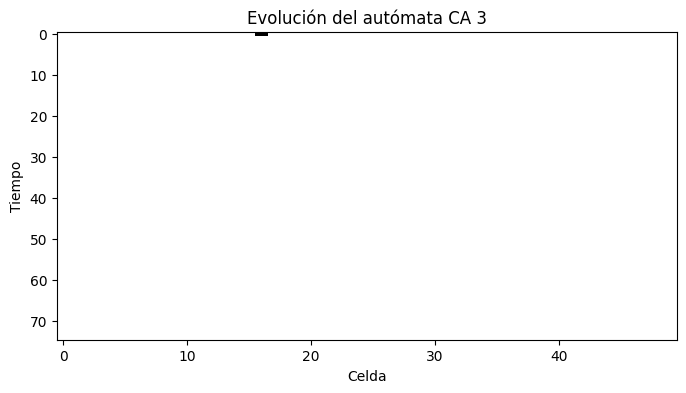

Estado uniforme final:  0


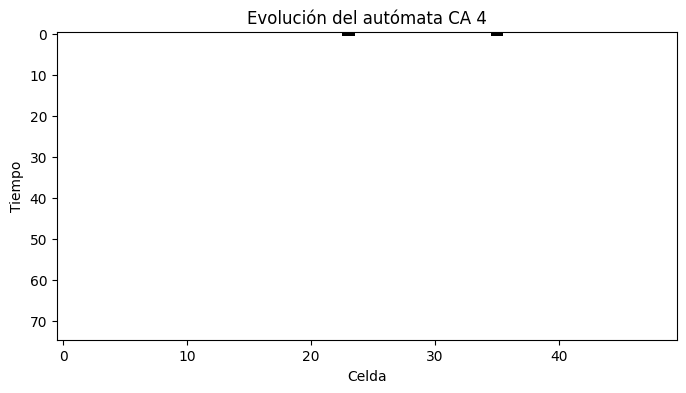

Estado uniforme final:  0


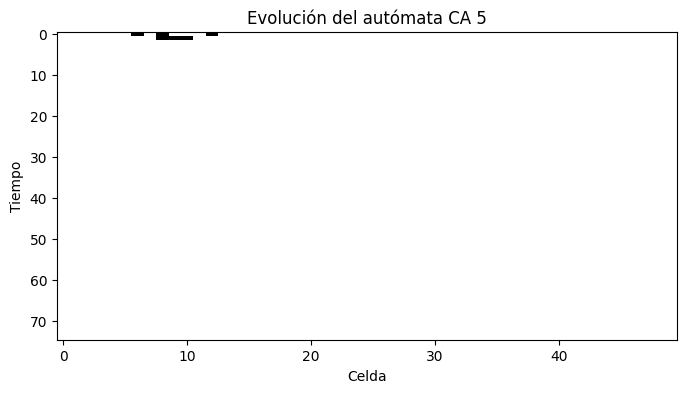

Estado uniforme final:  0


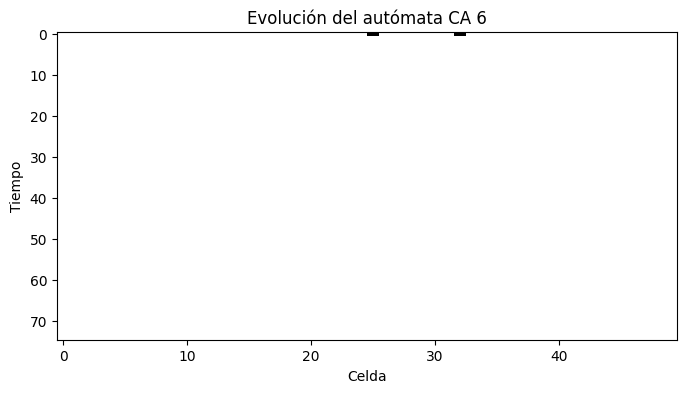

Estado uniforme final:  0


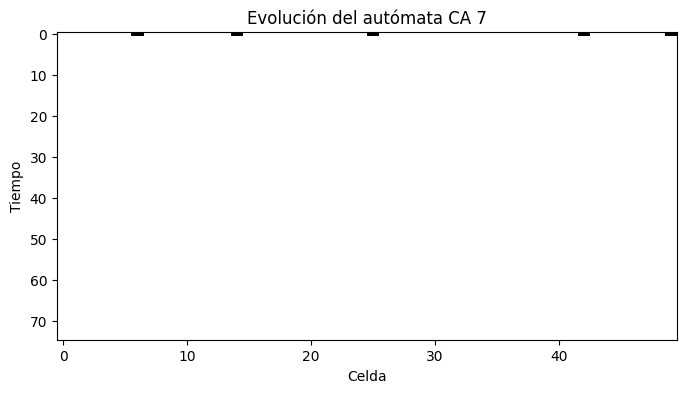

Estado uniforme final:  0


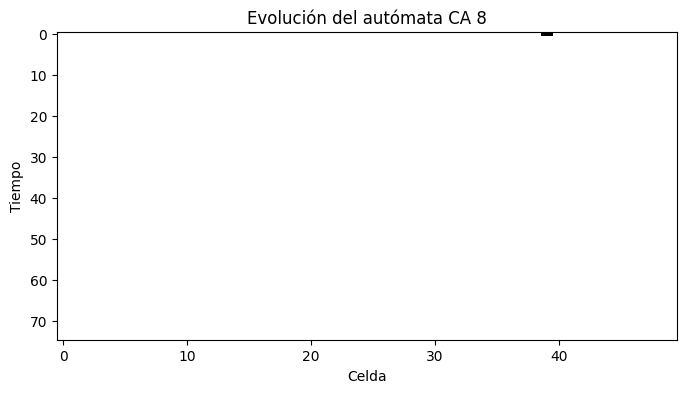

Estado uniforme final:  0


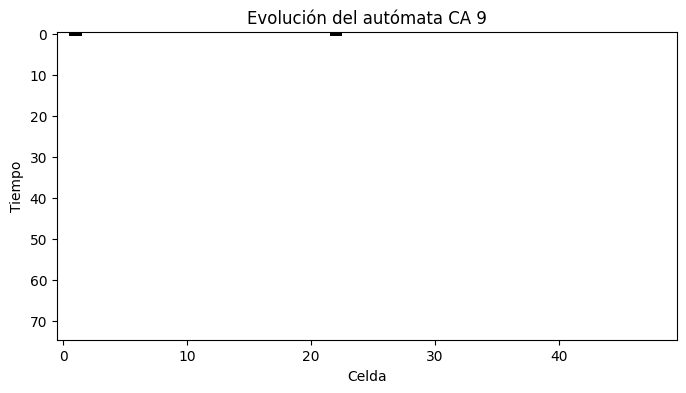

Estado uniforme final:  0


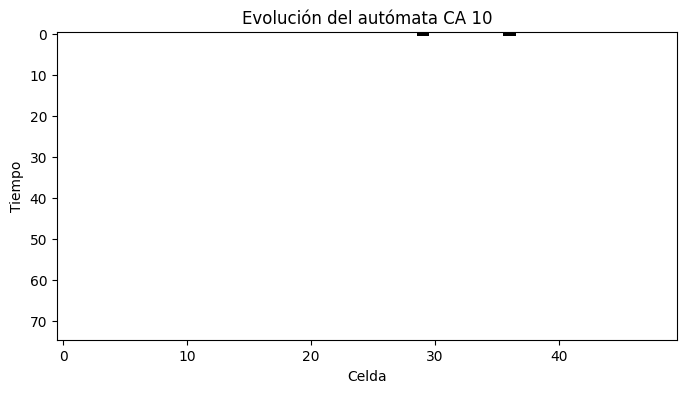

Estado uniforme final:  0


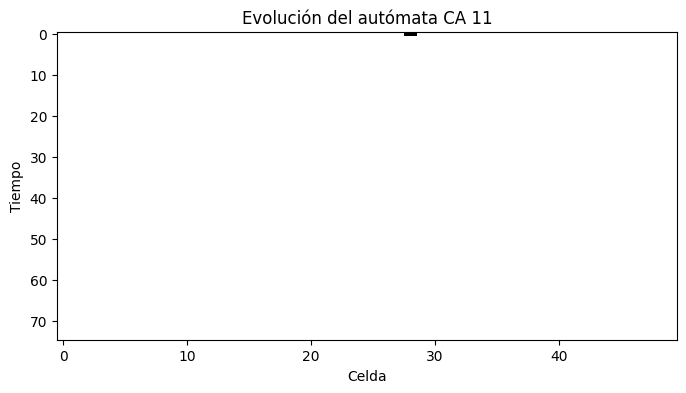

Estado uniforme final:  0


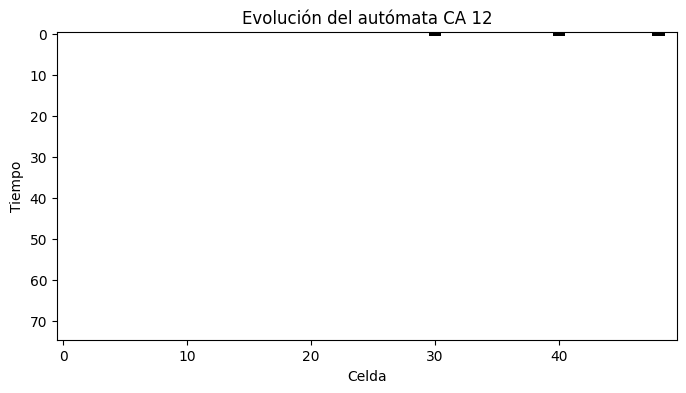

Estado uniforme final:  0


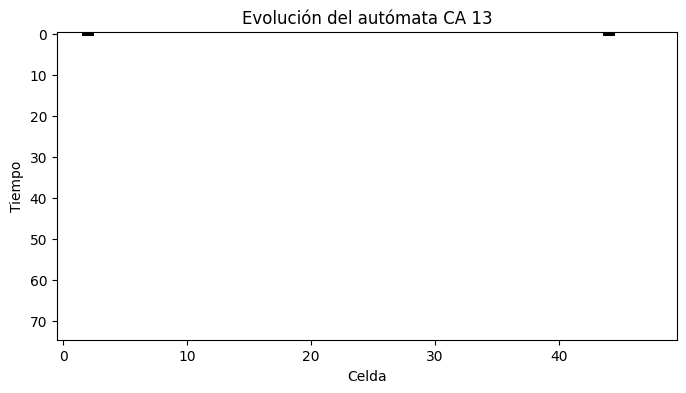

Estado uniforme final:  0


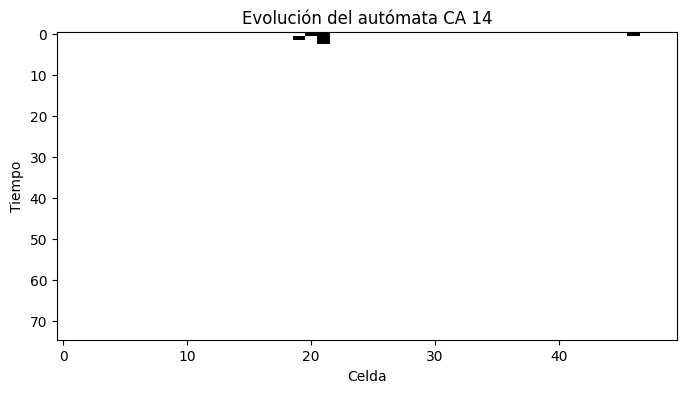

Estado uniforme final:  0


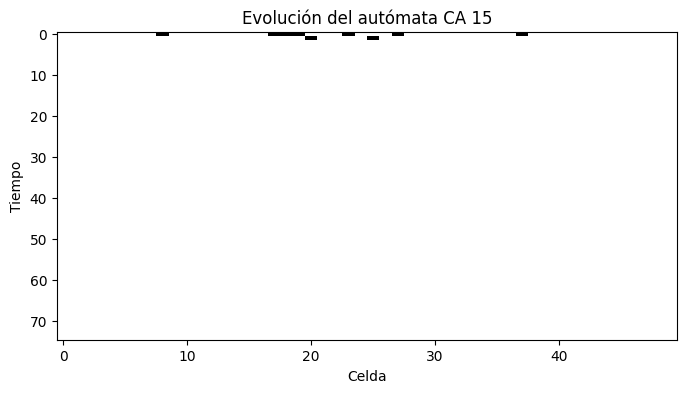

Estado uniforme final:  0


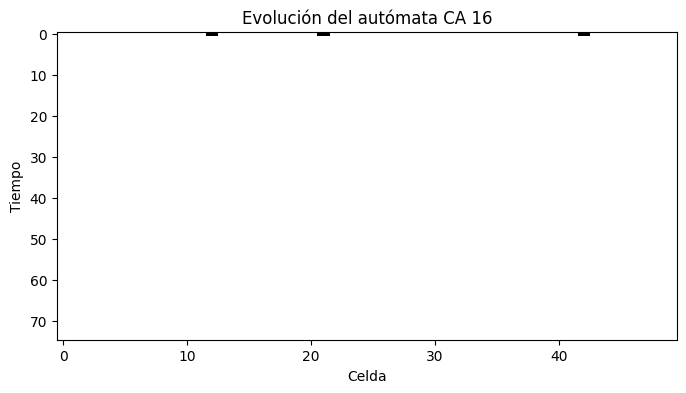

Estado uniforme final:  0


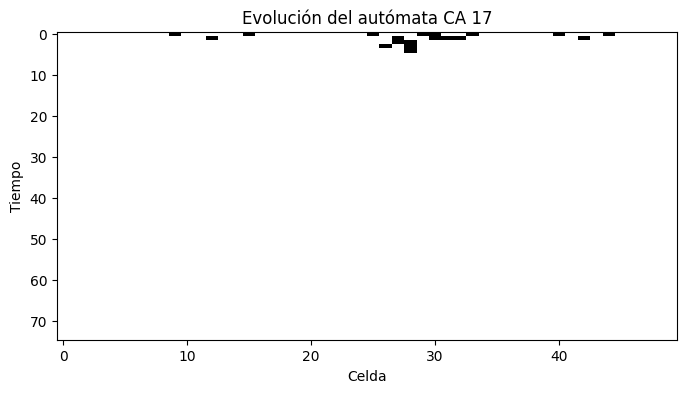

Estado uniforme final:  0


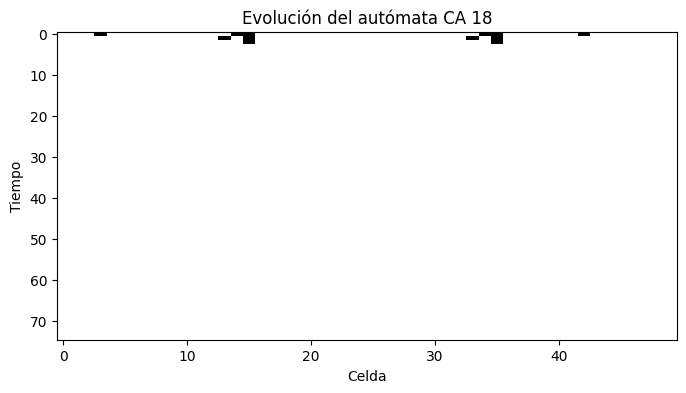

Estado uniforme final:  0


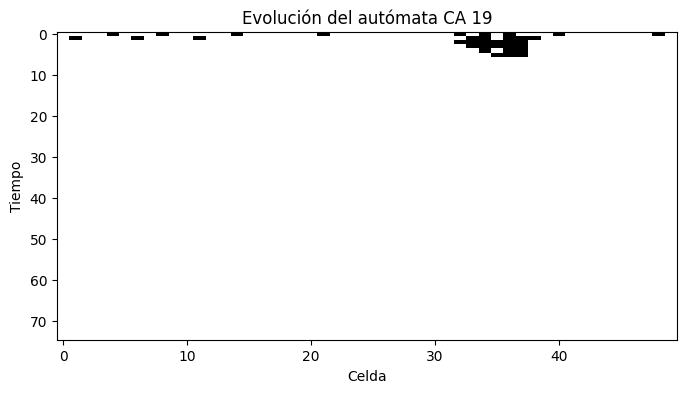

Estado uniforme final:  0


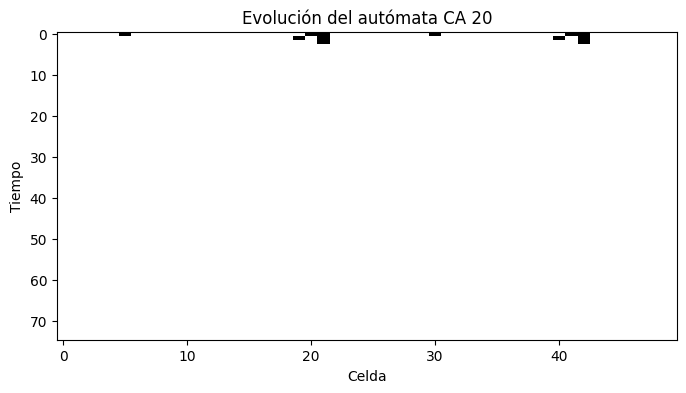

Estado uniforme final:  0


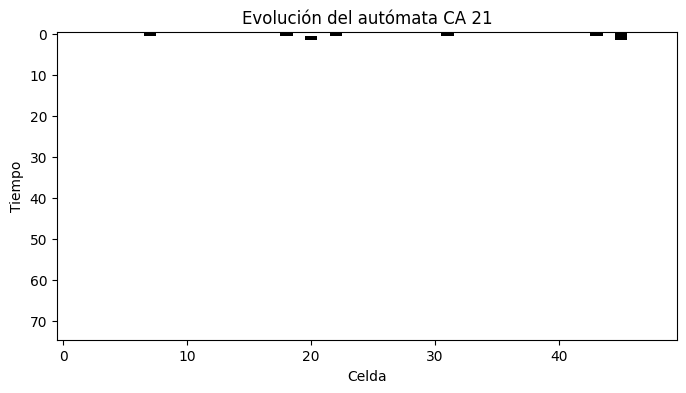

Estado uniforme final:  0


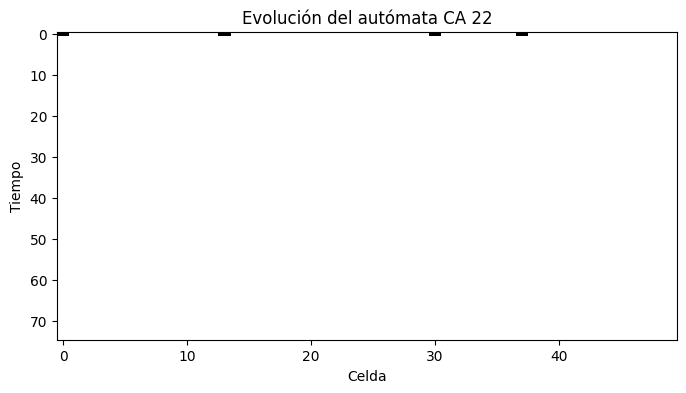

Estado uniforme final:  0


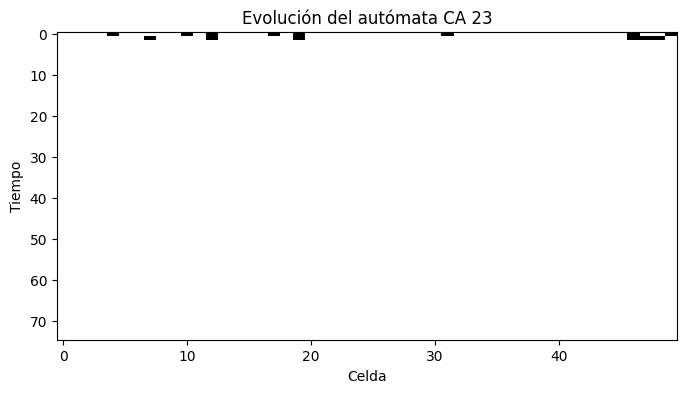

Estado uniforme final:  0


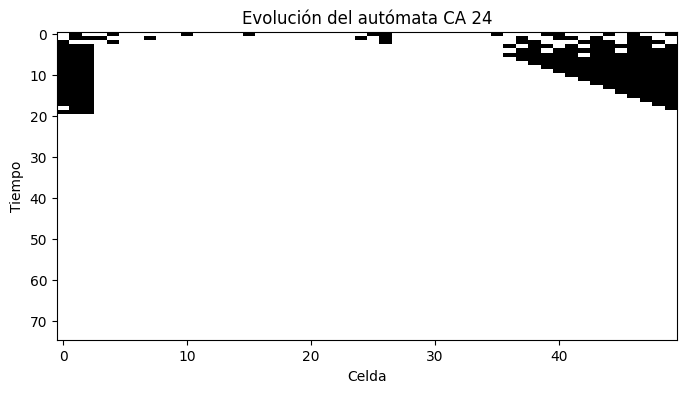

Estado uniforme final:  0


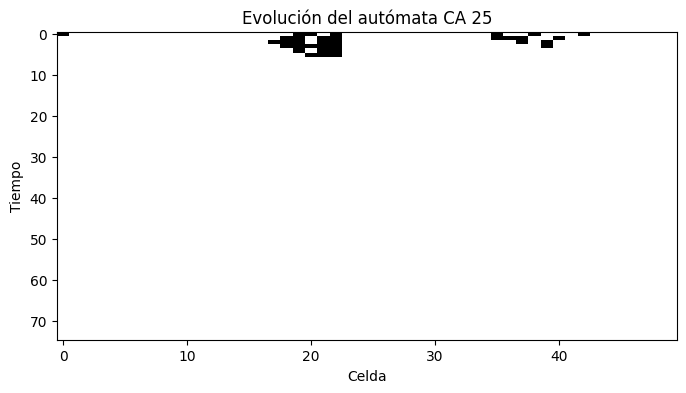

Estado uniforme final:  0


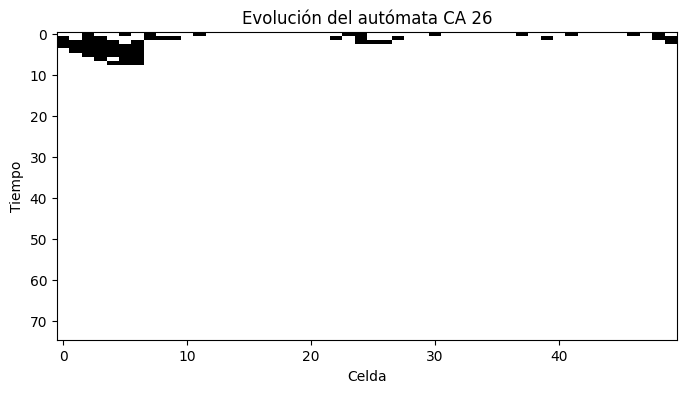

Estado uniforme final:  0


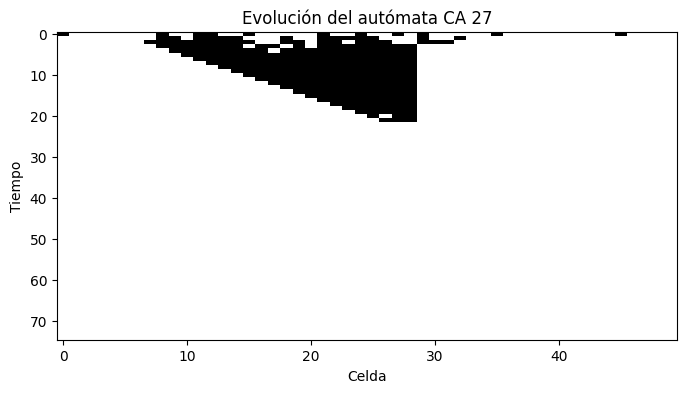

Estado uniforme final:  0


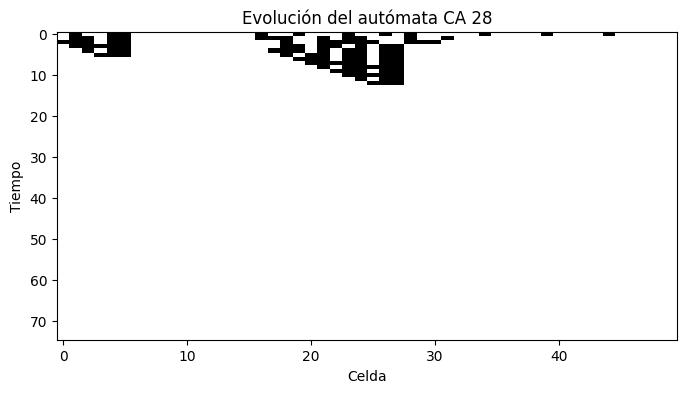

Estado uniforme final:  0


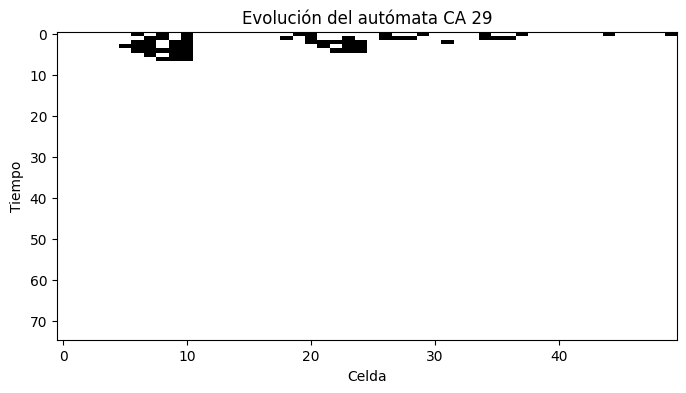

Estado uniforme final:  0


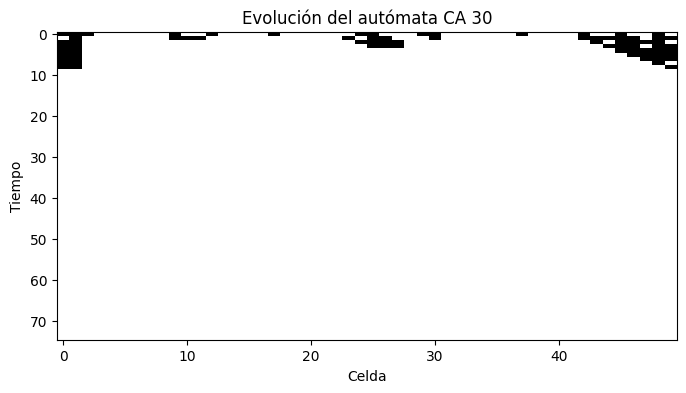

Estado uniforme final:  0


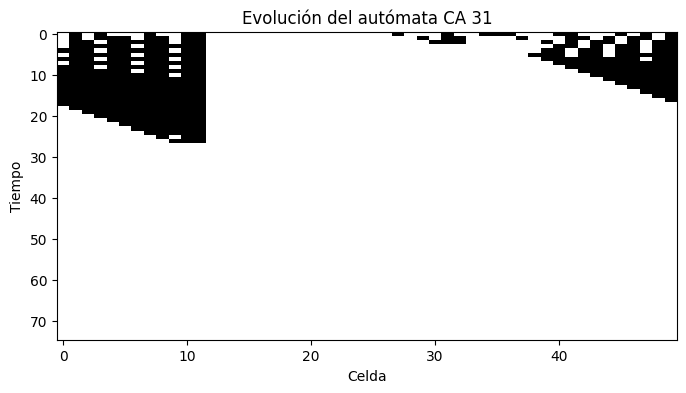

Estado uniforme final:  0


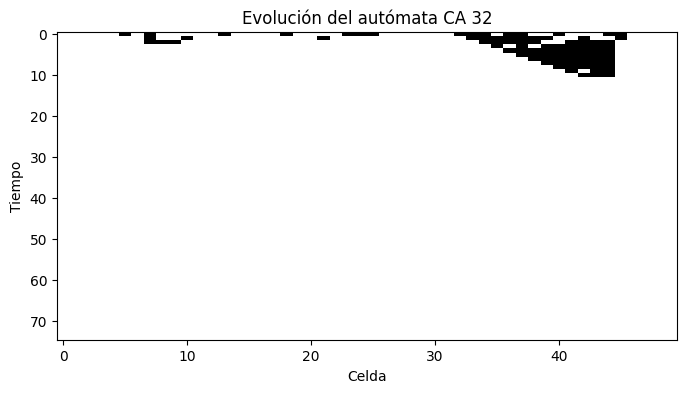

Estado uniforme final:  0


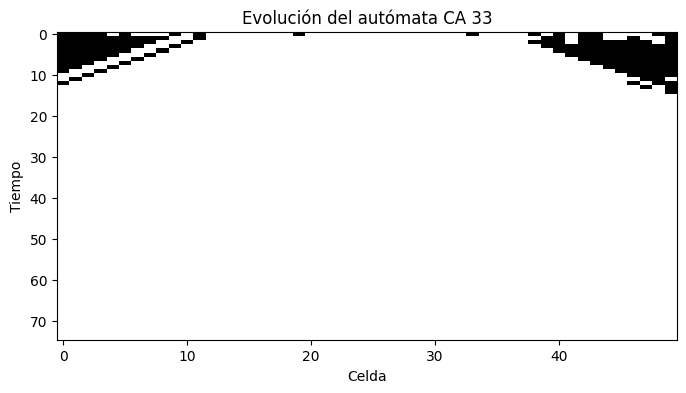

Estado uniforme final:  0


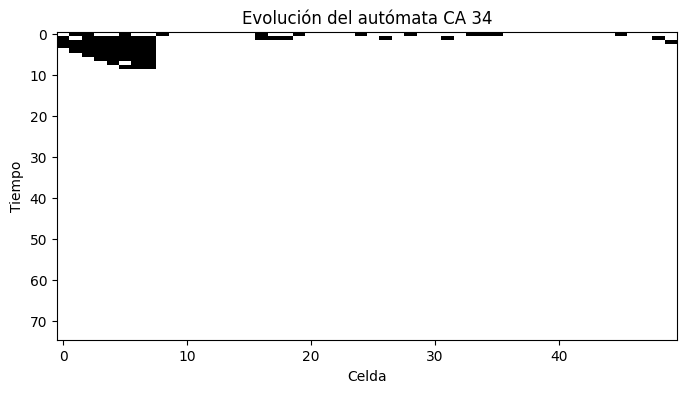

Estado uniforme final:  0


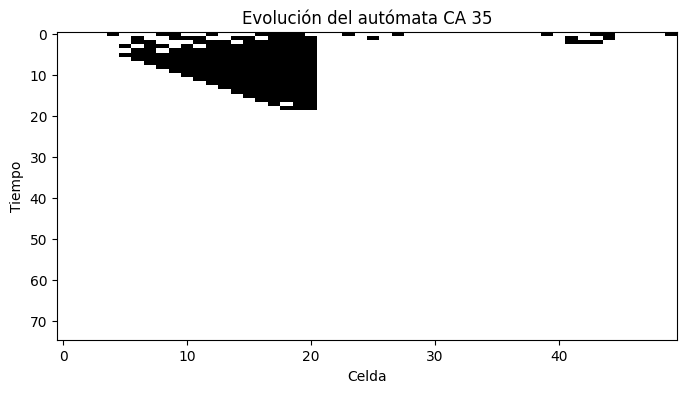

Estado uniforme final:  0


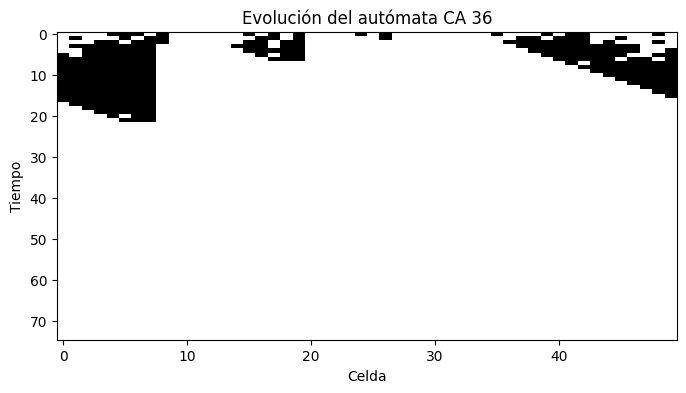

Estado uniforme final:  0


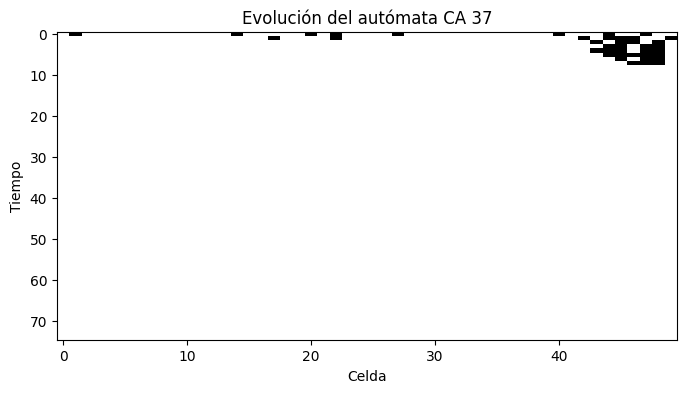

Estado uniforme final:  0


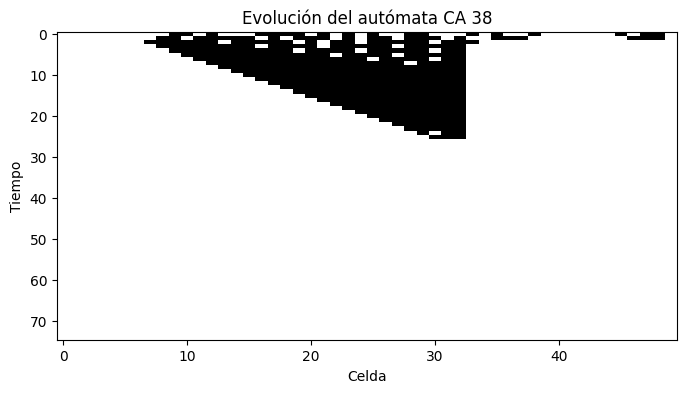

Estado uniforme final:  0


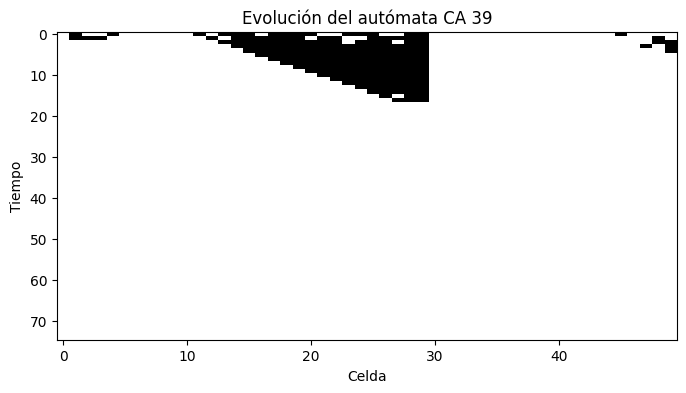

Estado uniforme final:  0


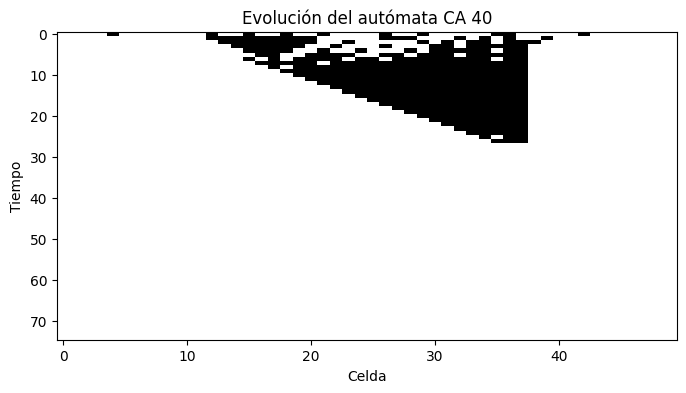

Estado uniforme final:  0


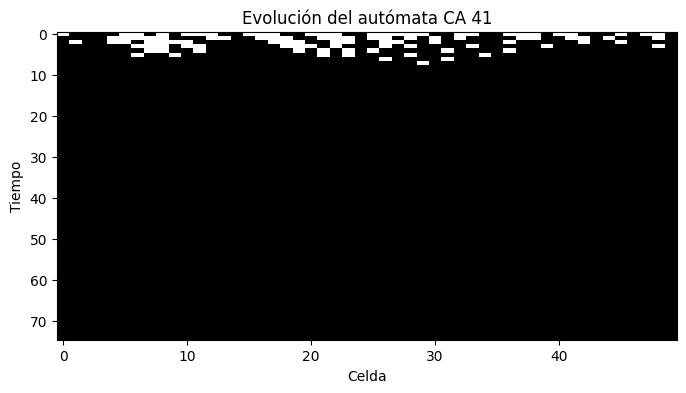

Estado uniforme final:  0


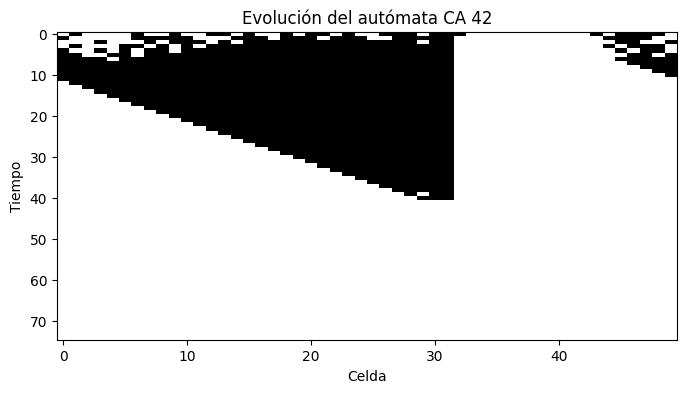

Estado uniforme final:  0


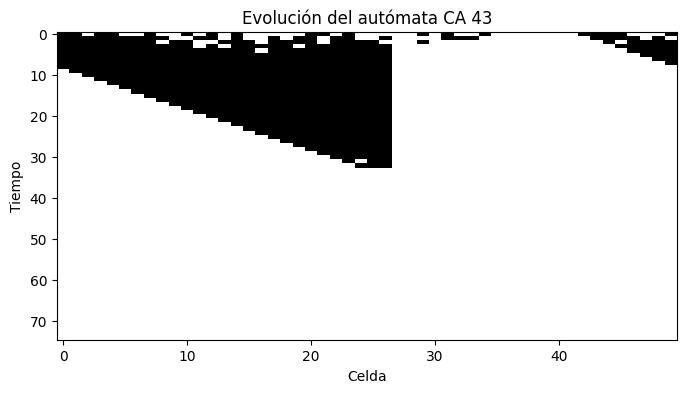

Estado uniforme final:  0


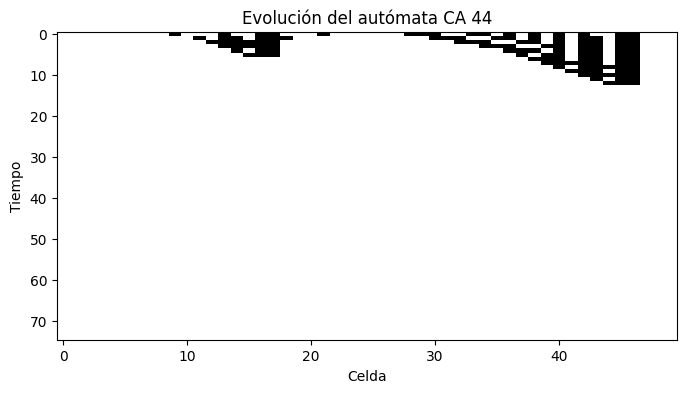

Estado uniforme final:  0


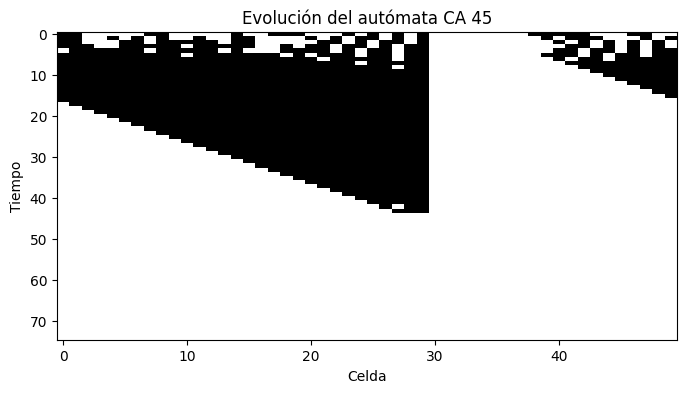

Estado uniforme final:  0


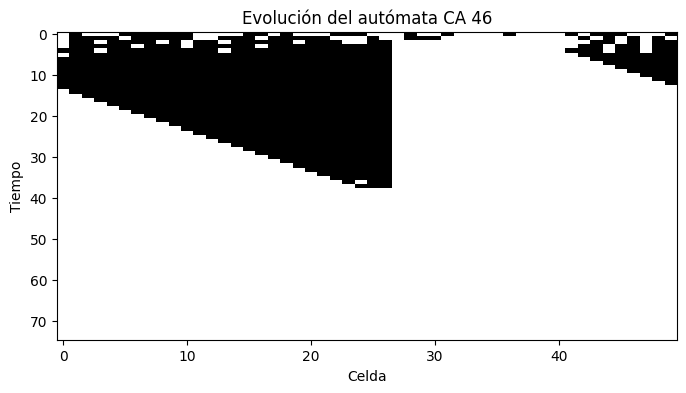

Estado uniforme final:  0


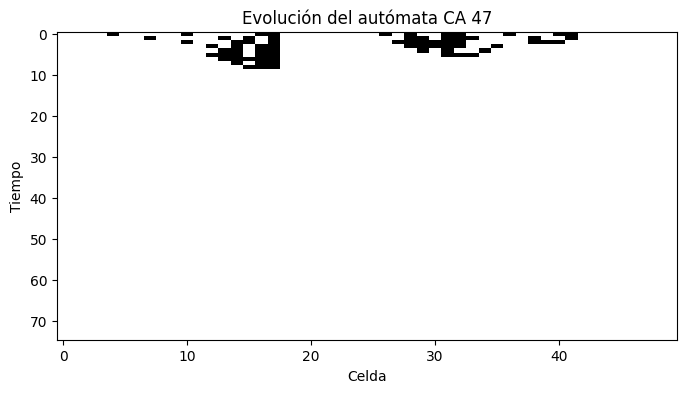

Estado uniforme final:  0


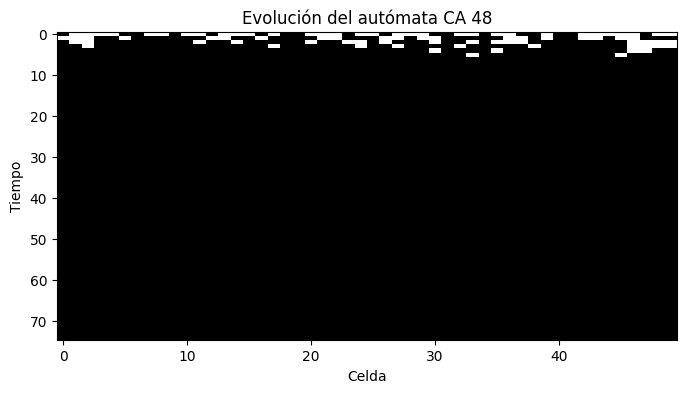

Estado uniforme final:  0


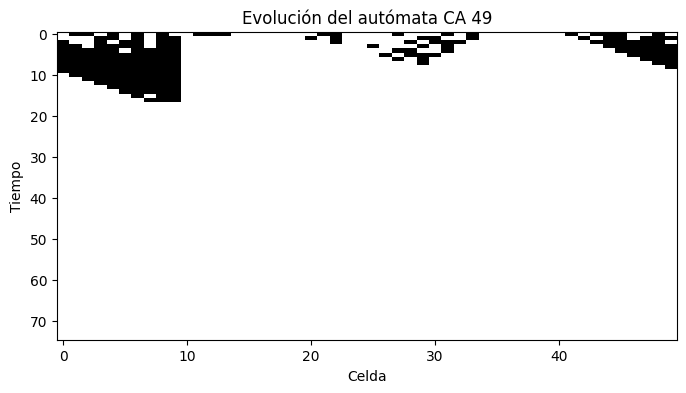

Estado uniforme final:  0


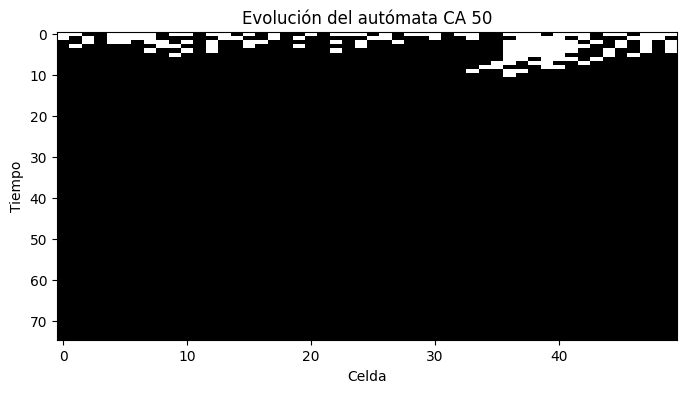

Estado uniforme final:  0


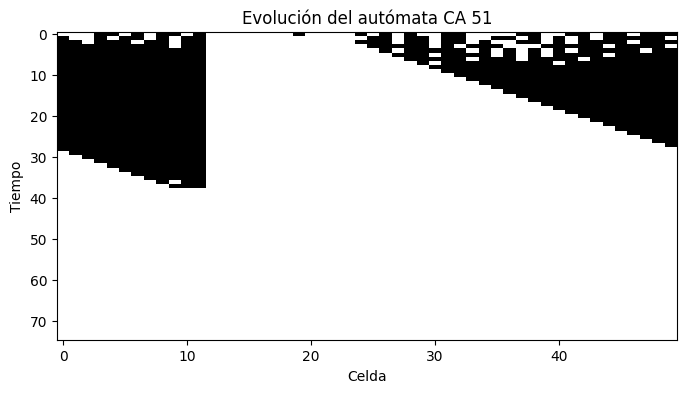

Estado uniforme final:  0


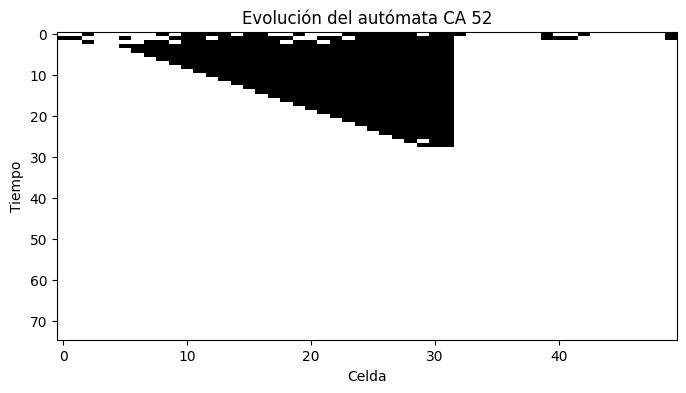

Estado uniforme final:  0


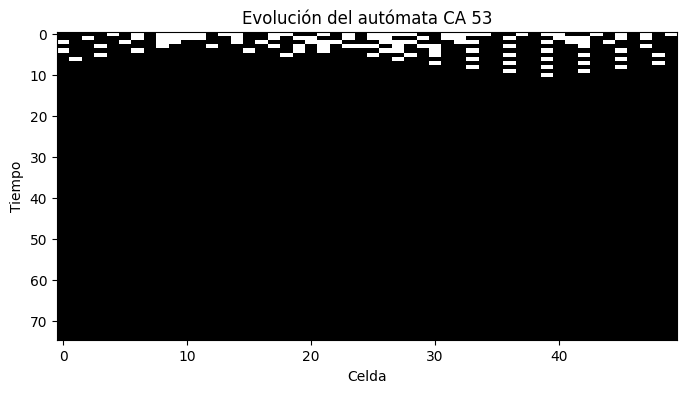

Estado uniforme final:  0


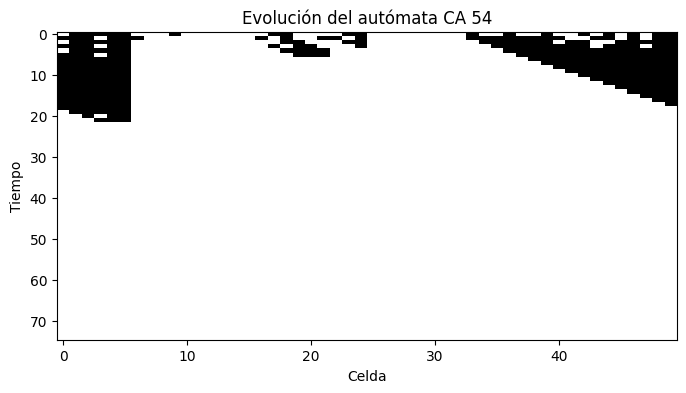

Estado uniforme final:  0


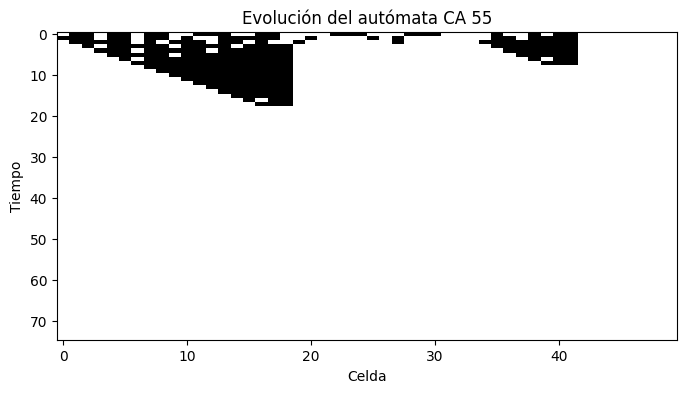

Estado uniforme final:  1


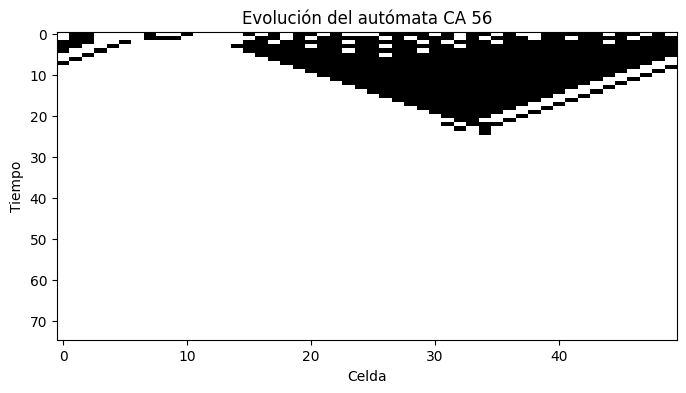

Estado uniforme final:  1


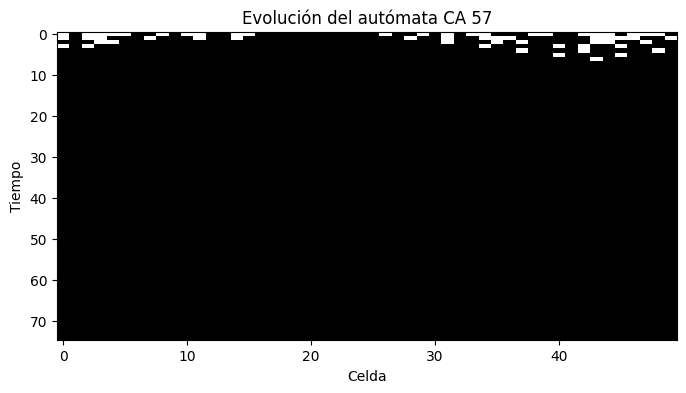

Estado uniforme final:  0


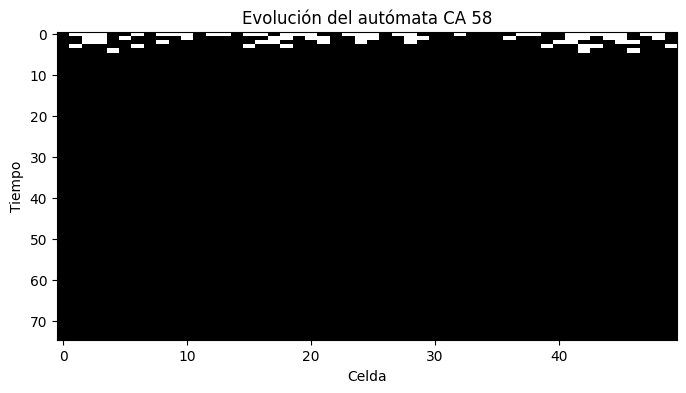

Estado uniforme final:  0


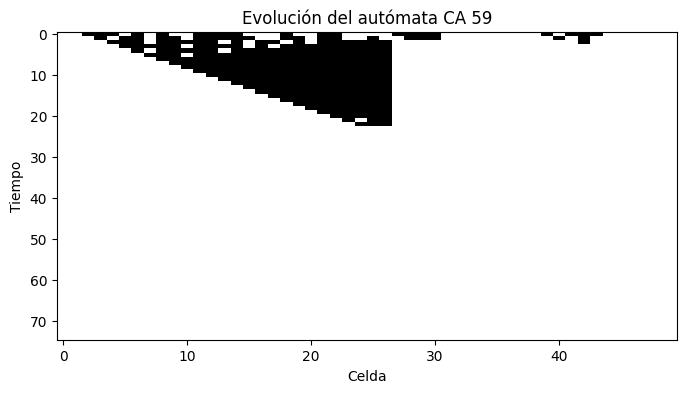

Estado uniforme final:  1


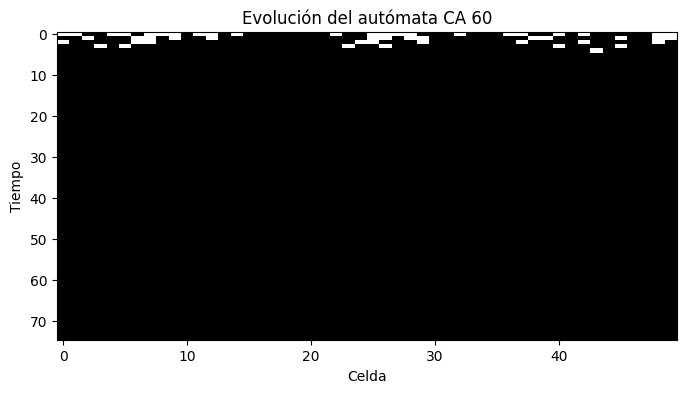

Estado uniforme final:  0


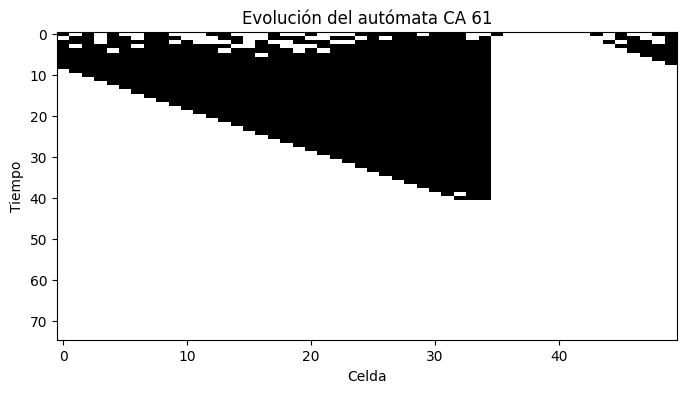

Estado uniforme final:  1


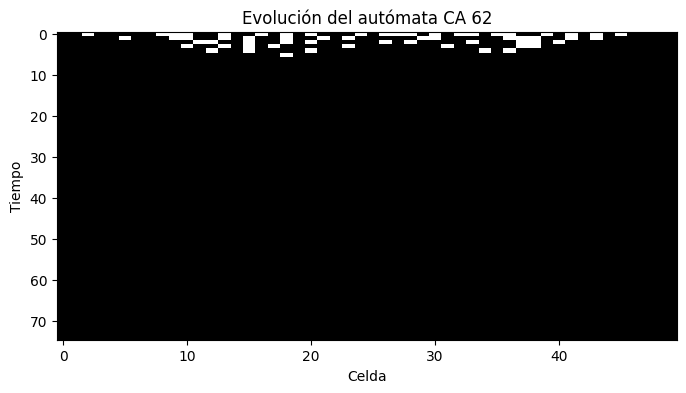

Estado uniforme final:  0


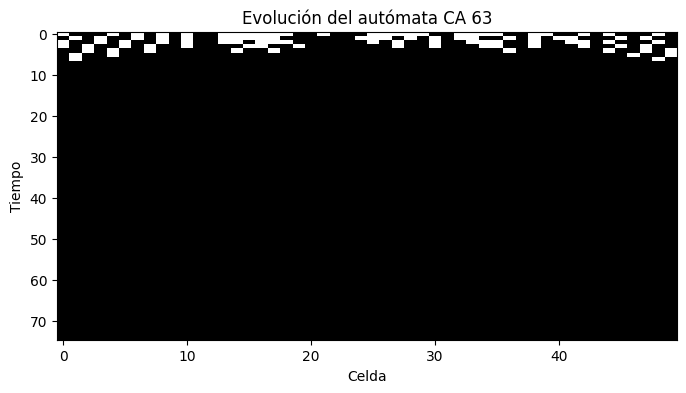

Estado uniforme final:  0


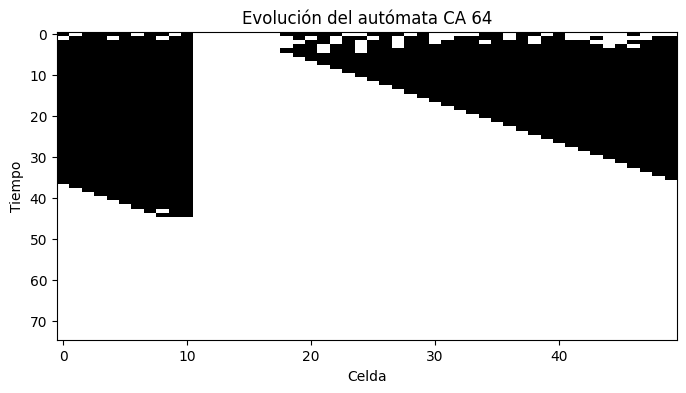

Estado uniforme final:  0


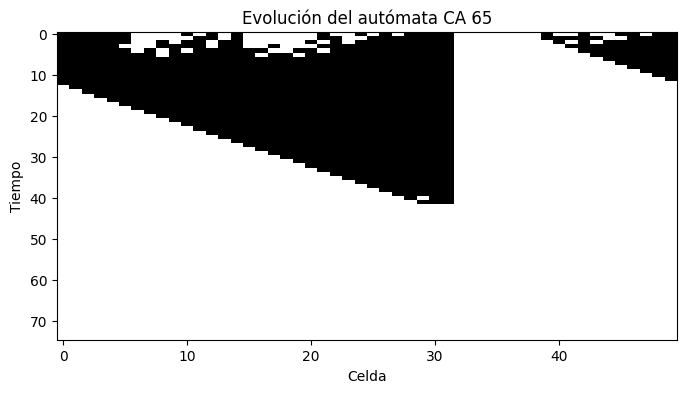

Estado uniforme final:  1


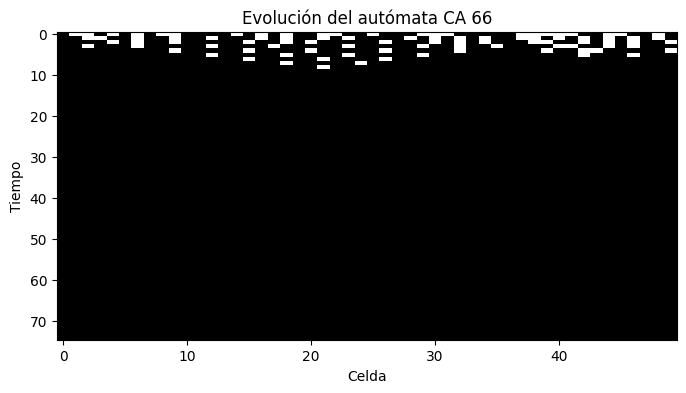

Estado uniforme final:  1


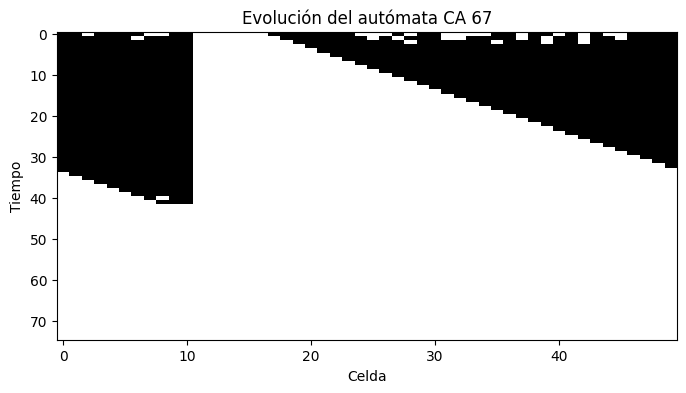

Estado uniforme final:  1


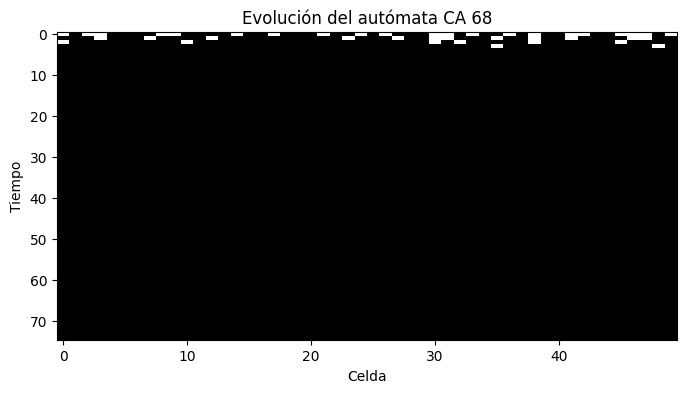

Estado uniforme final:  1


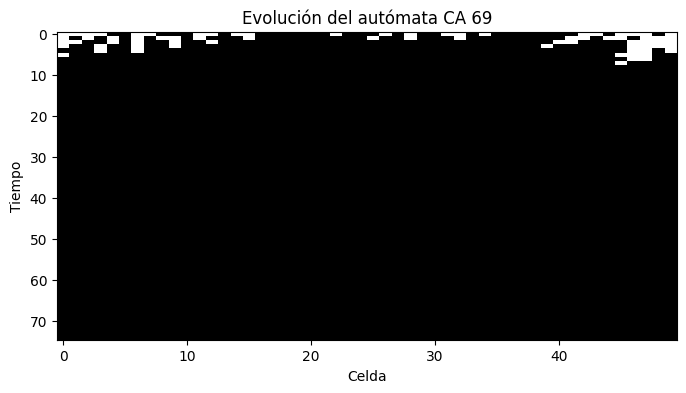

Estado uniforme final:  1


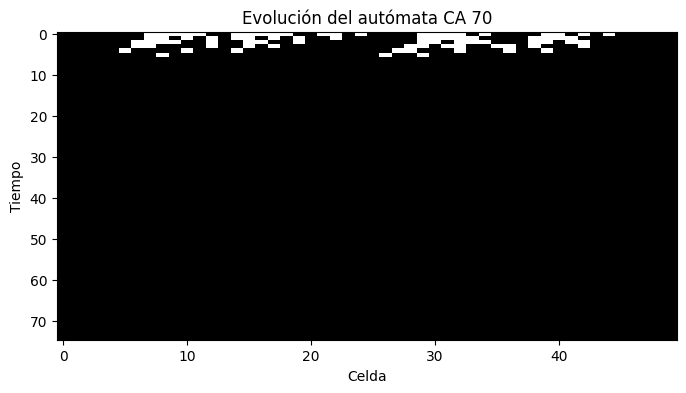

Estado uniforme final:  1


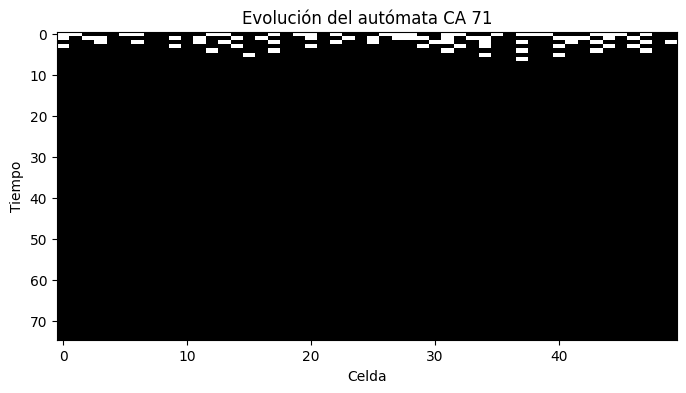

Estado uniforme final:  0


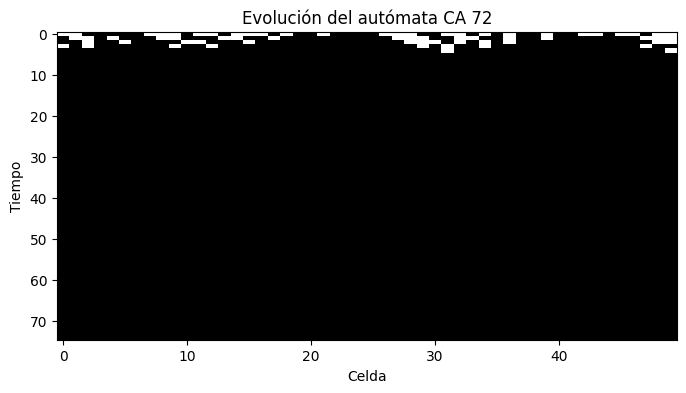

Estado uniforme final:  1


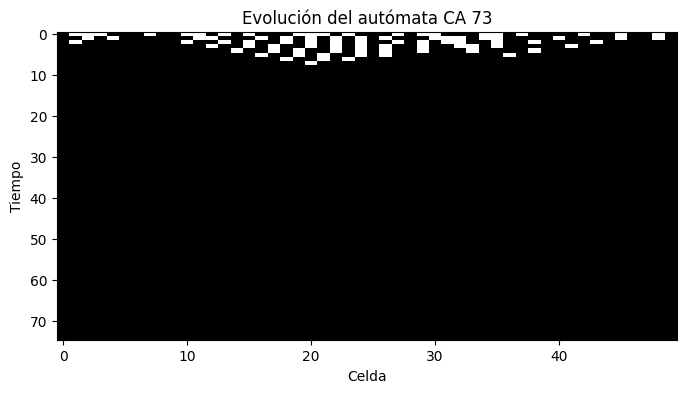

Estado uniforme final:  1


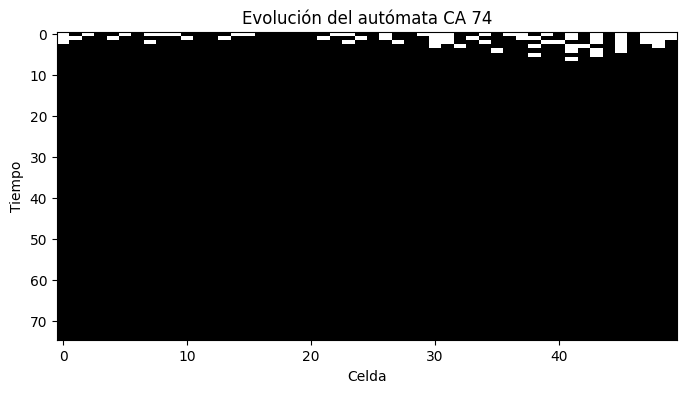

Estado uniforme final:  1


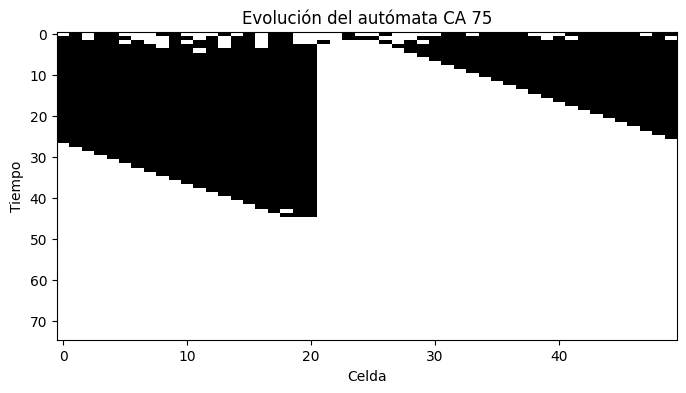

Estado uniforme final:  1


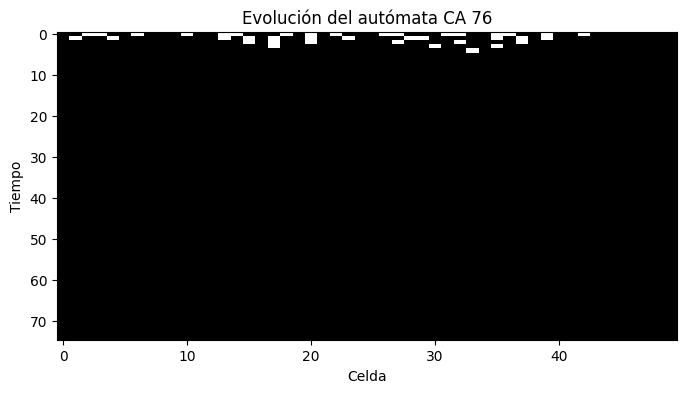

Estado uniforme final:  1


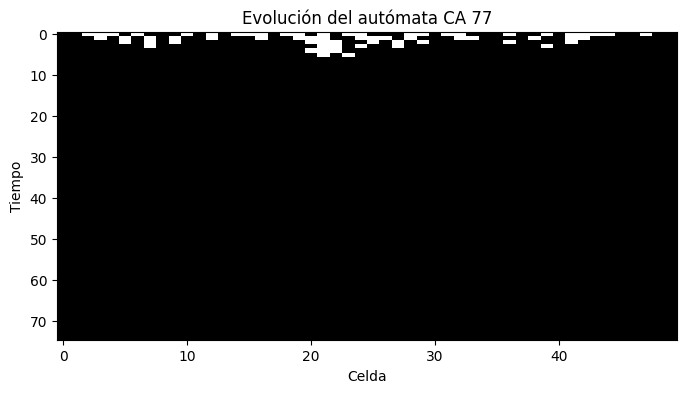

Estado uniforme final:  1


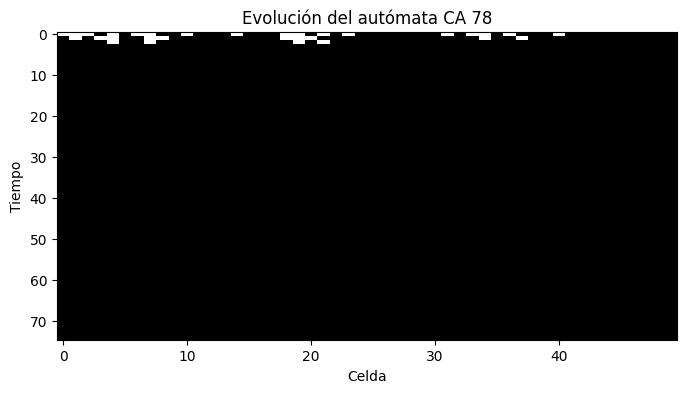

Estado uniforme final:  0


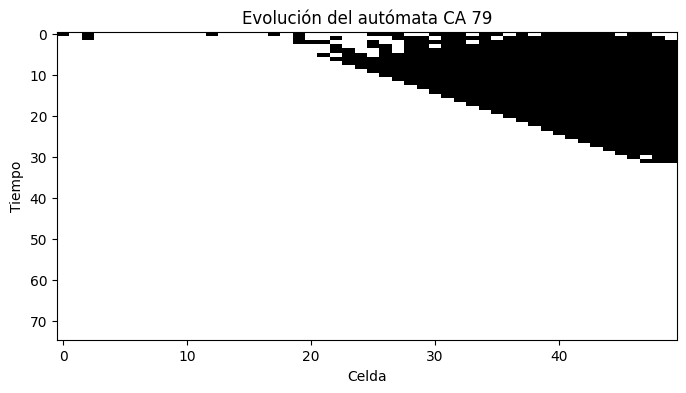

Estado uniforme final:  1


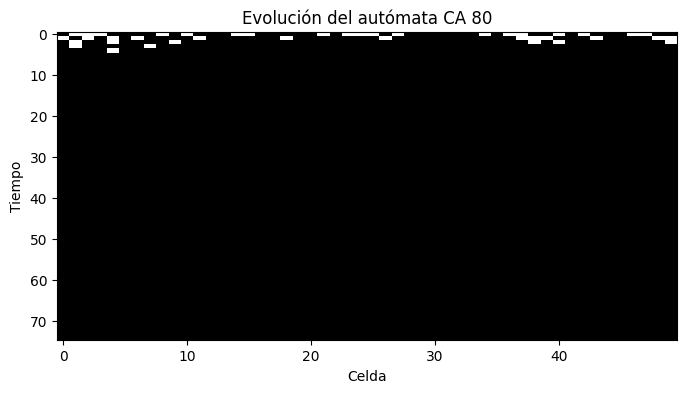

Estado uniforme final:  1


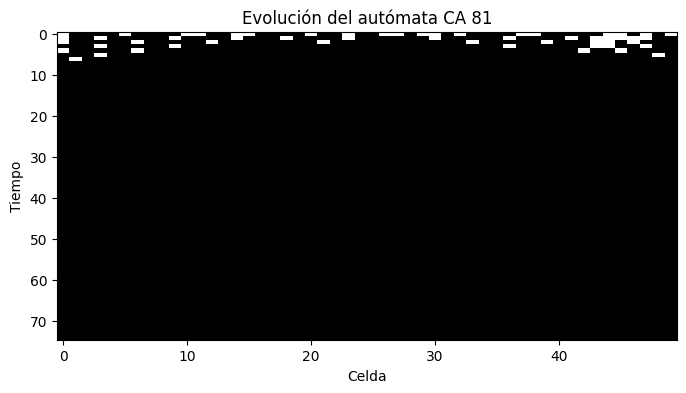

Estado uniforme final:  1


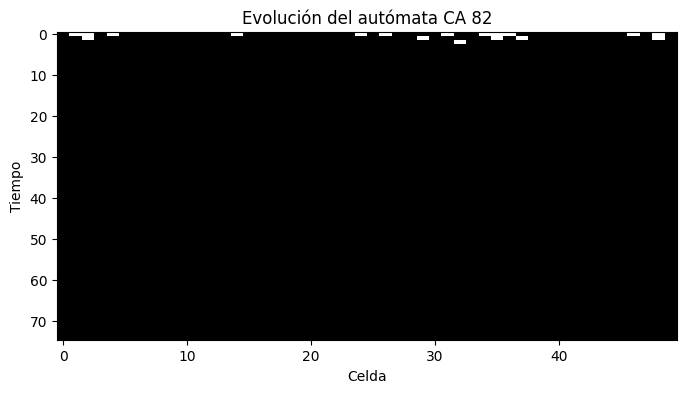

Estado uniforme final:  1


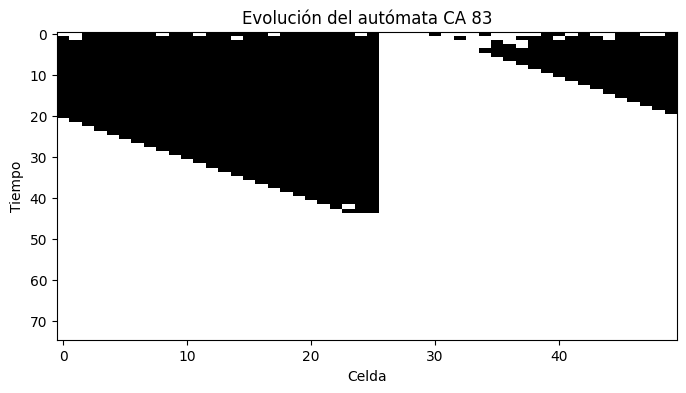

Estado uniforme final:  1


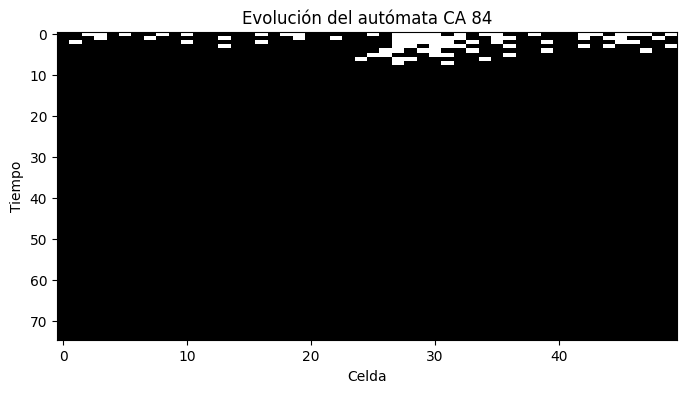

Estado uniforme final:  1


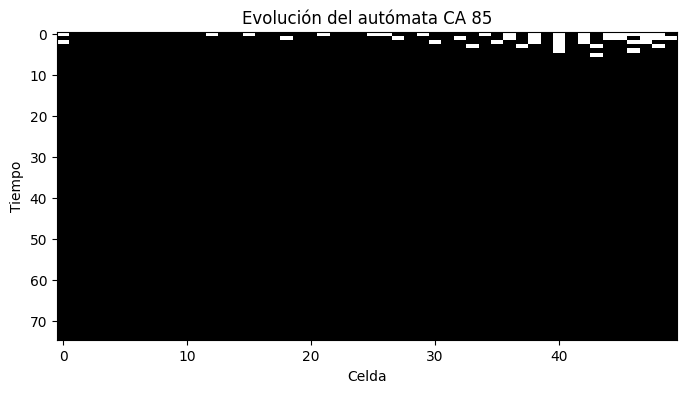

Estado uniforme final:  1


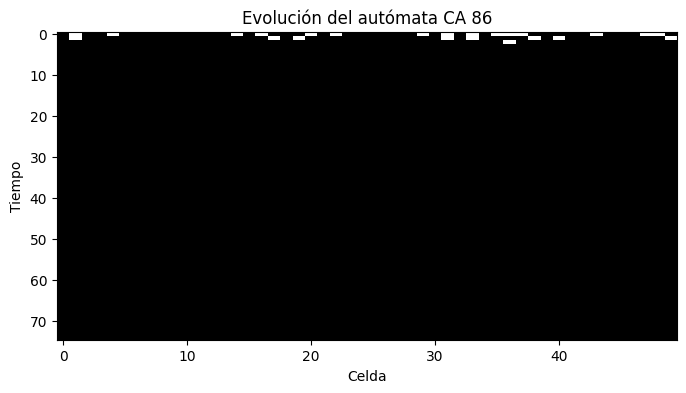

Estado uniforme final:  1


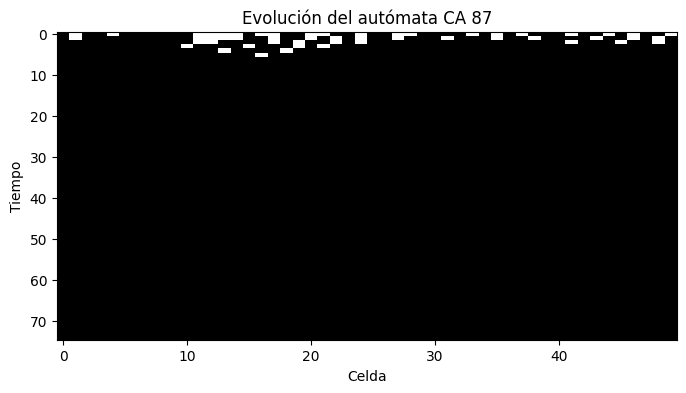

Estado uniforme final:  1


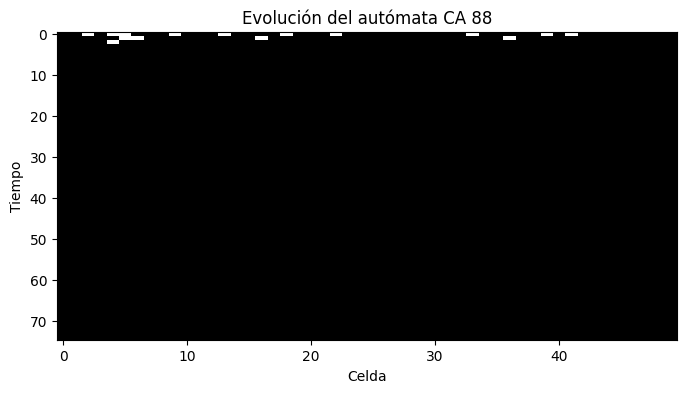

Estado uniforme final:  1


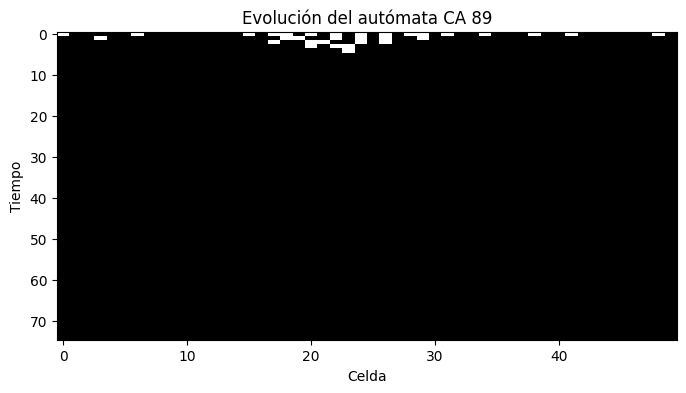

Estado uniforme final:  1


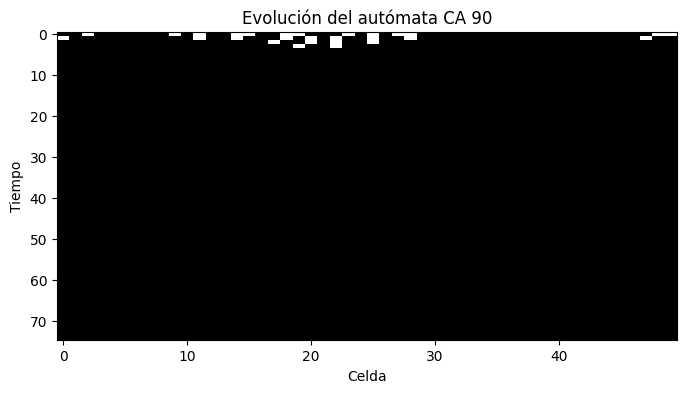

Estado uniforme final:  1


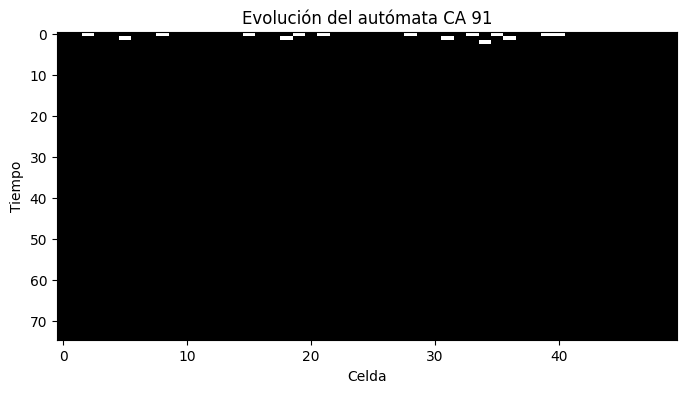

Estado uniforme final:  1


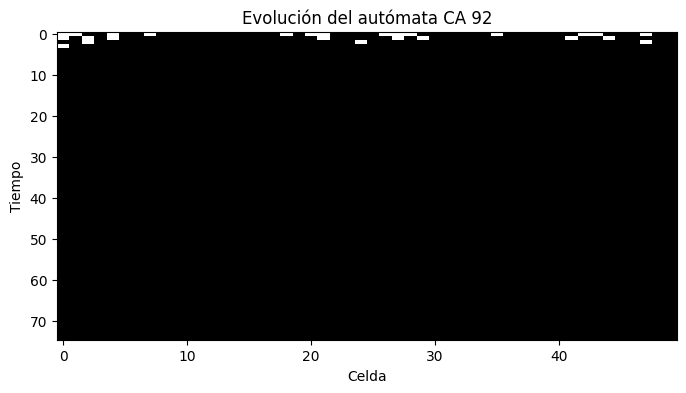

Estado uniforme final:  1


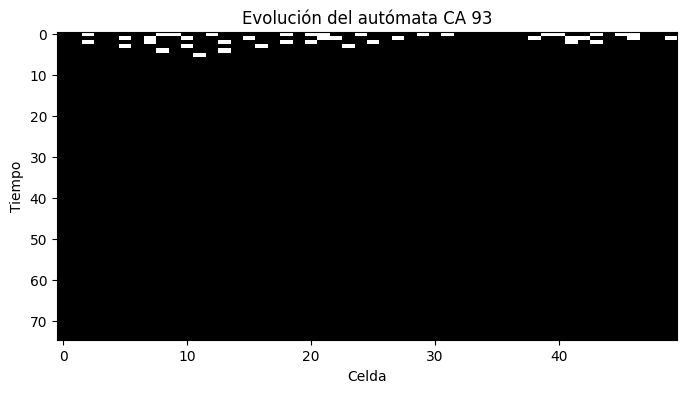

Estado uniforme final:  1


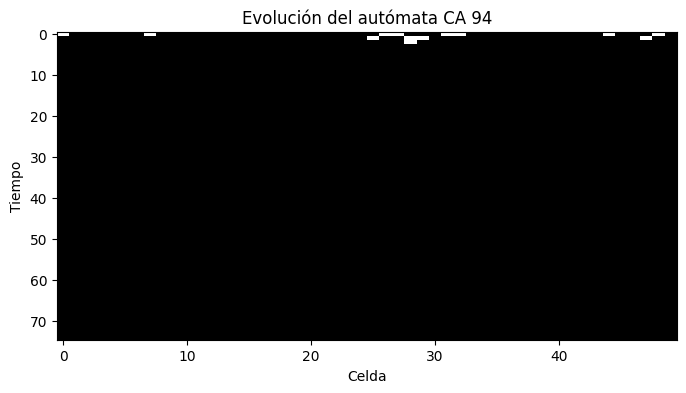

Estado uniforme final:  1


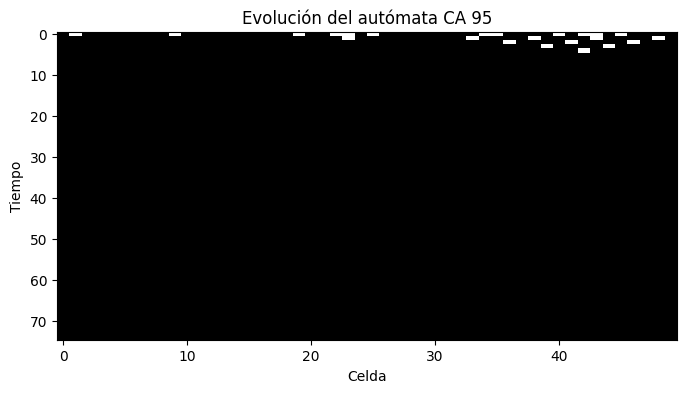

Estado uniforme final:  1


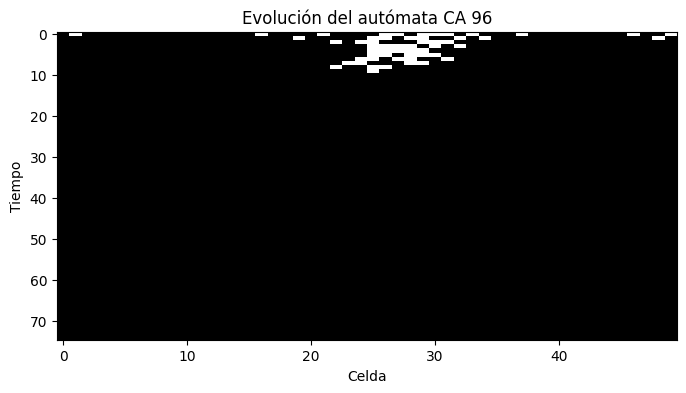

Estado uniforme final:  1


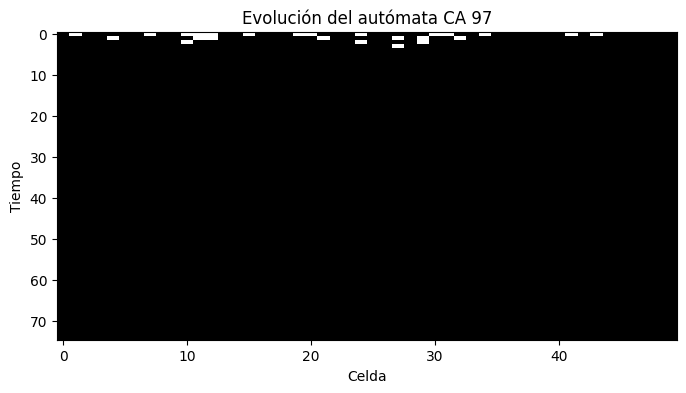

Estado uniforme final:  1


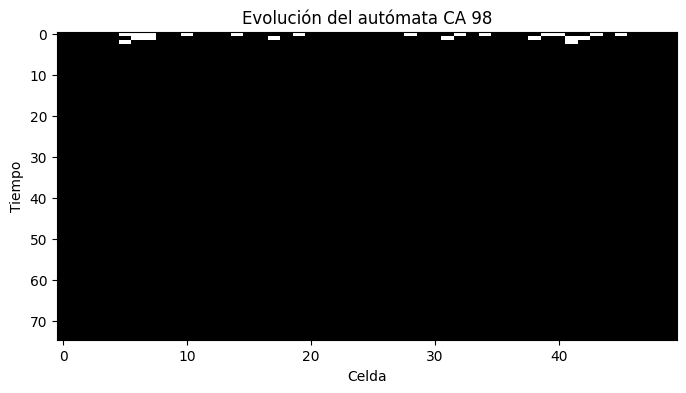

Estado uniforme final:  1


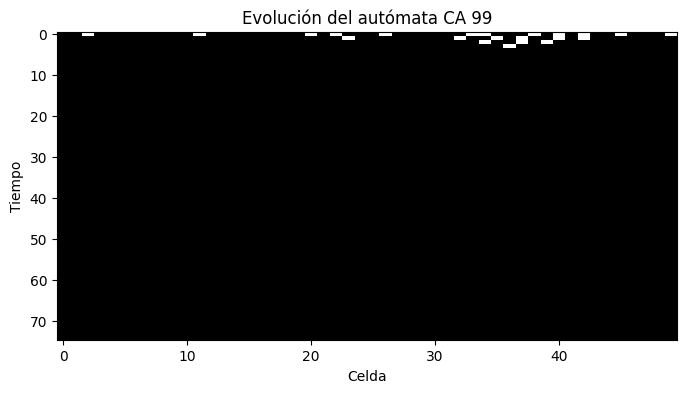

Estado uniforme final:  1


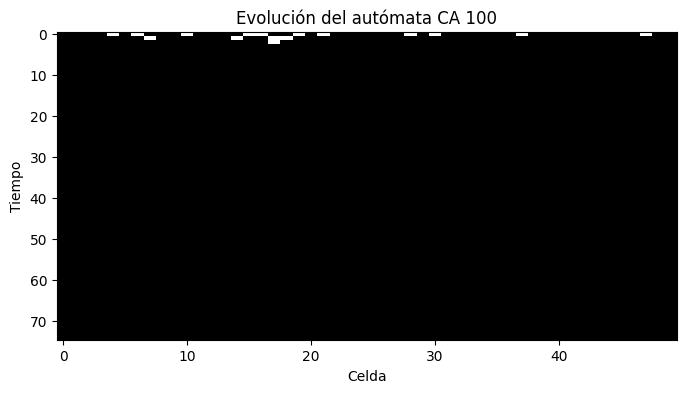

Estado uniforme final:  1


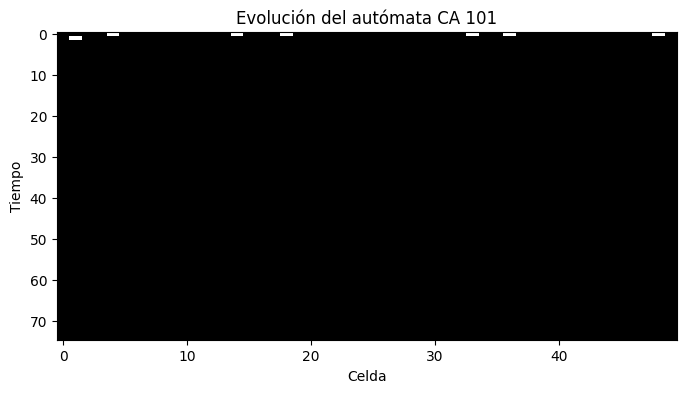

Estado uniforme final:  1


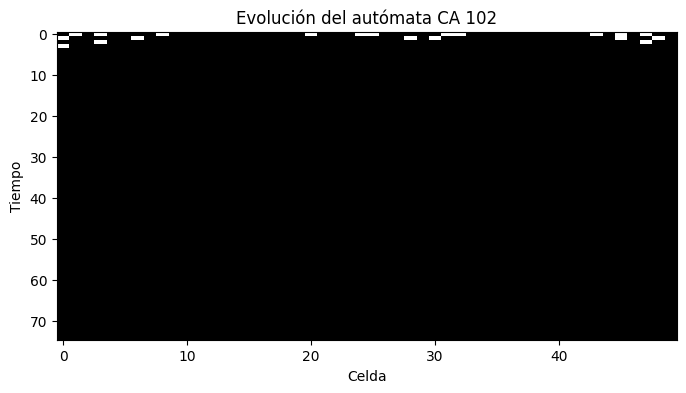

Estado uniforme final:  1


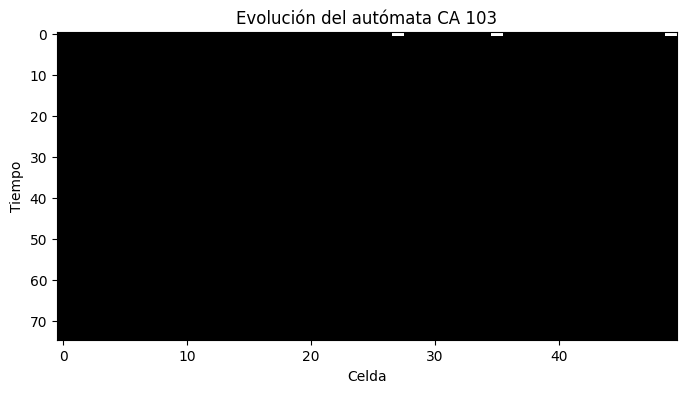

Estado uniforme final:  1


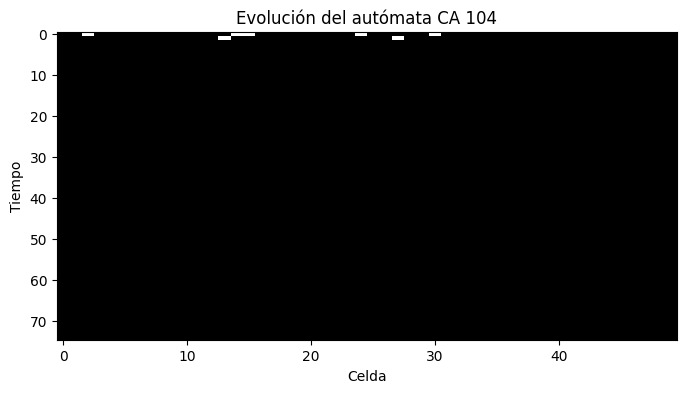

Estado uniforme final:  1


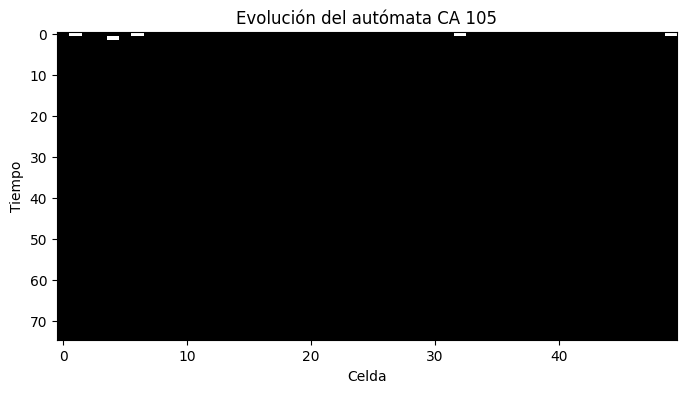

Estado uniforme final:  1


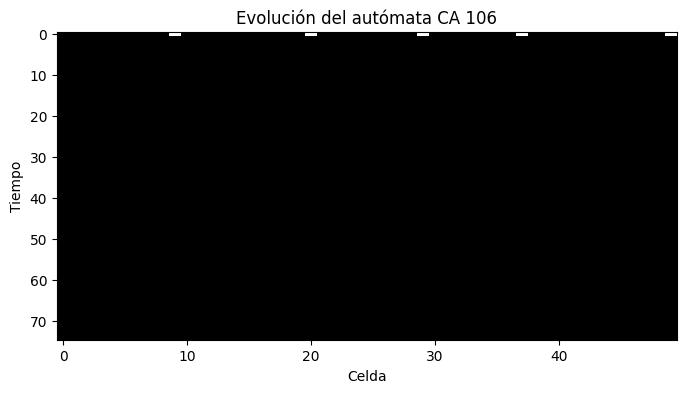

Estado uniforme final:  1


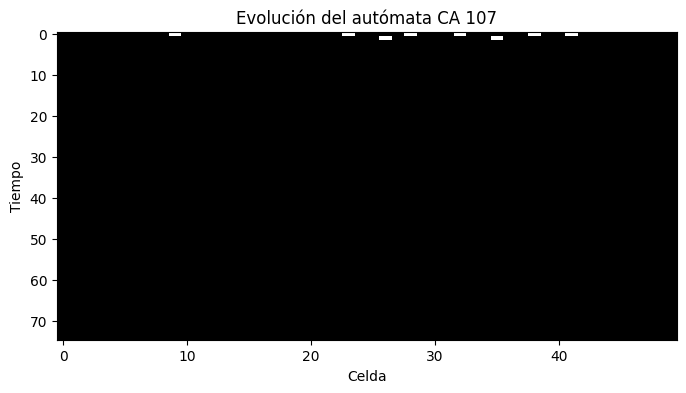

Estado uniforme final:  1


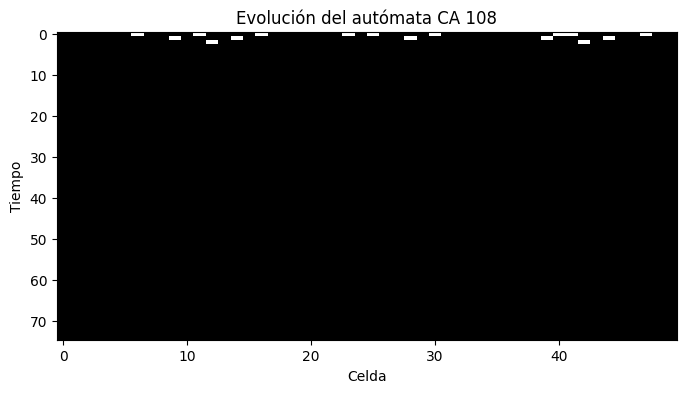

Estado uniforme final:  1


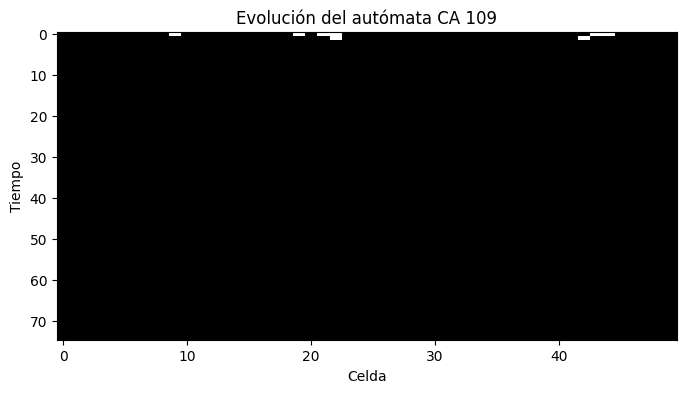

Estado uniforme final:  1


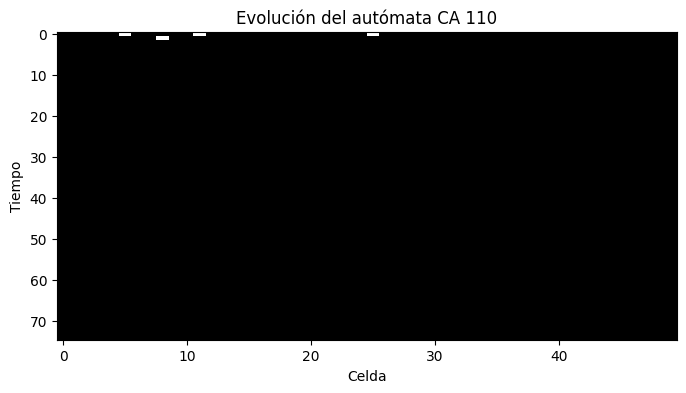

Estado uniforme final:  1


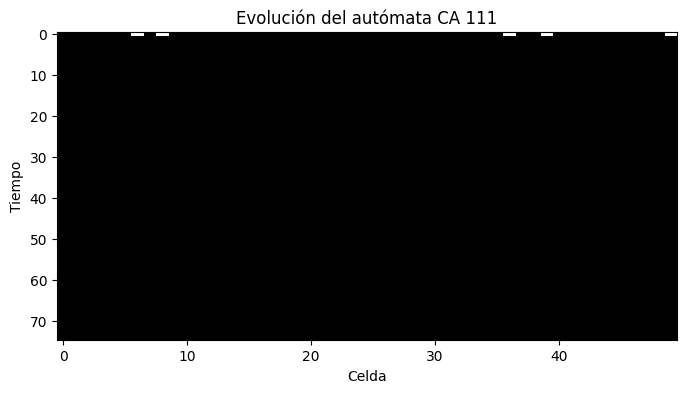

Estado uniforme final:  1


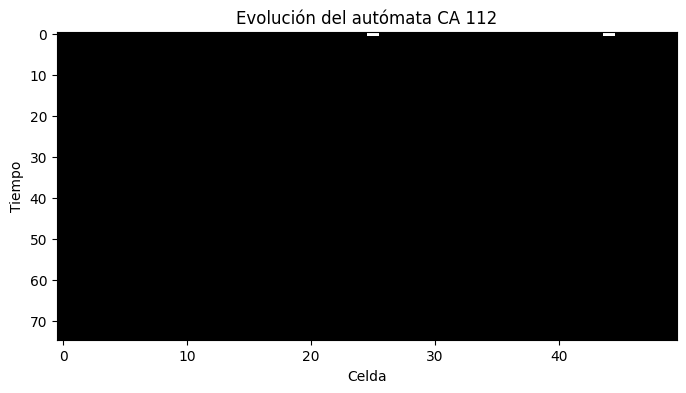

Estado uniforme final:  1


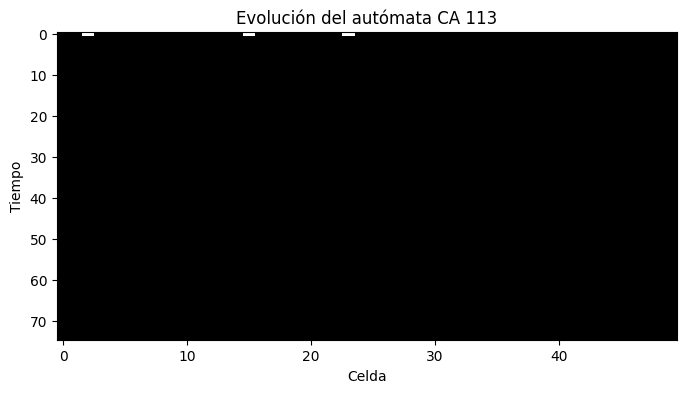

Estado uniforme final:  1


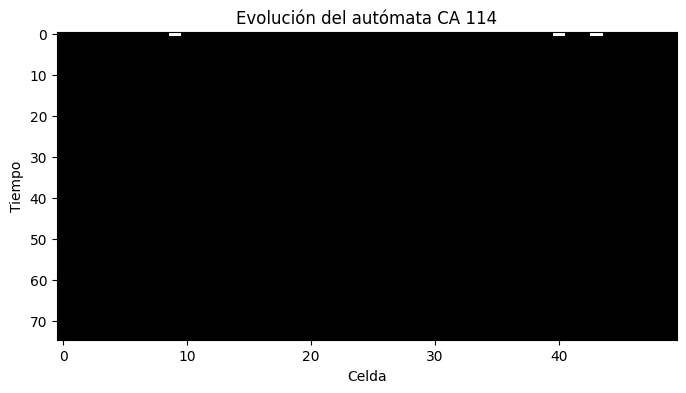

Estado uniforme final:  1


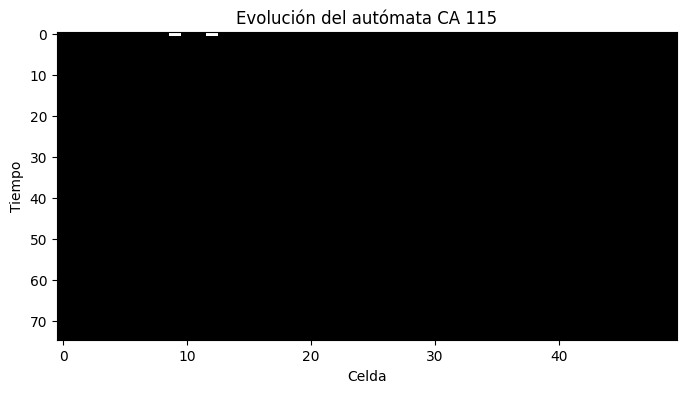

Estado uniforme final:  1


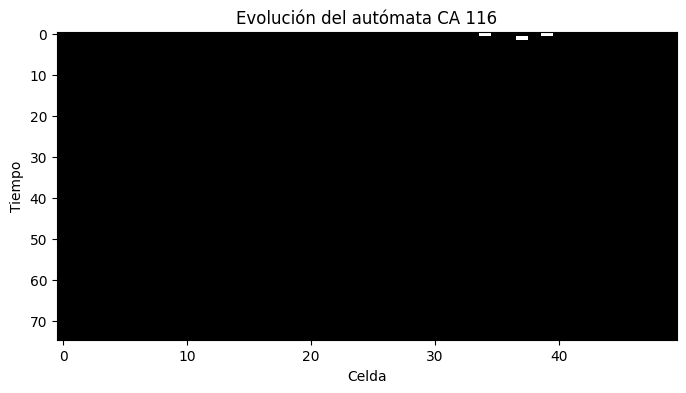

Estado uniforme final:  1


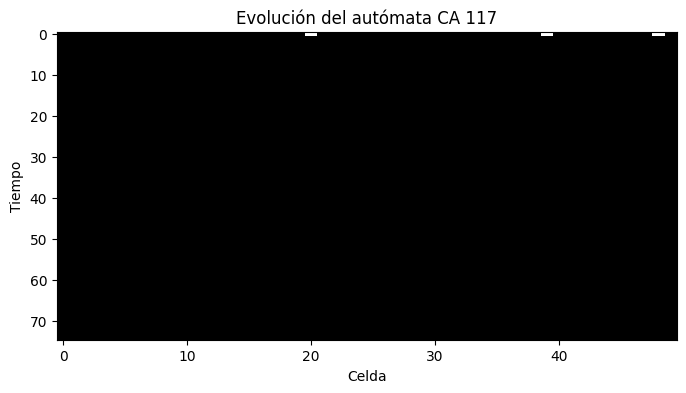

Estado uniforme final:  1


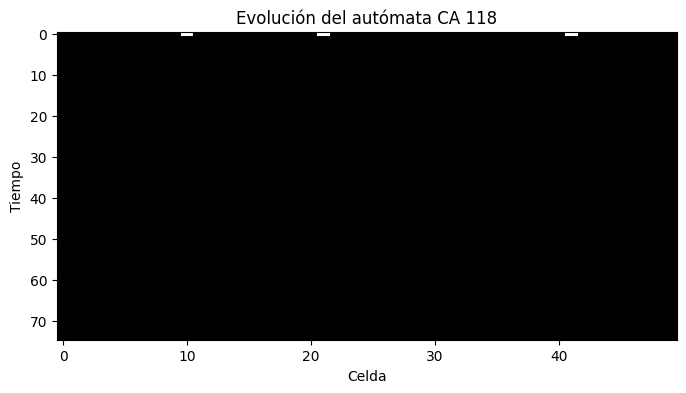

Estado uniforme final:  1


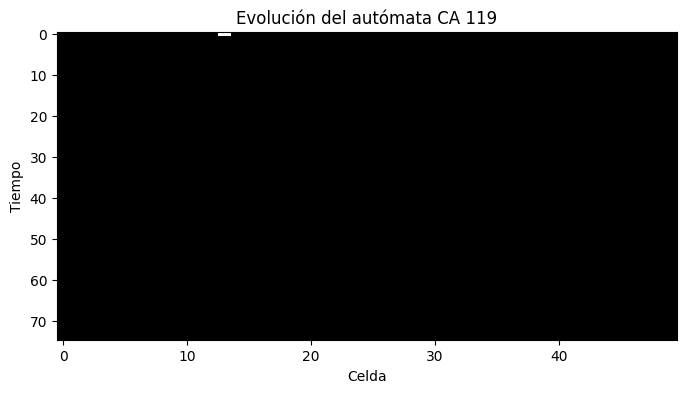

Estado uniforme final:  1


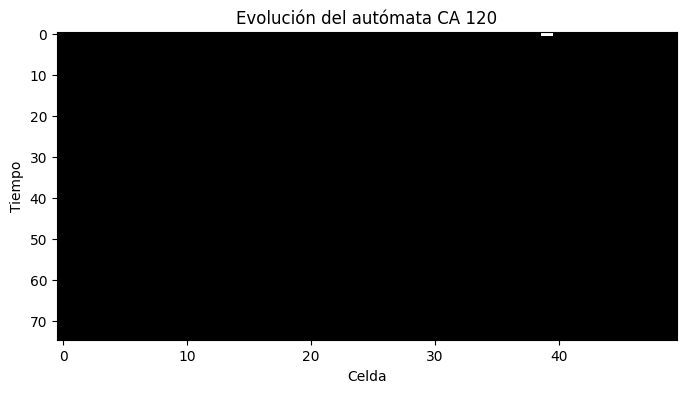

Estado uniforme final:  1


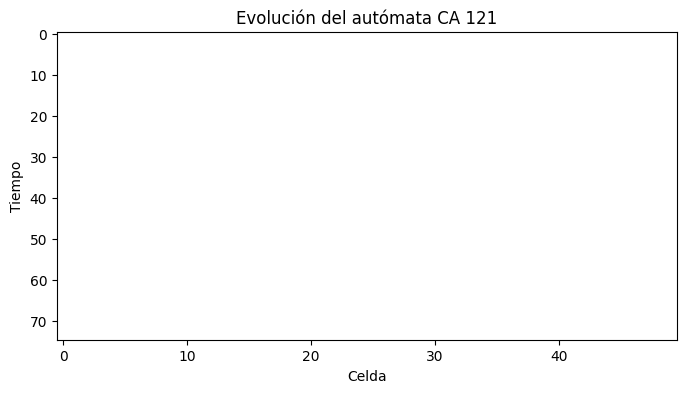

Estado uniforme final:  1


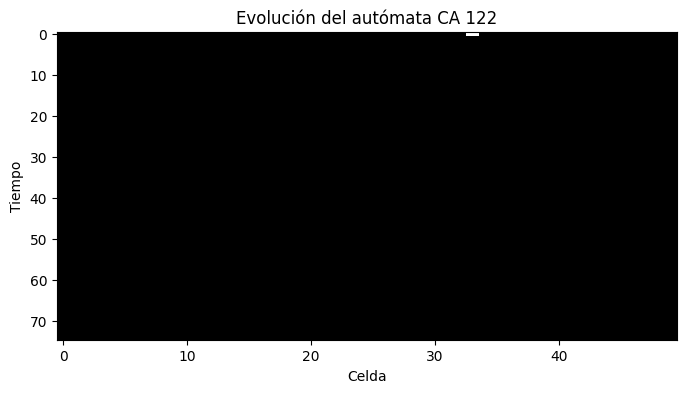

Estado uniforme final:  1


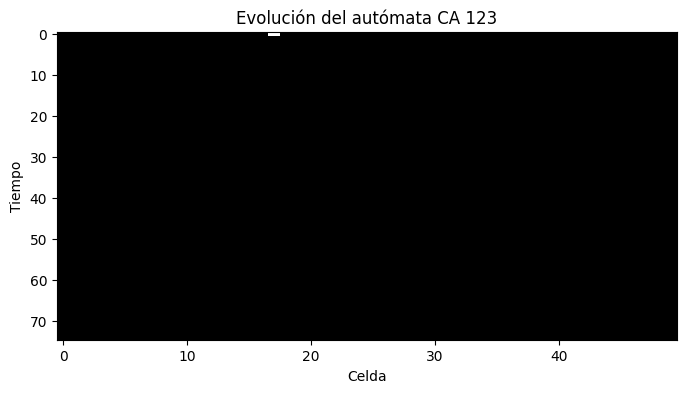

Estado uniforme final:  1


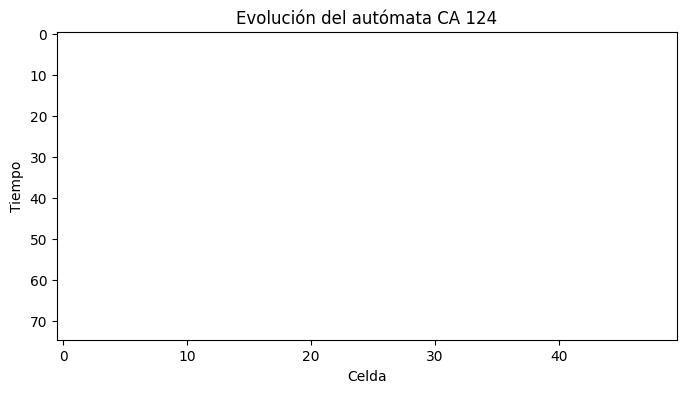

--- Catálogo de Reglas del AC (Índice -> Configuración -> Resultado) ---
Índice 000:   □□□□□□□   ->   □
Índice 001:   □□□□□□■   ->   □
Índice 002:   □□□□□■□   ->   □
Índice 003:   □□□□□■■   ->   □
Índice 004:   □□□□■□□   ->   □
Índice 005:   □□□□■□■   ->   □
Índice 006:   □□□□■■□   ->   ■
Índice 007:   □□□□■■■   ->   □
Índice 008:   □□□■□□□   ->   □
Índice 009:   □□□■□□■   ->   ■
Índice 010:   □□□■□■□   ->   □
Índice 011:   □□□■□■■   ->   □
Índice 012:   □□□■■□□   ->   □
Índice 013:   □□□■■□■   ->   ■
Índice 014:   □□□■■■□   ->   □
Índice 015:   □□□■■■■   ->   □
Índice 016:   □□■□□□□   ->   □
Índice 017:   □□■□□□■   ->   □
Índice 018:   □□■□□■□   ->   ■
Índice 019:   □□■□□■■   ->   ■
Índice 020:   □□■□■□□   ->   □
Índice 021:   □□■□■□■   ->   ■
Índice 022:   □□■□■■□   ->   ■
Índice 023:   □□■□■■■   ->   ■
Índice 024:   □□■■□□□   ->   ■
Índice 025:   □□■■□□■   ->   ■
Índice 026:   □□■■□■□   ->   □
Índice 027:   □□■■□■■   ->   ■
Índice 028:   □□■■■□□   ->   □
Índice 029:   □□■■■□■   ->  

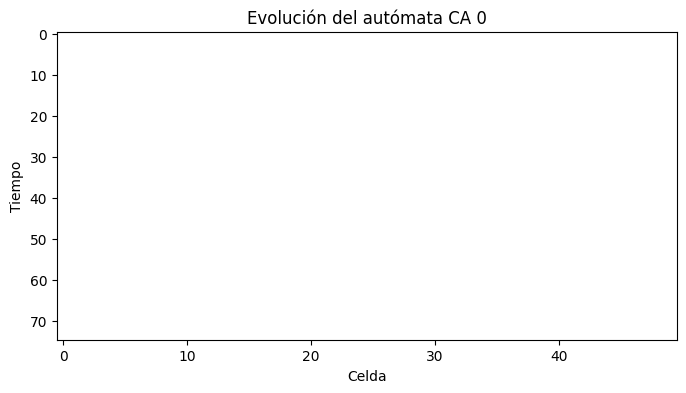

Estado uniforme final:  0


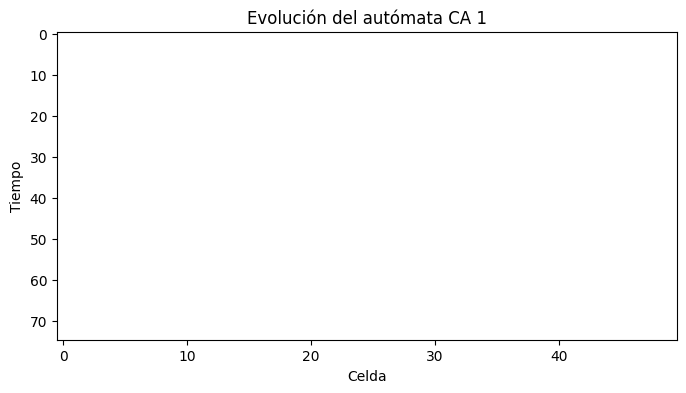

Estado uniforme final:  0


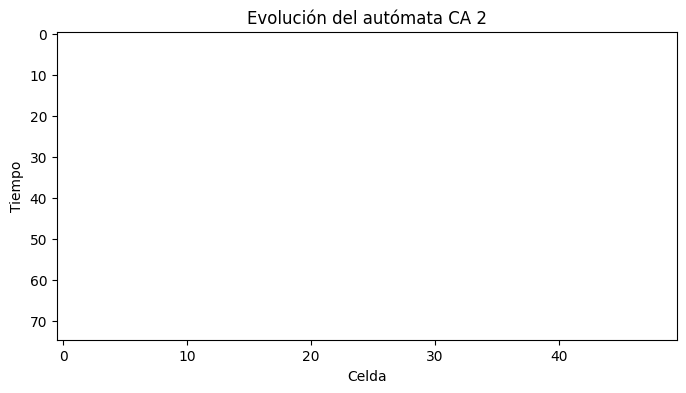

Estado uniforme final:  0


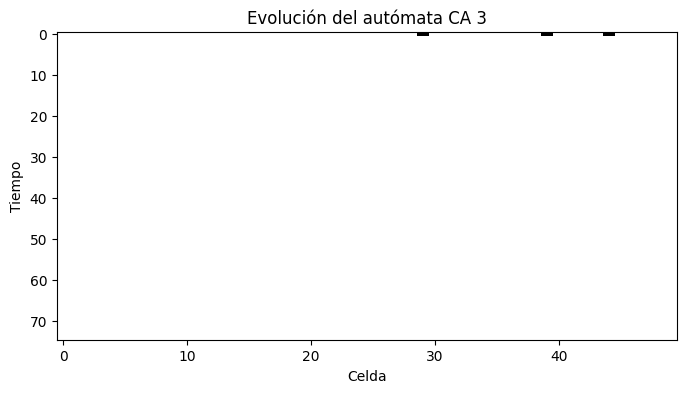

Estado uniforme final:  0


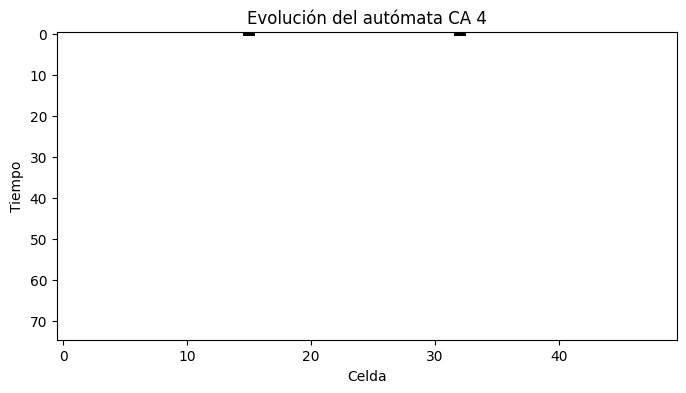

Estado uniforme final:  0


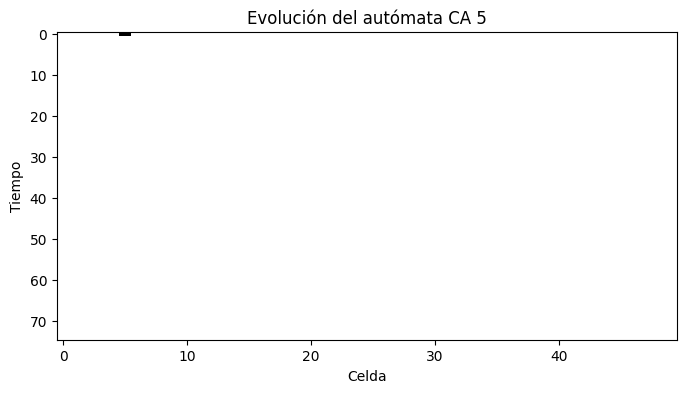

Estado uniforme final:  0


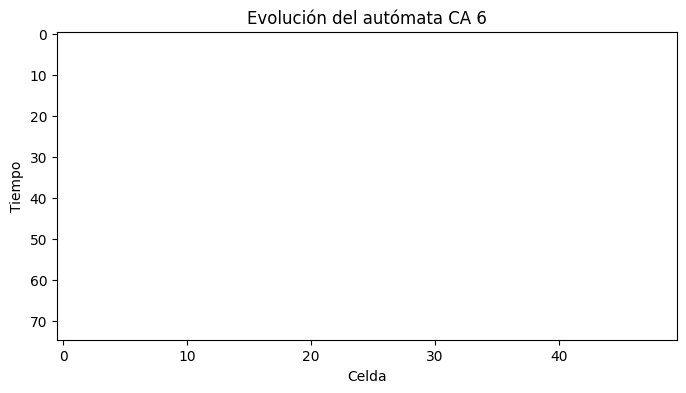

Estado uniforme final:  0


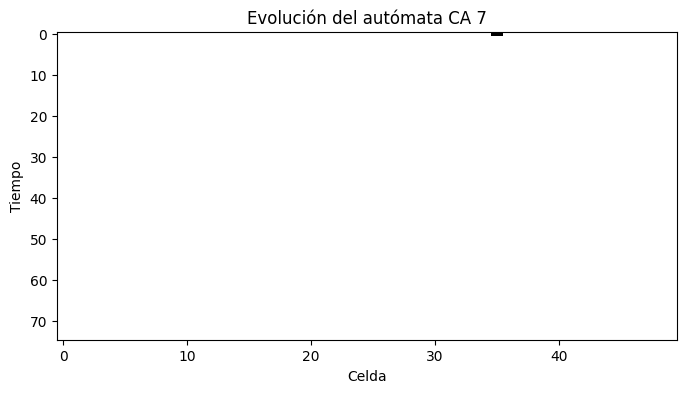

Estado uniforme final:  0


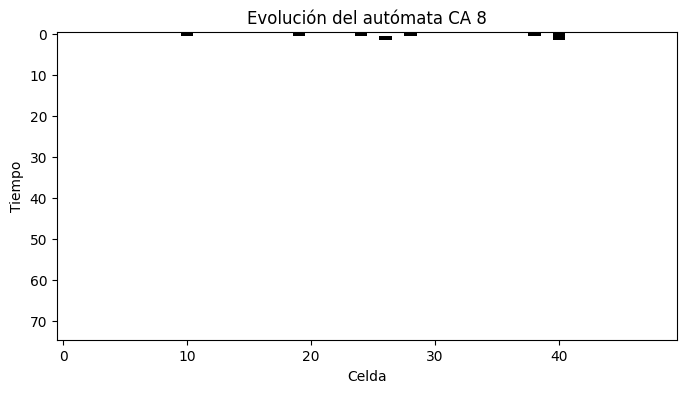

Estado uniforme final:  0


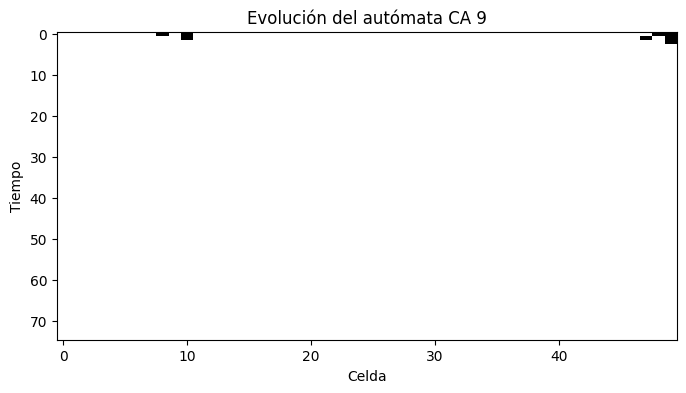

Estado uniforme final:  0


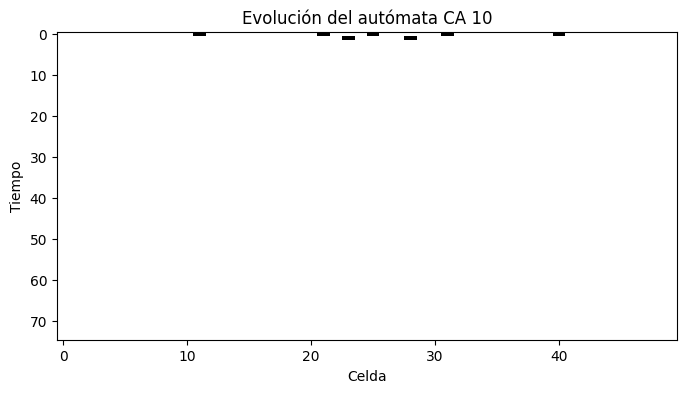

Estado uniforme final:  0


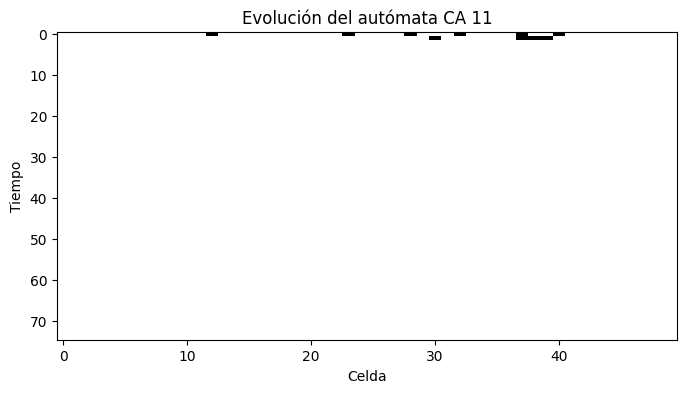

Estado uniforme final:  0


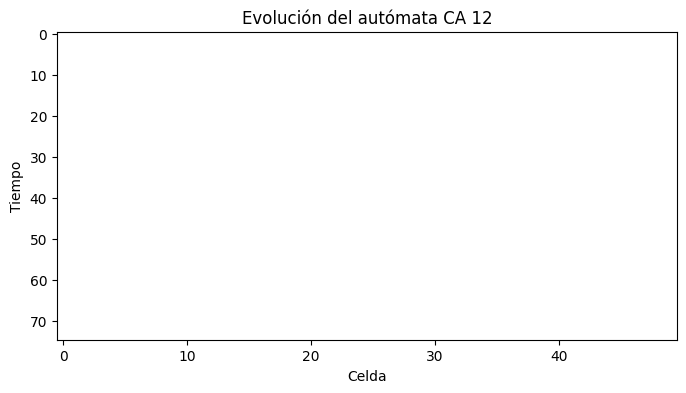

Estado uniforme final:  0


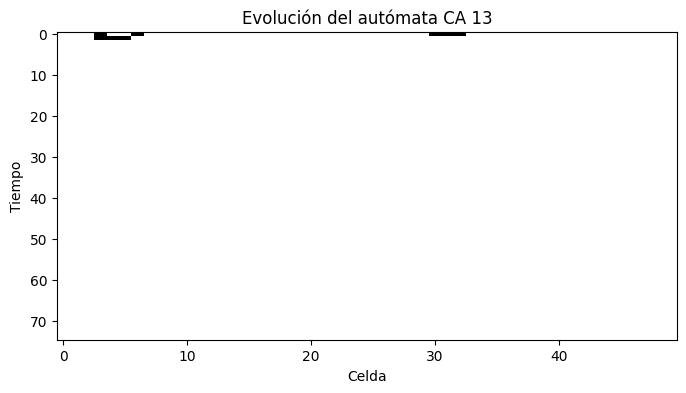

Estado uniforme final:  0


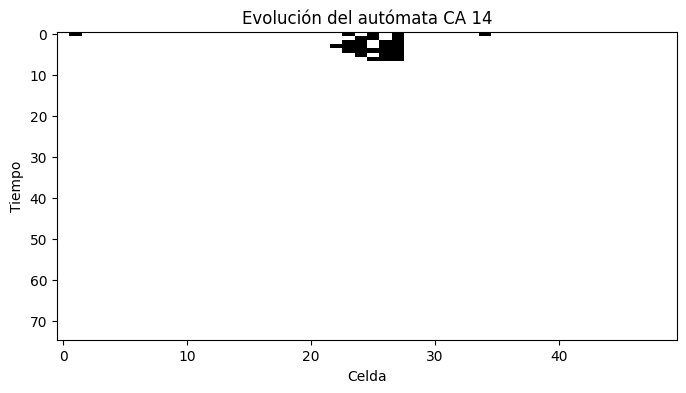

Estado uniforme final:  0


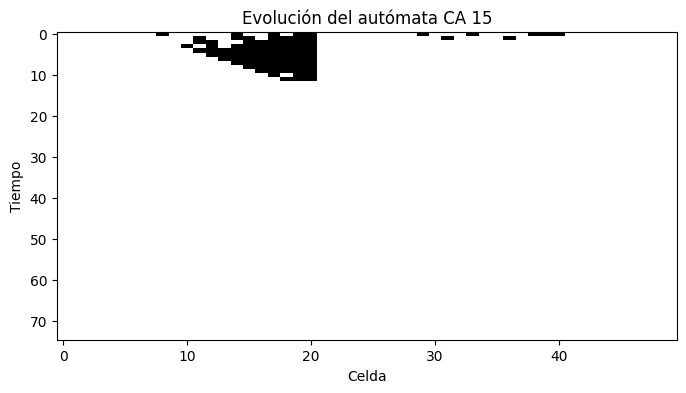

Estado uniforme final:  0


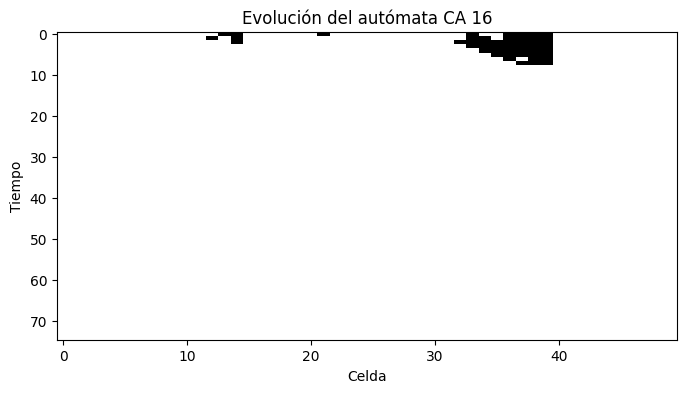

Estado uniforme final:  0


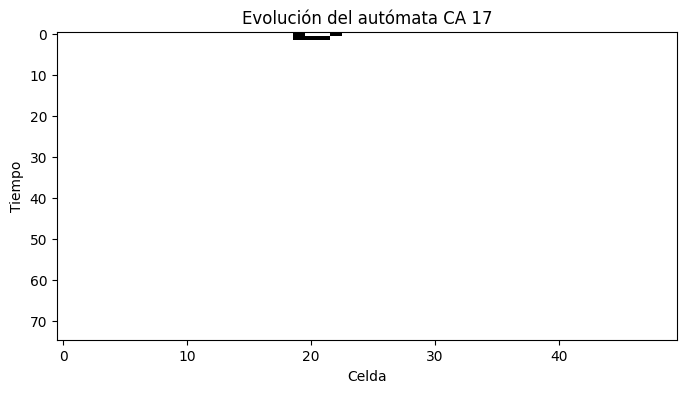

Estado uniforme final:  0


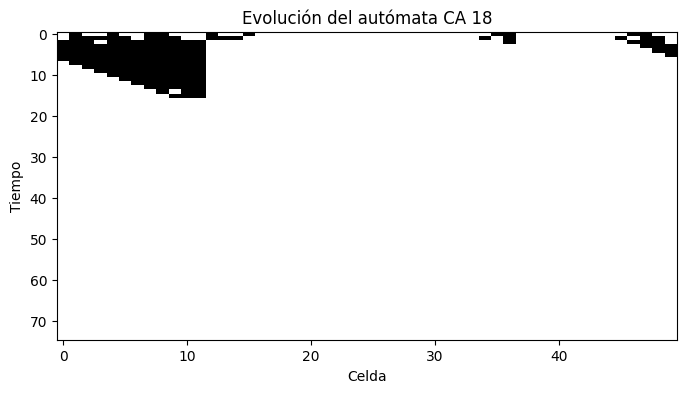

Estado uniforme final:  0


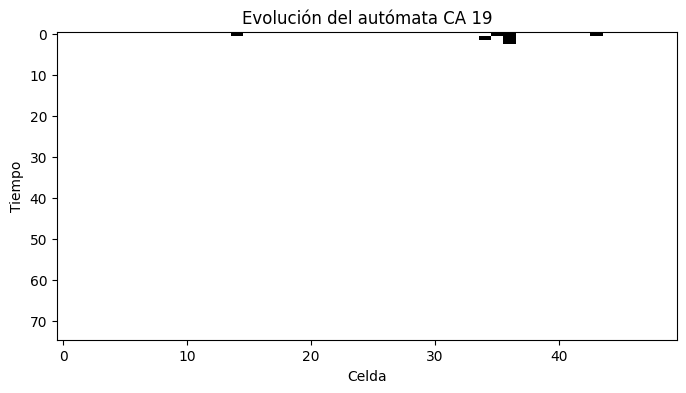

Estado uniforme final:  0


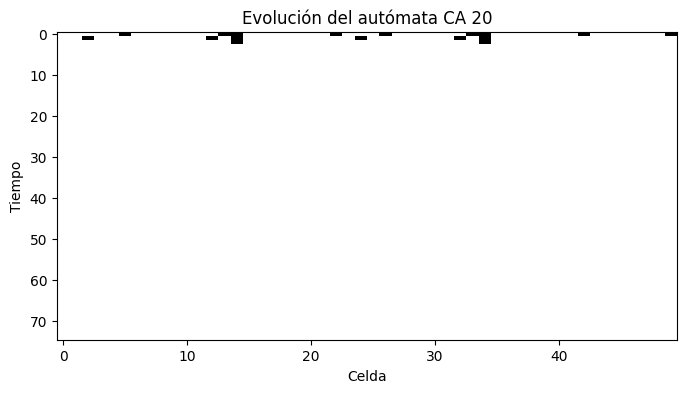

Estado uniforme final:  0


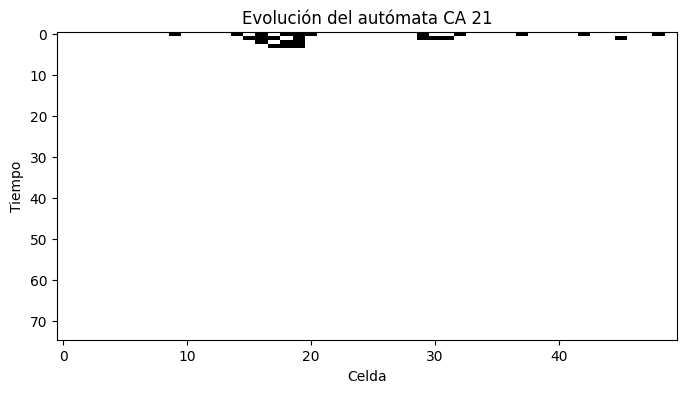

Estado uniforme final:  0


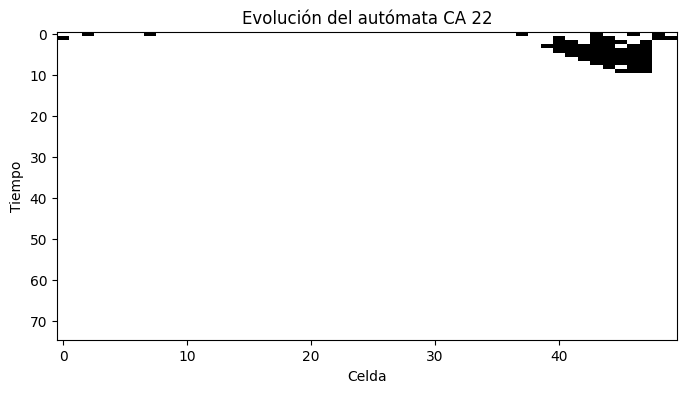

Estado uniforme final:  0


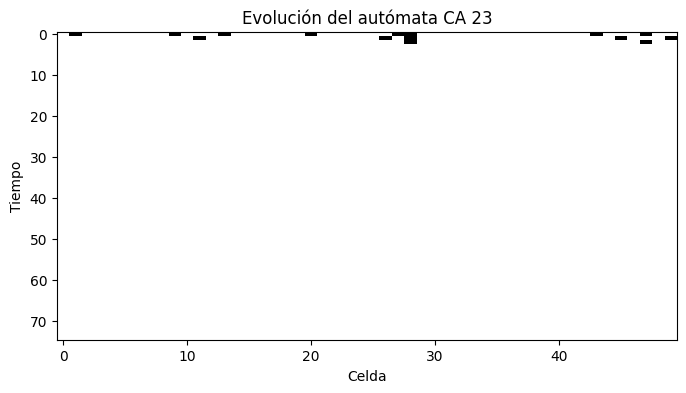

Estado uniforme final:  0


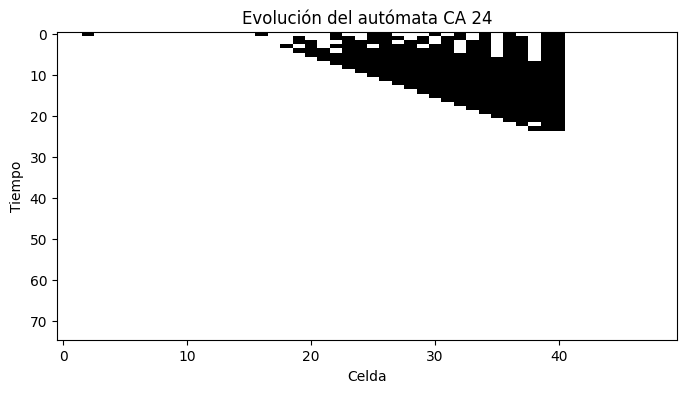

Estado uniforme final:  0


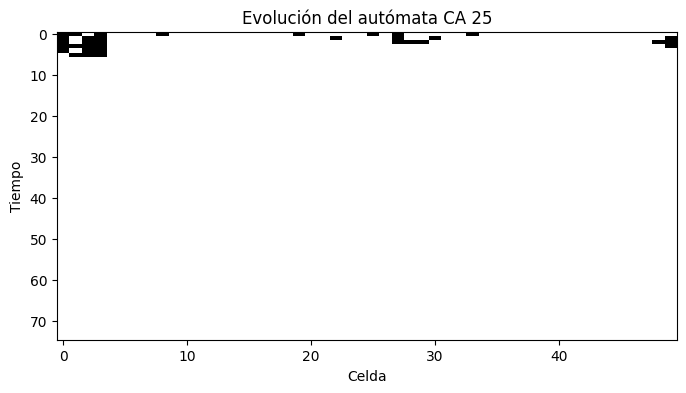

Estado uniforme final:  0


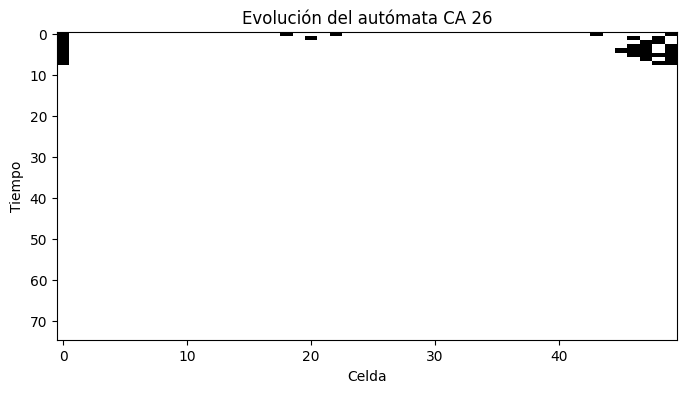

Estado uniforme final:  0


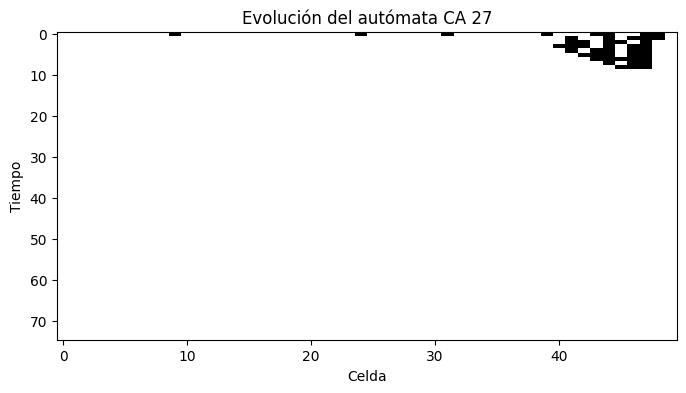

Estado uniforme final:  0


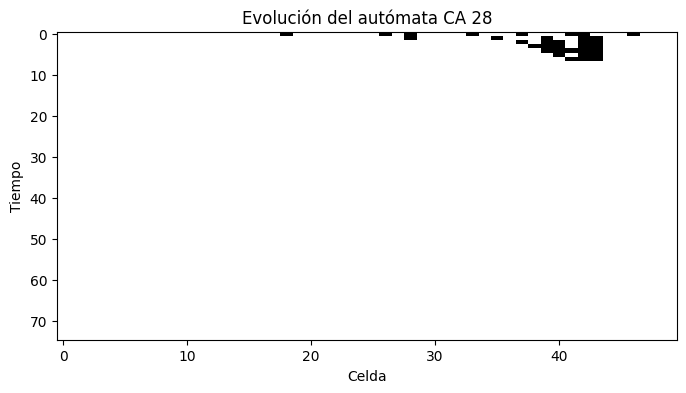

Estado uniforme final:  0


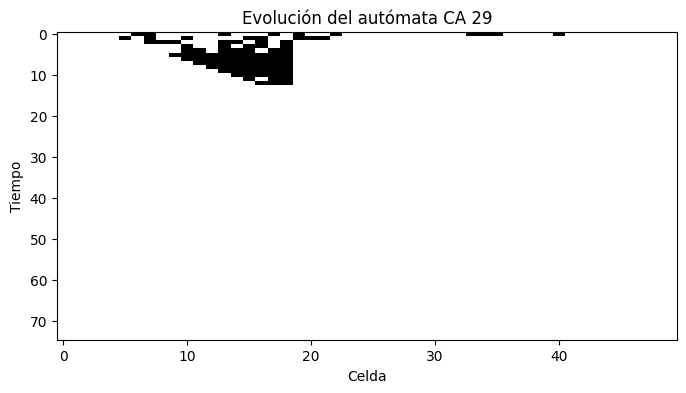

Estado uniforme final:  0


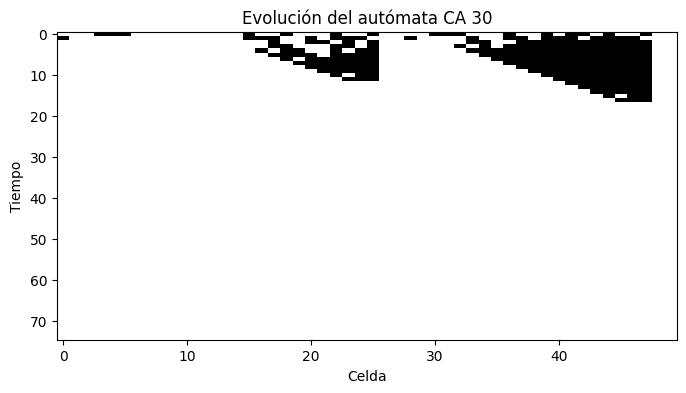

Estado uniforme final:  0


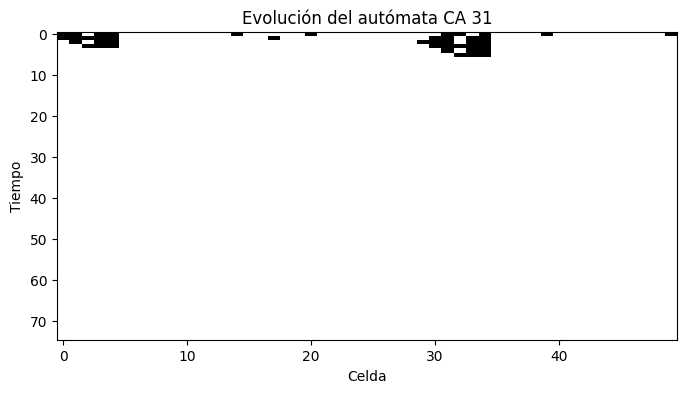

Estado uniforme final:  0


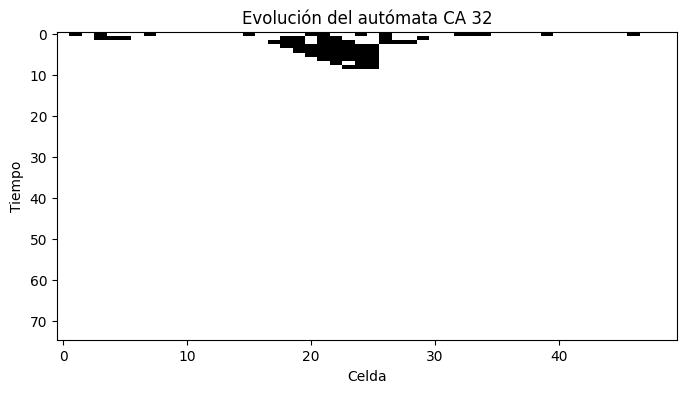

Estado uniforme final:  0


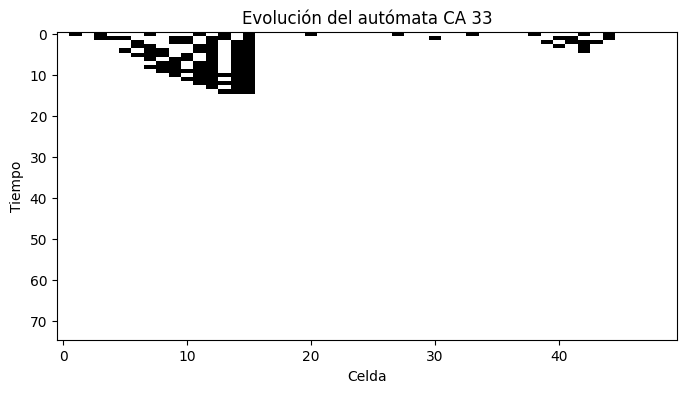

Estado uniforme final:  0


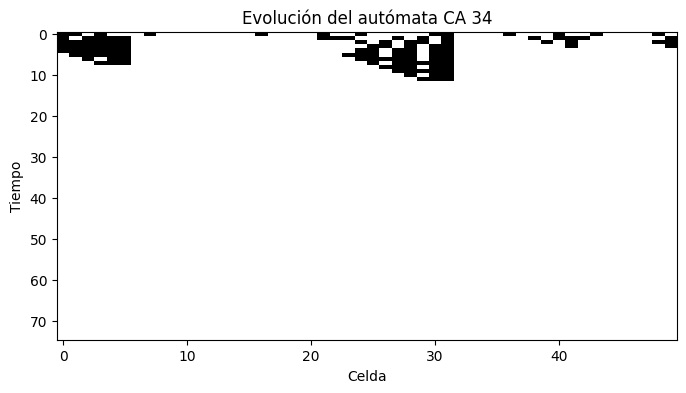

Estado uniforme final:  0


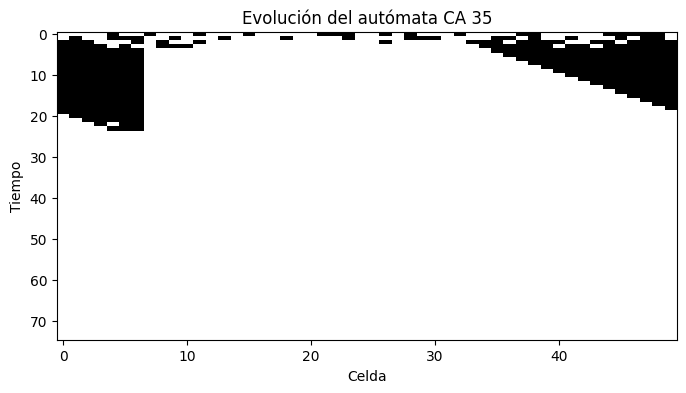

Estado uniforme final:  0


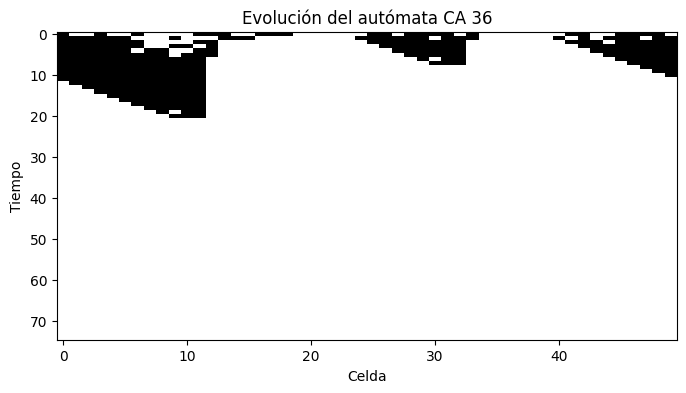

Estado uniforme final:  0


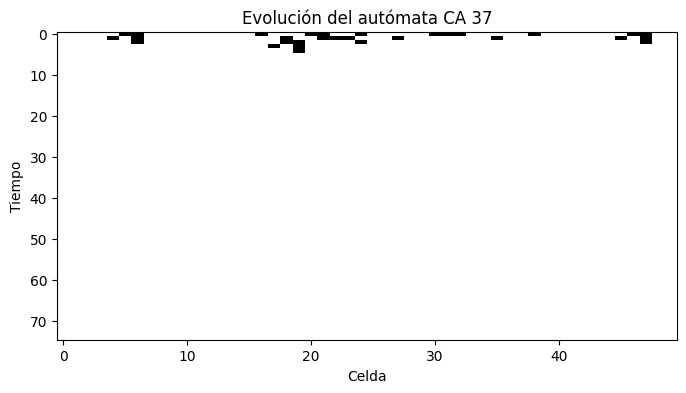

Estado uniforme final:  0


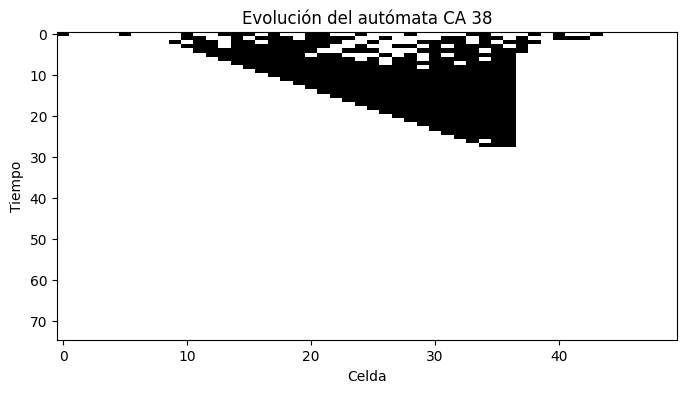

Estado uniforme final:  0


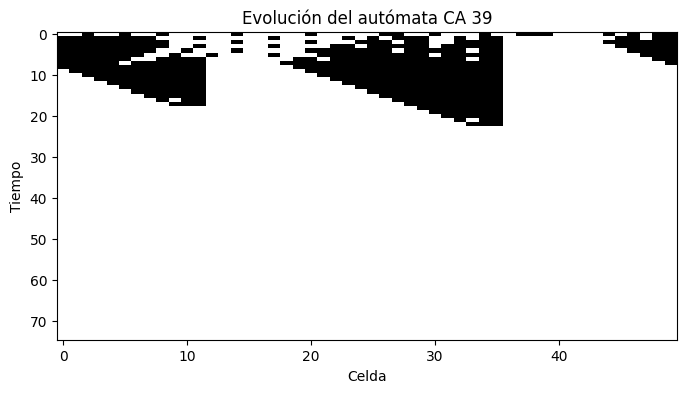

Estado uniforme final:  0


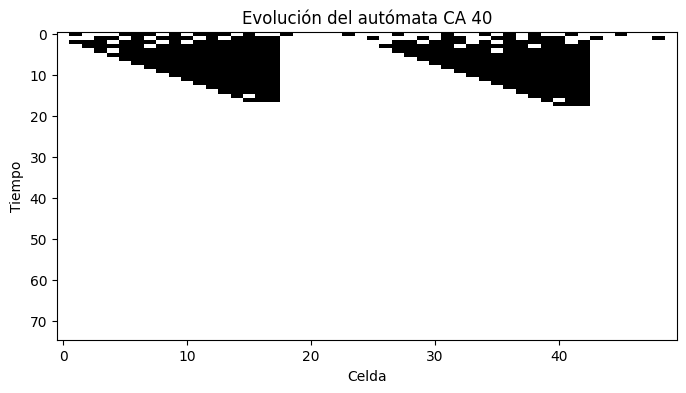

Estado uniforme final:  0


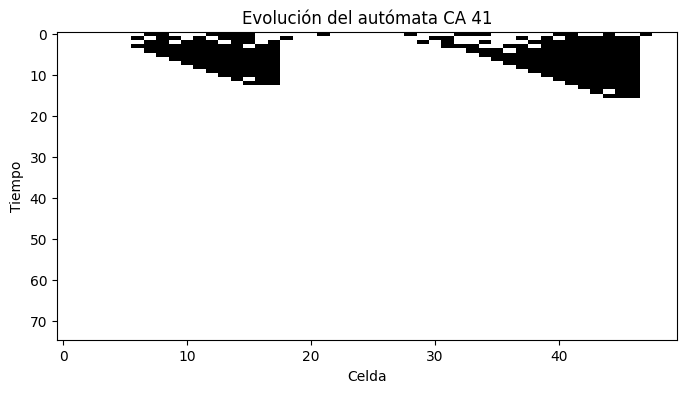

Estado uniforme final:  0


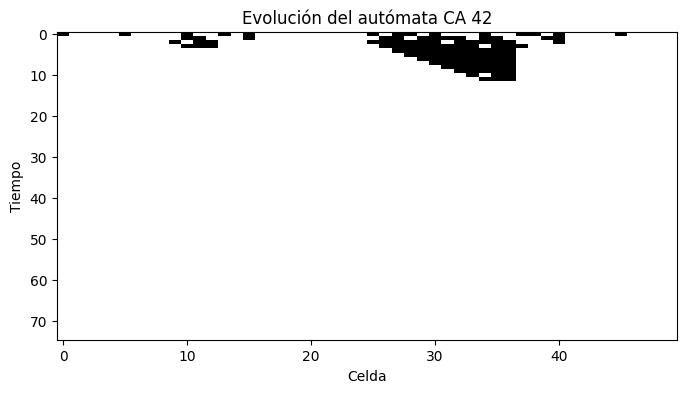

Estado uniforme final:  0


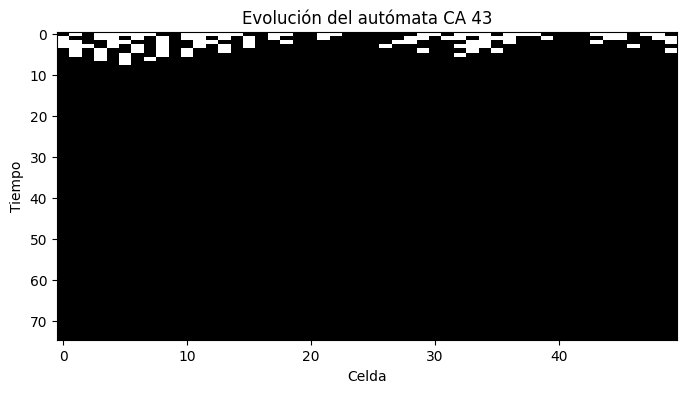

Estado uniforme final:  0


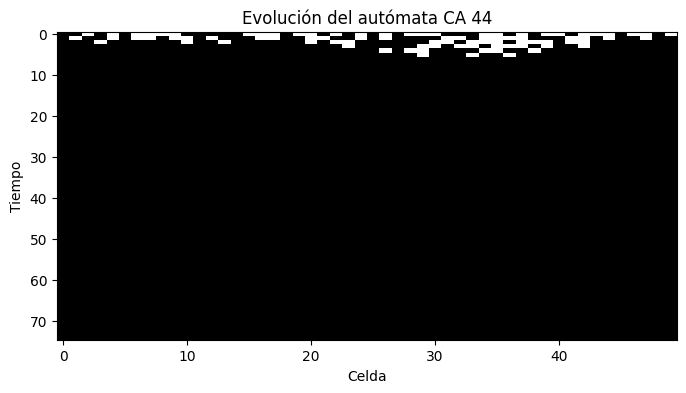

Estado uniforme final:  0


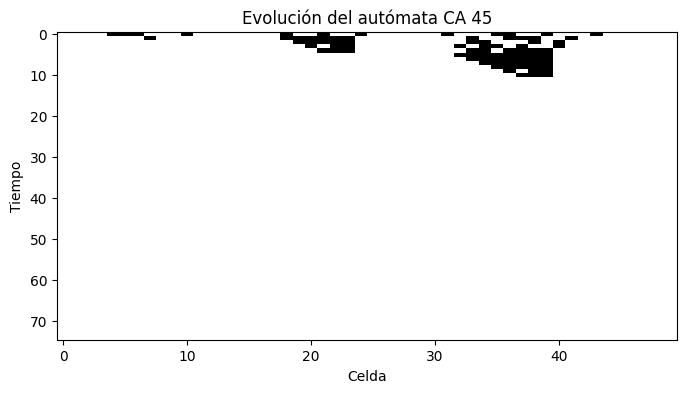

Estado uniforme final:  0


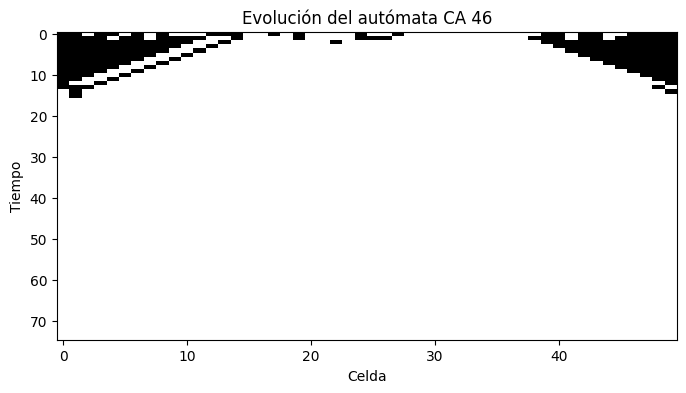

Estado uniforme final:  0


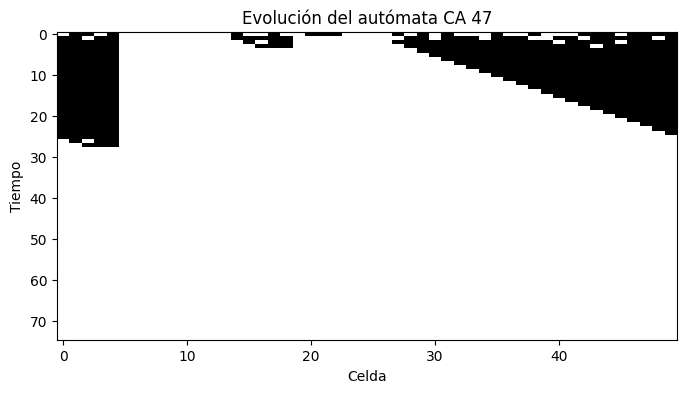

Estado uniforme final:  0


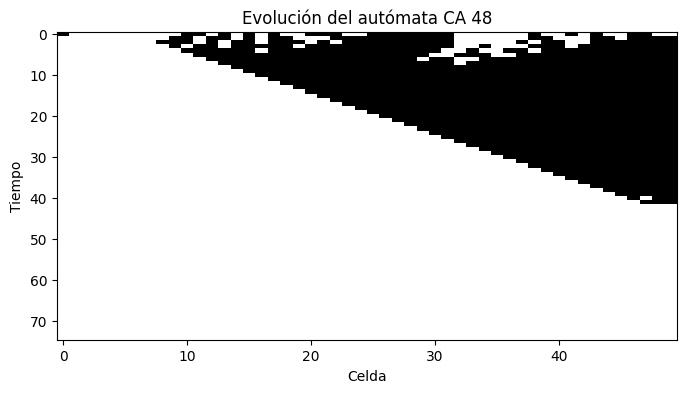

Estado uniforme final:  0


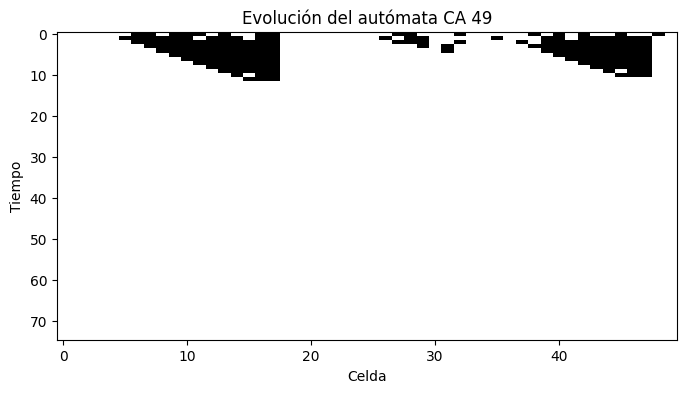

Estado uniforme final:  0


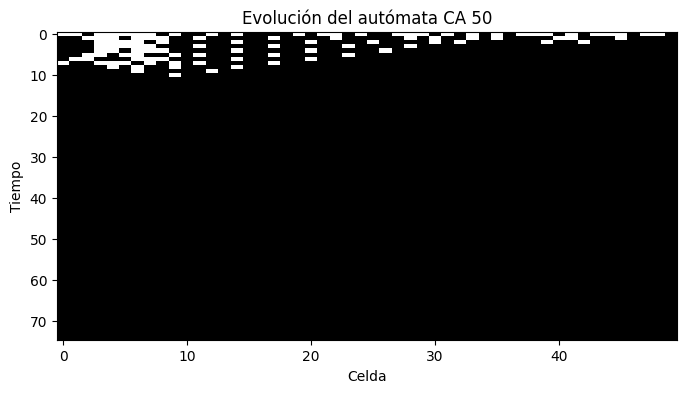

Estado uniforme final:  0


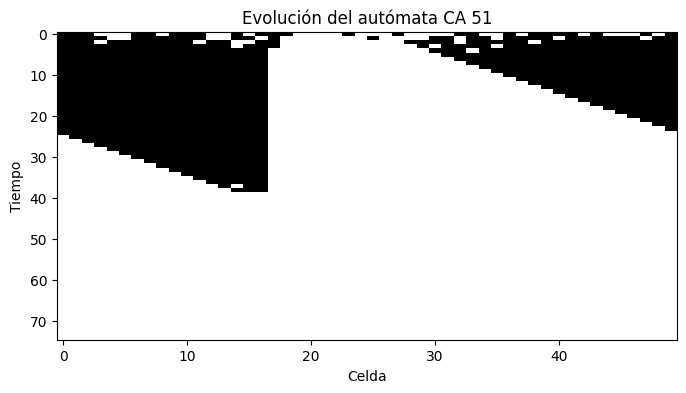

Estado uniforme final:  0


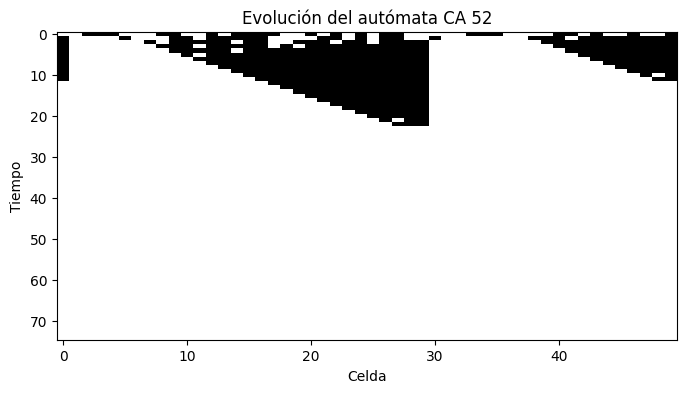

Estado uniforme final:  0


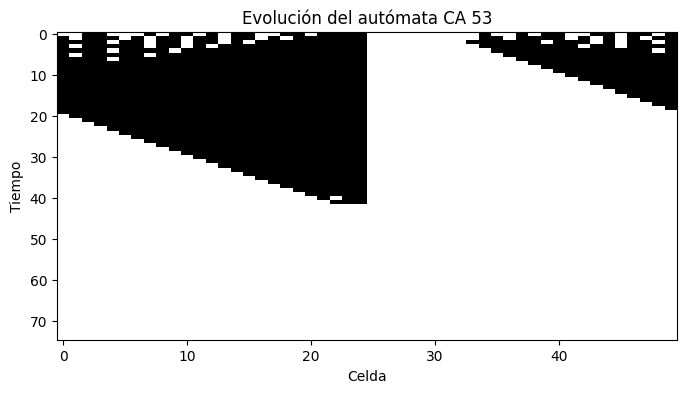

Estado uniforme final:  1


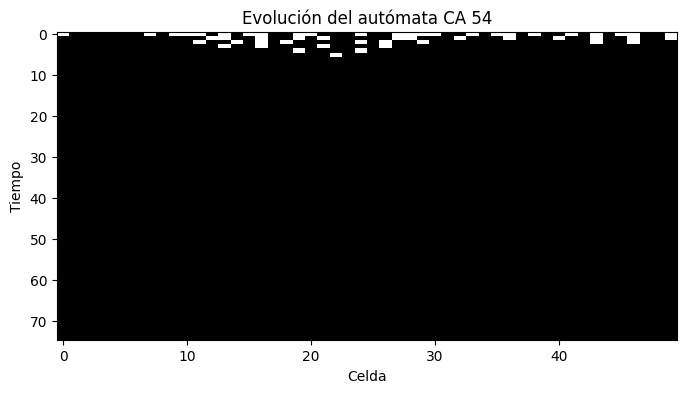

Estado uniforme final:  0


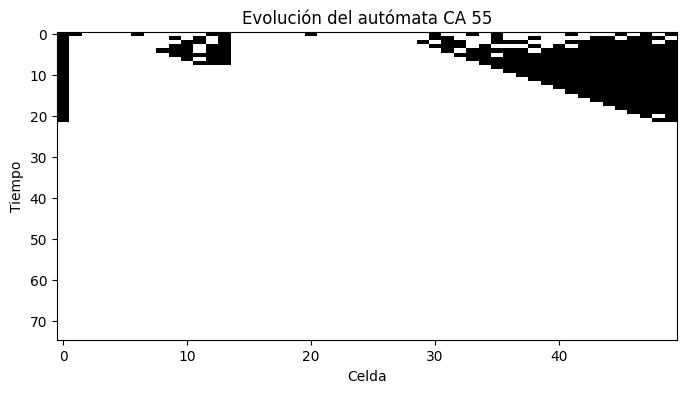

Estado uniforme final:  0


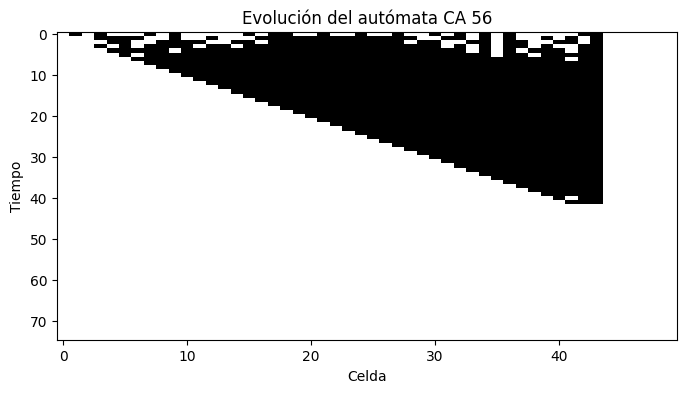

Estado uniforme final:  0


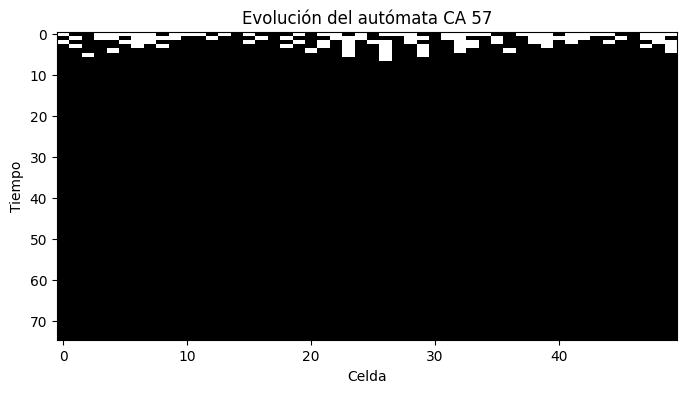

Estado uniforme final:  1


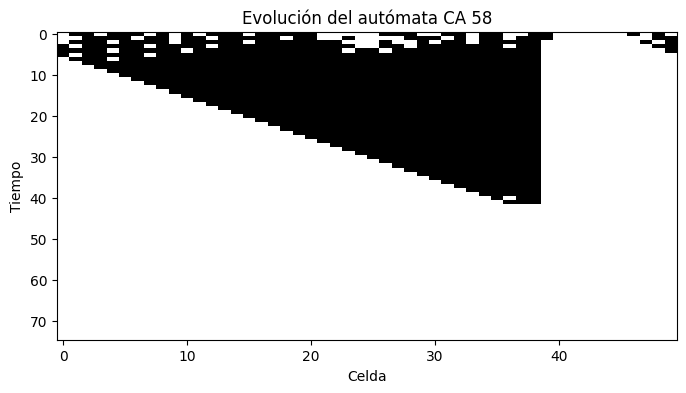

Estado uniforme final:  1


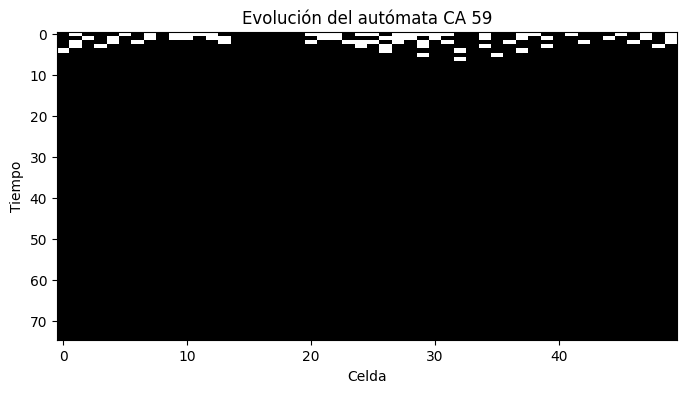

Estado uniforme final:  0


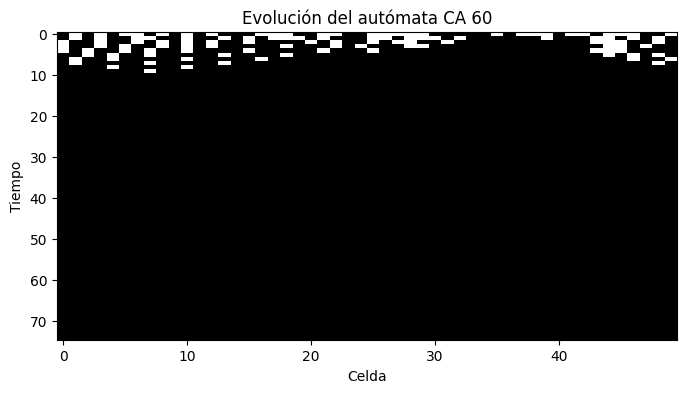

Estado uniforme final:  1


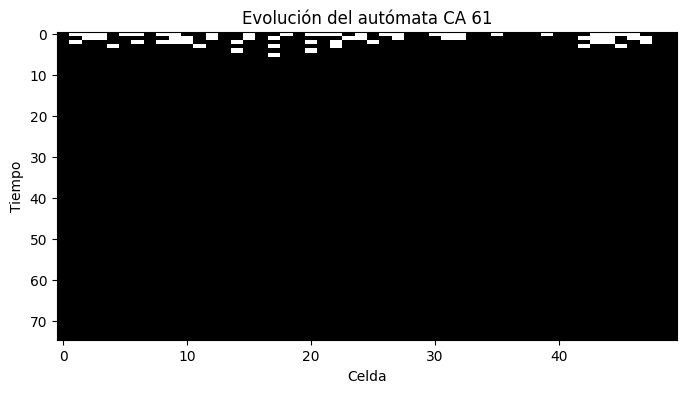

Estado uniforme final:  1


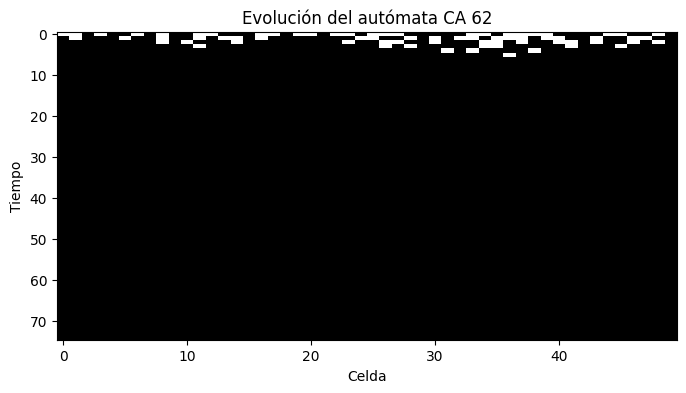

Estado uniforme final:  0


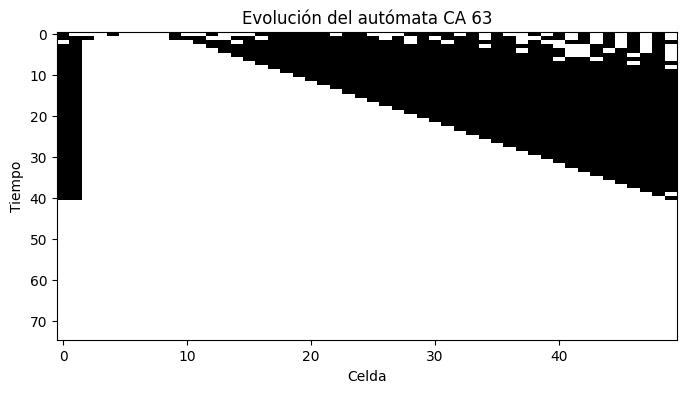

Estado uniforme final:  1


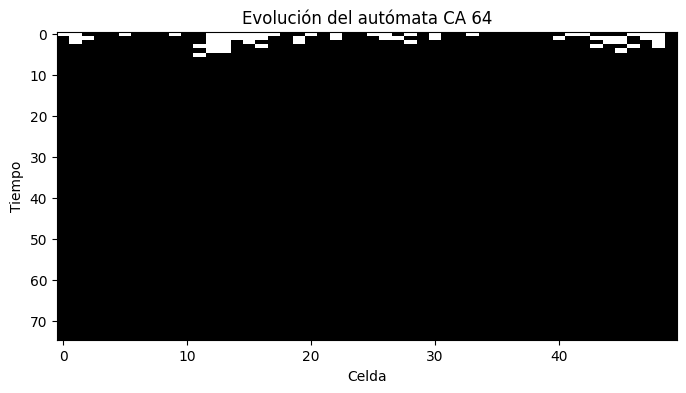

Estado uniforme final:  0


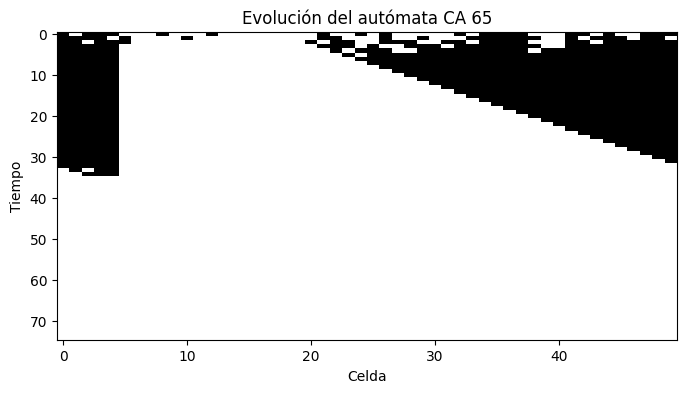

Estado uniforme final:  1


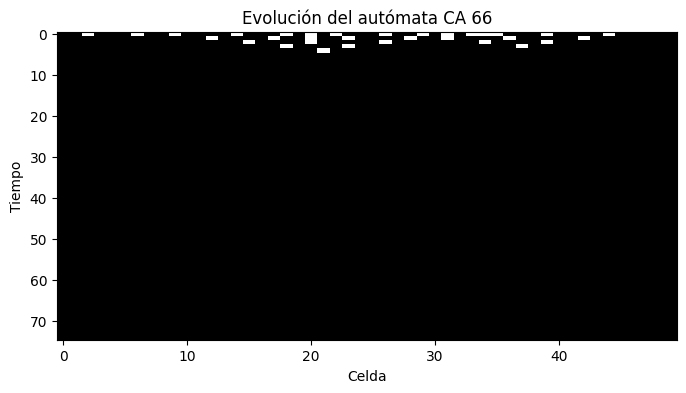

Estado uniforme final:  1


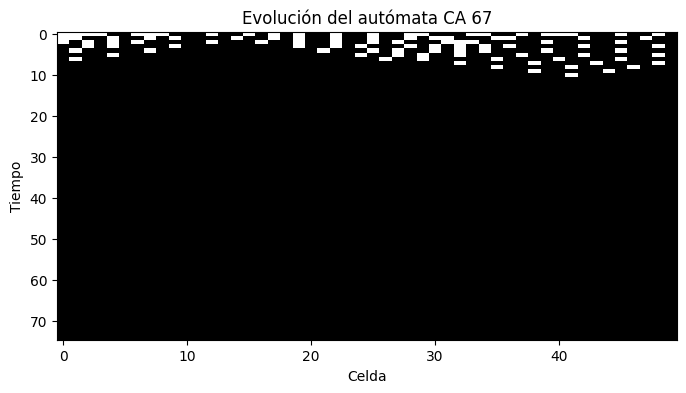

Estado uniforme final:  0


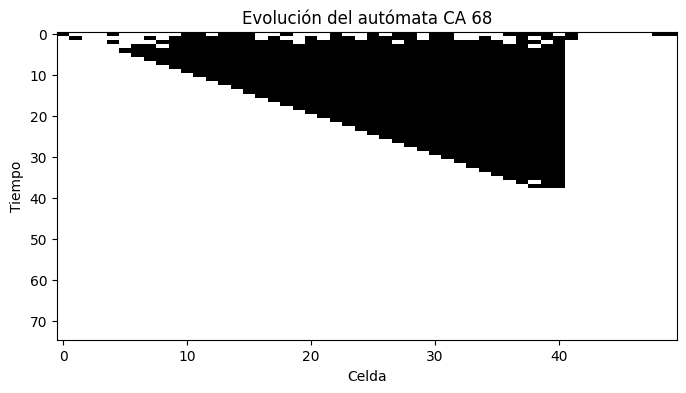

Estado uniforme final:  0


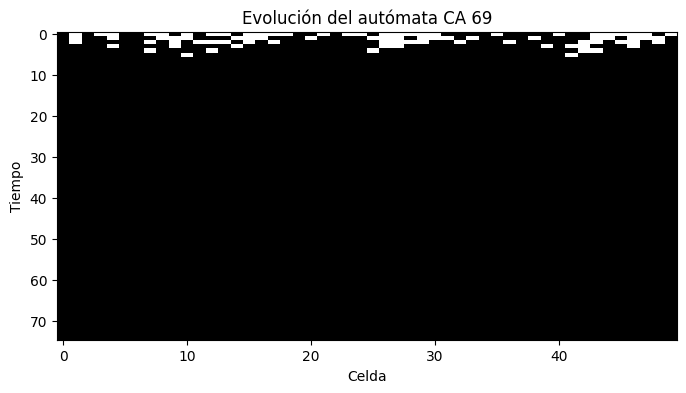

Estado uniforme final:  1


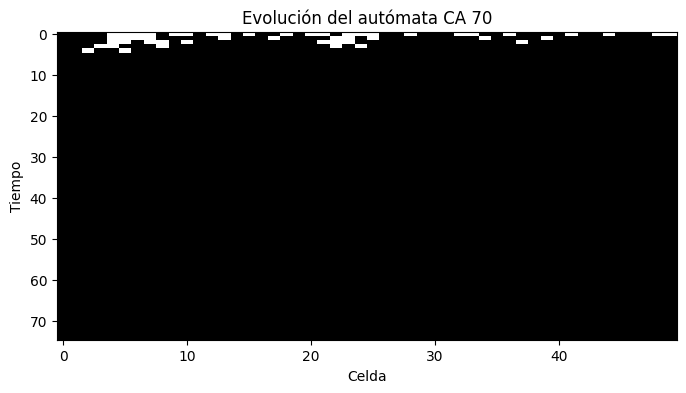

Estado uniforme final:  1


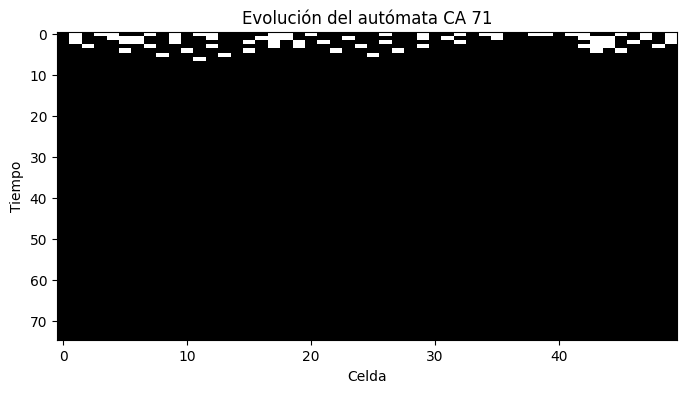

Estado uniforme final:  1


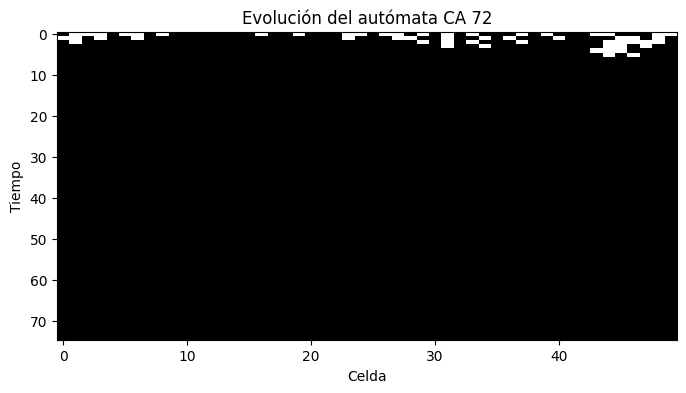

Estado uniforme final:  1


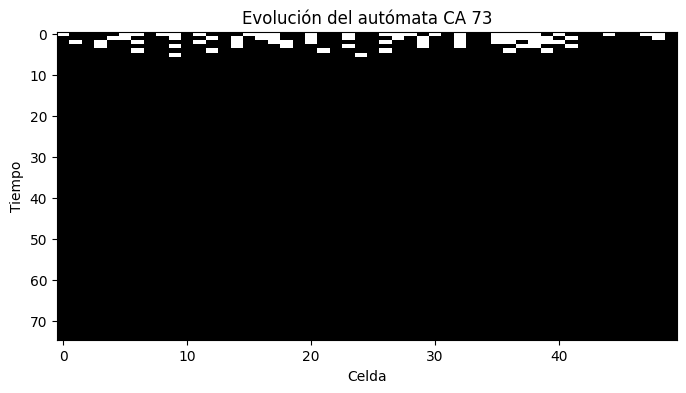

Estado uniforme final:  1


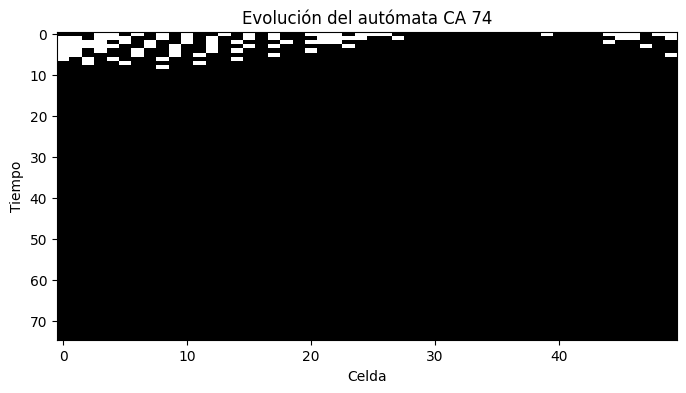

Estado uniforme final:  1


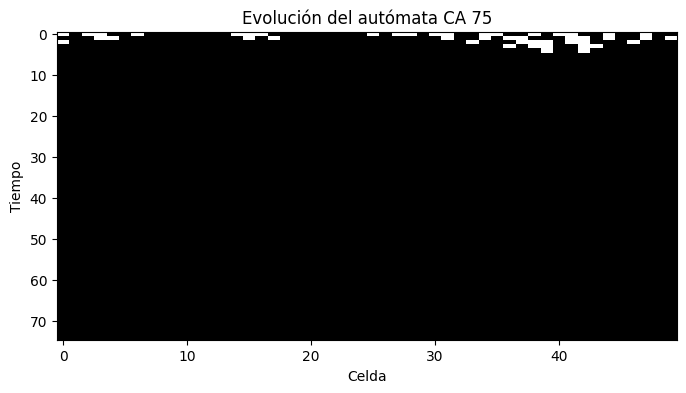

Estado uniforme final:  0


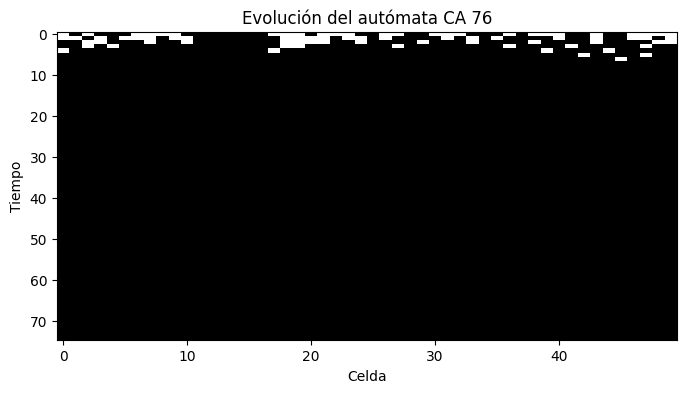

Estado uniforme final:  1


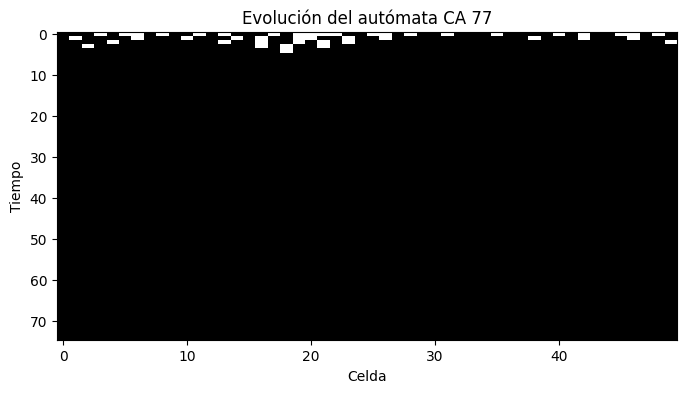

Estado uniforme final:  1


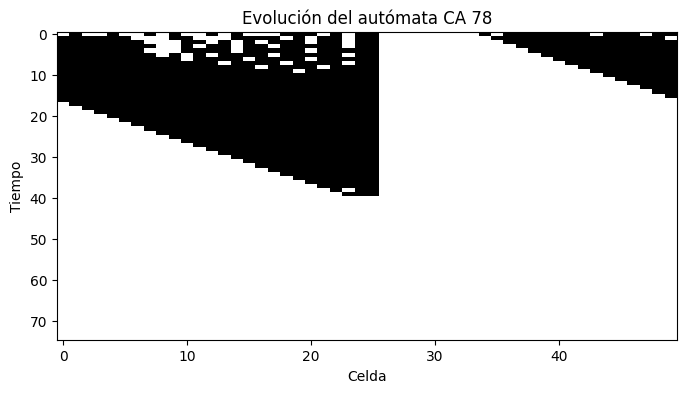

Estado uniforme final:  1


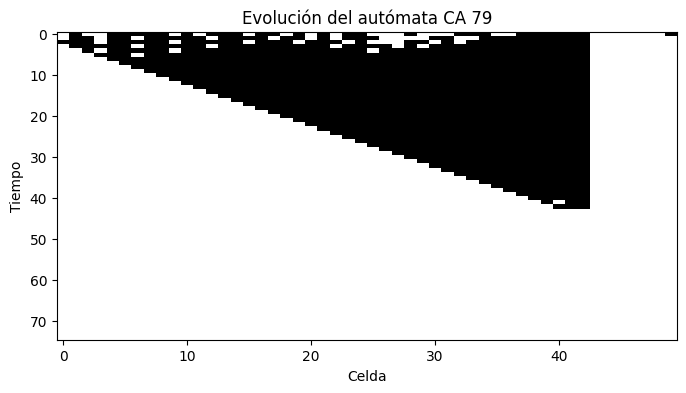

Estado uniforme final:  1


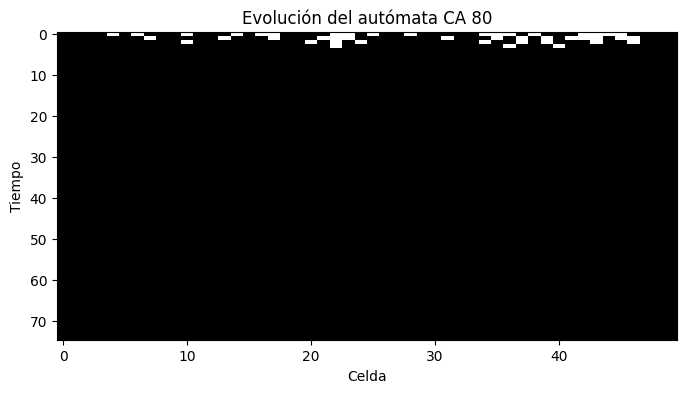

Estado uniforme final:  1


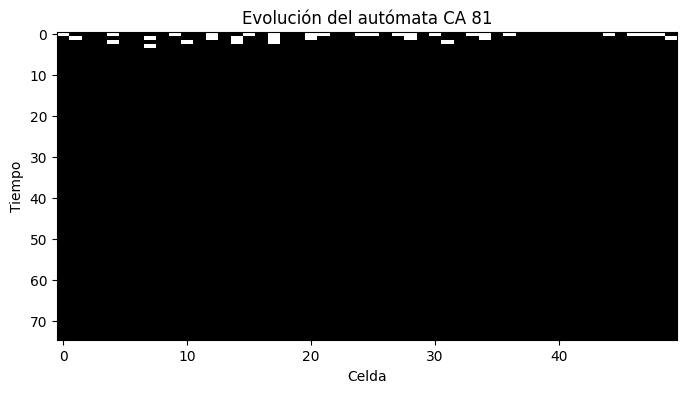

Estado uniforme final:  1


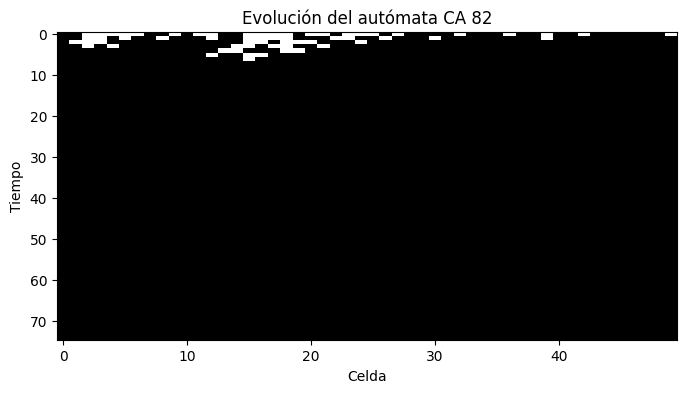

Estado uniforme final:  1


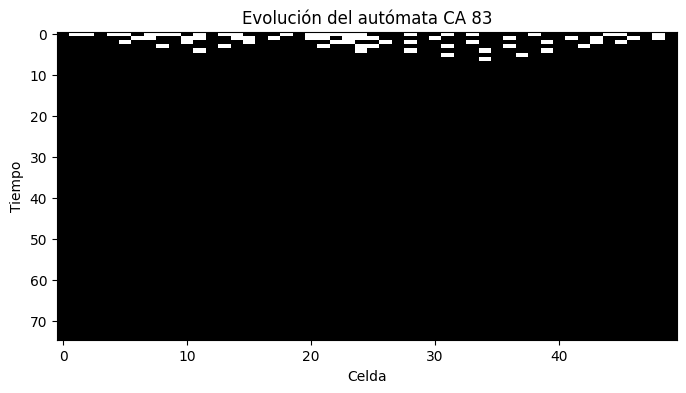

Estado uniforme final:  1


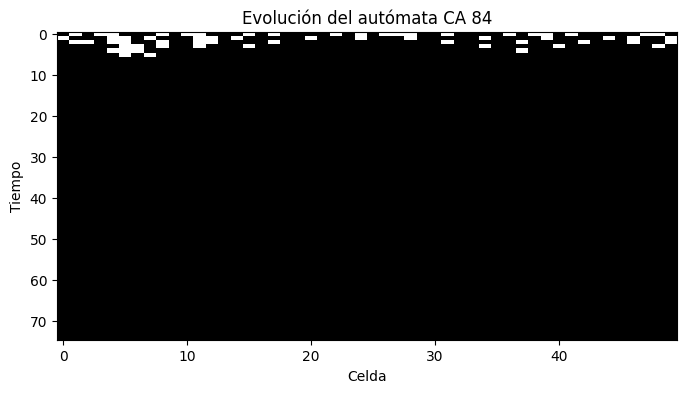

Estado uniforme final:  1


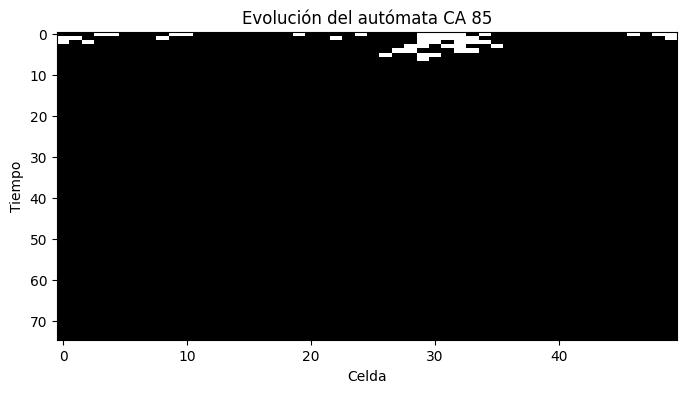

Estado uniforme final:  1


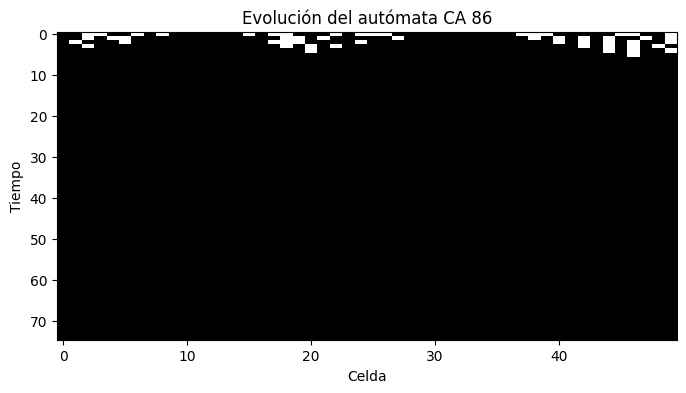

Estado uniforme final:  1


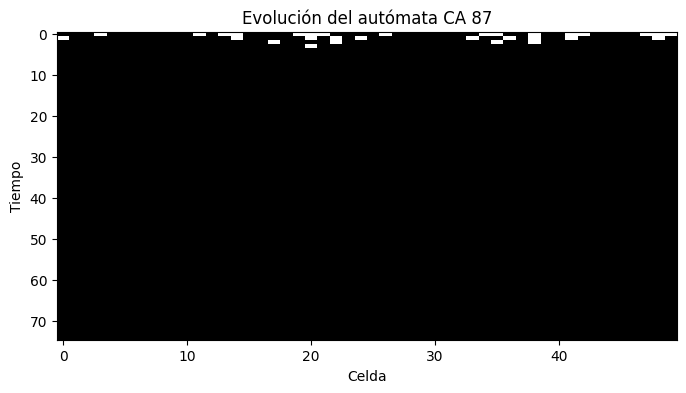

Estado uniforme final:  1


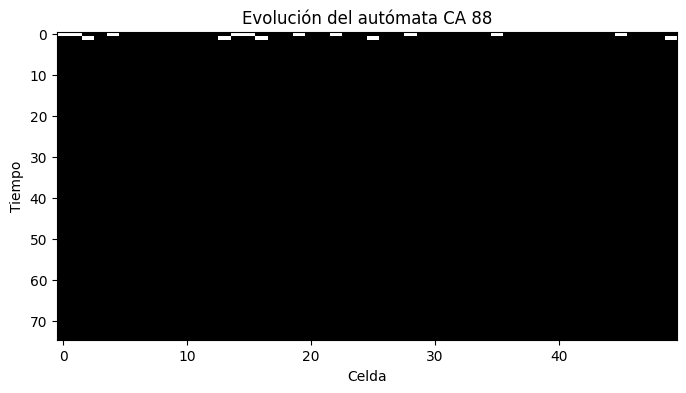

Estado uniforme final:  1


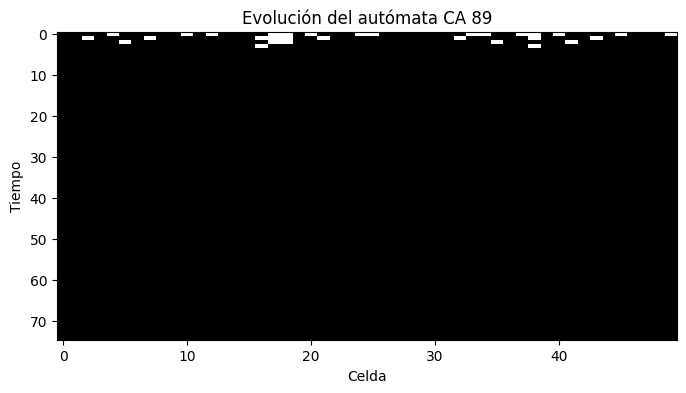

Estado uniforme final:  1


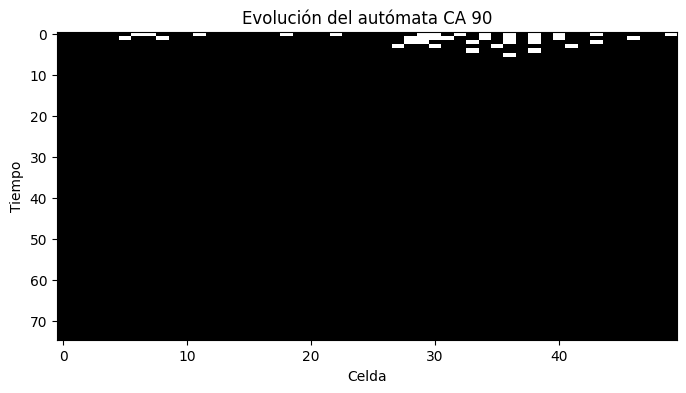

Estado uniforme final:  1


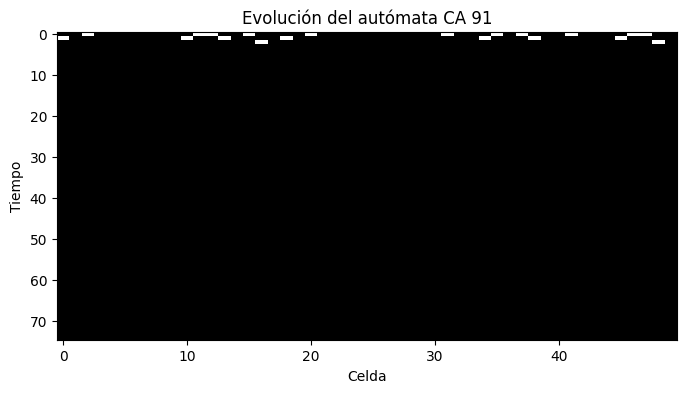

Estado uniforme final:  1


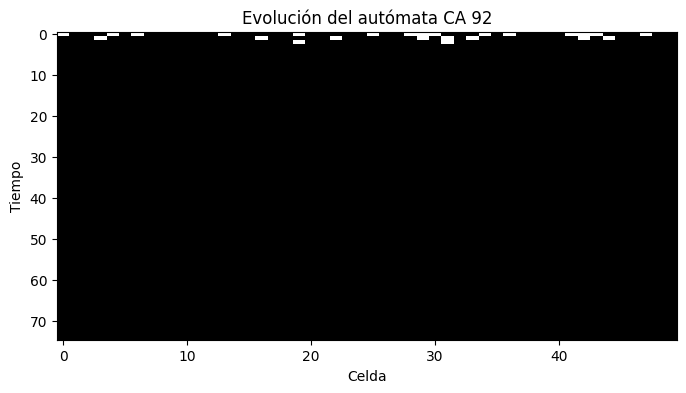

Estado uniforme final:  1


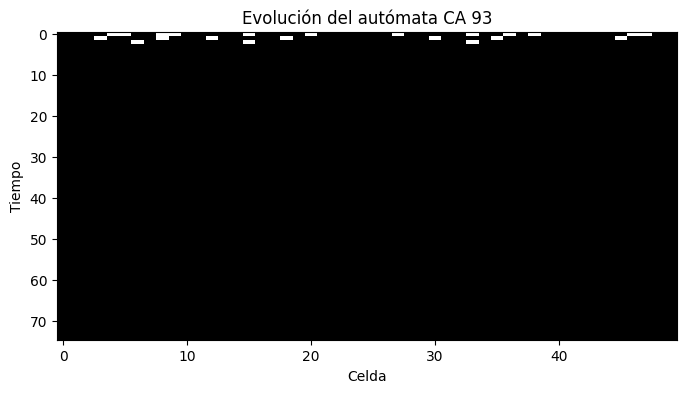

Estado uniforme final:  1


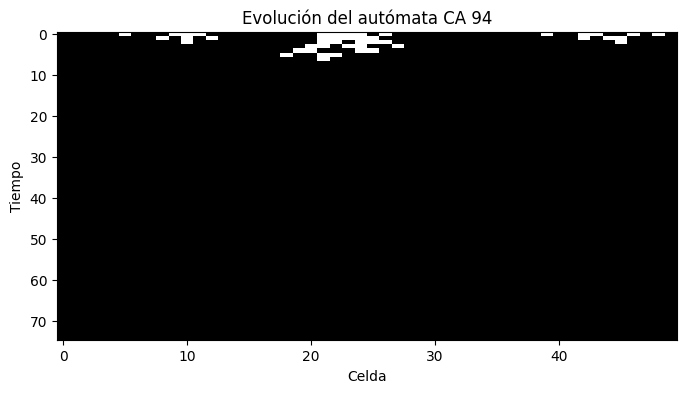

Estado uniforme final:  1


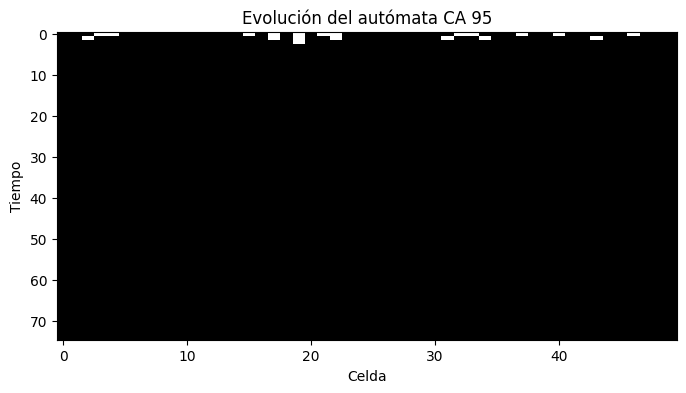

Estado uniforme final:  1


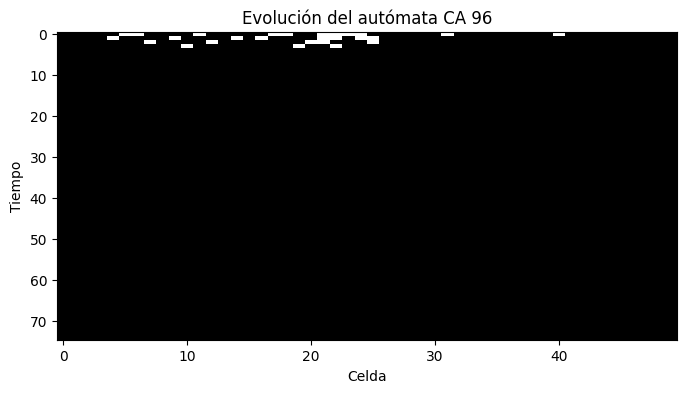

Estado uniforme final:  1


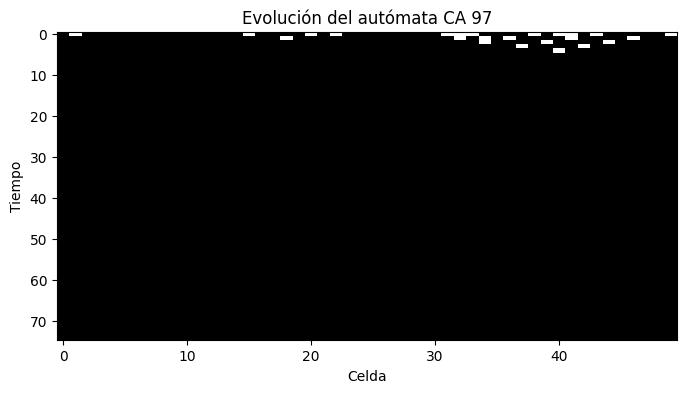

Estado uniforme final:  1


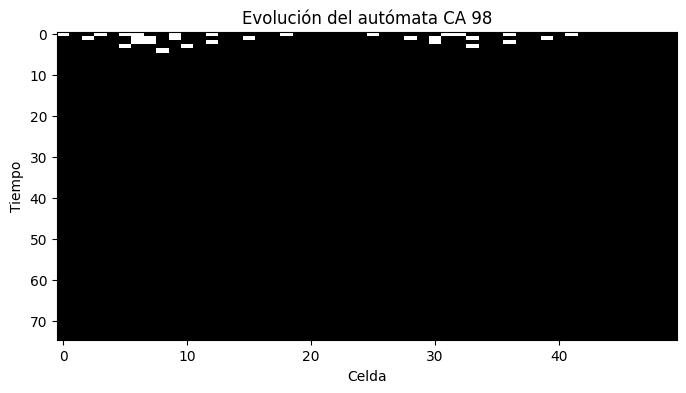

Estado uniforme final:  1


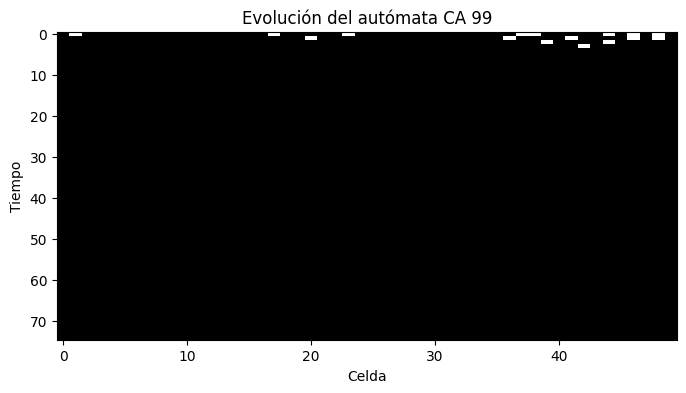

Estado uniforme final:  1


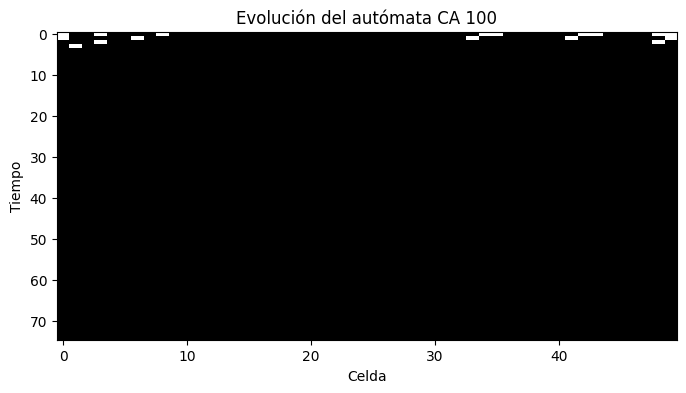

Estado uniforme final:  1


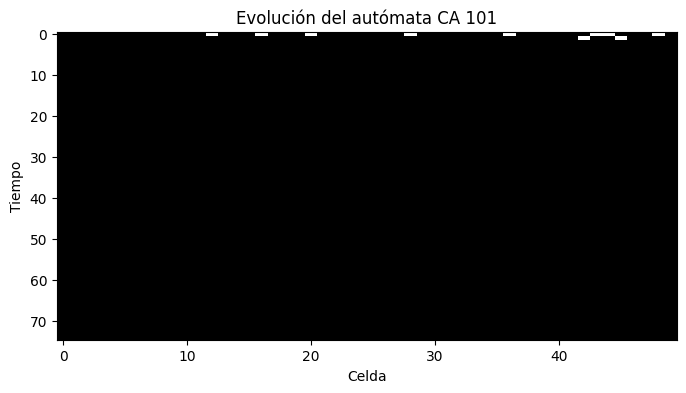

Estado uniforme final:  1


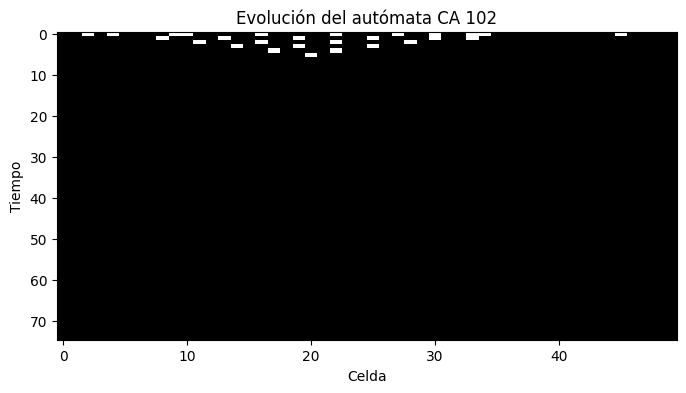

Estado uniforme final:  1


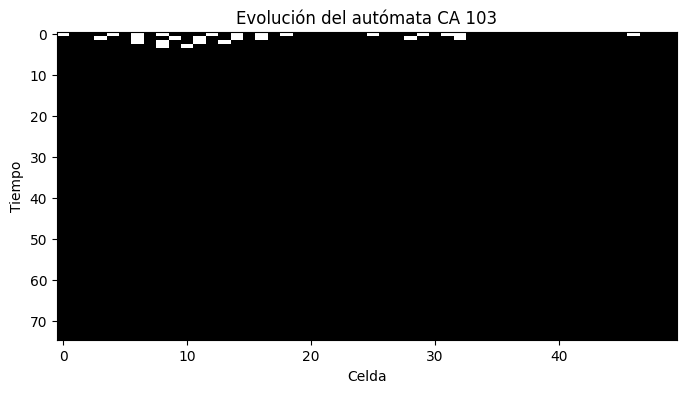

Estado uniforme final:  1


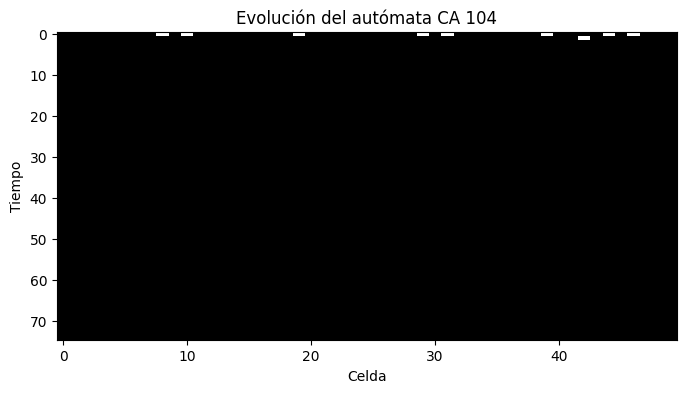

Estado uniforme final:  1


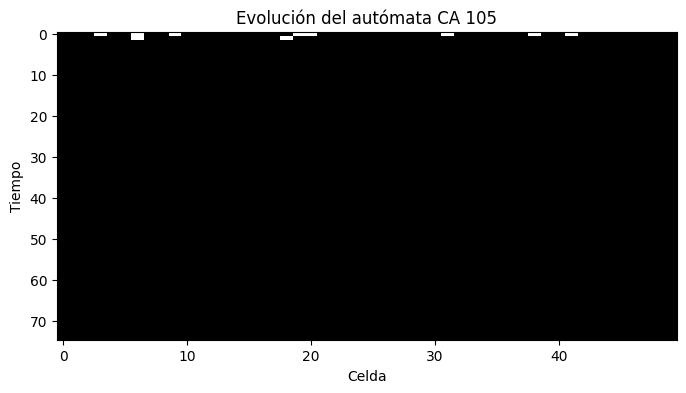

Estado uniforme final:  1


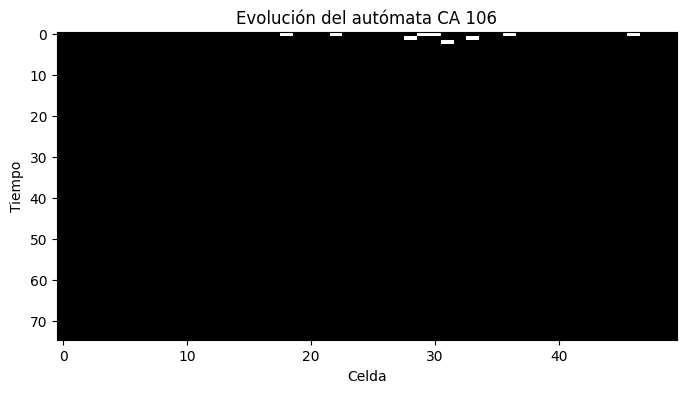

Estado uniforme final:  1


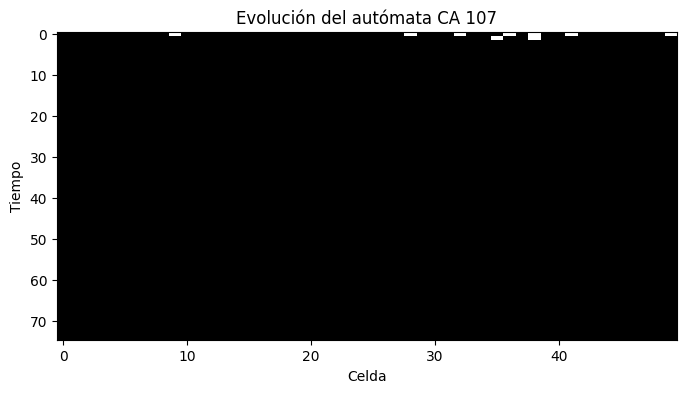

Estado uniforme final:  1


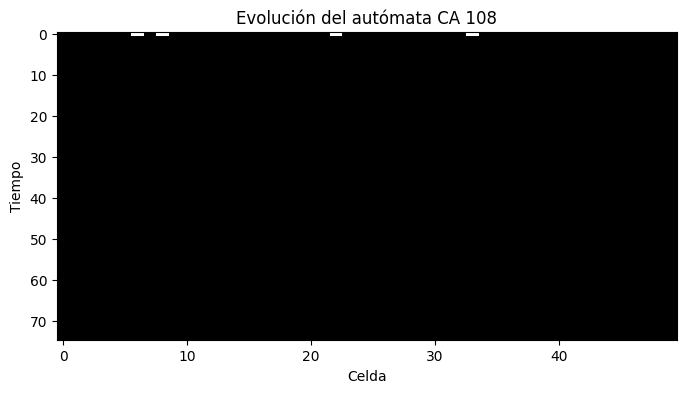

Estado uniforme final:  1


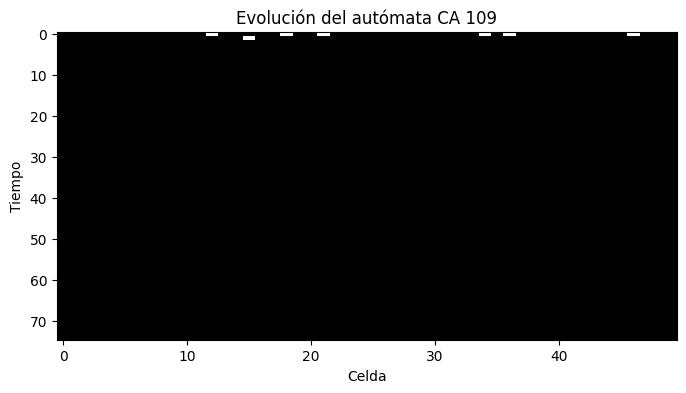

Estado uniforme final:  1


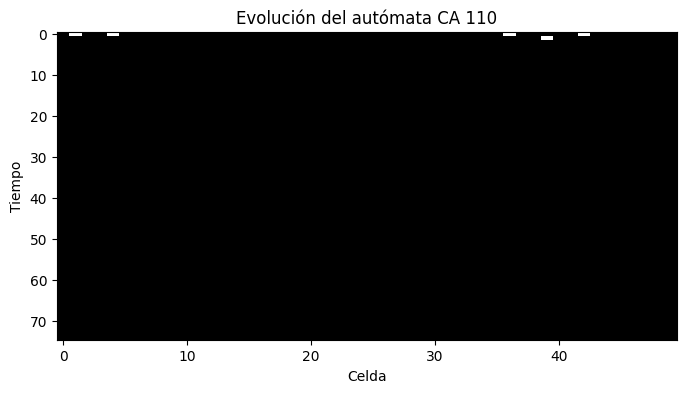

Estado uniforme final:  1


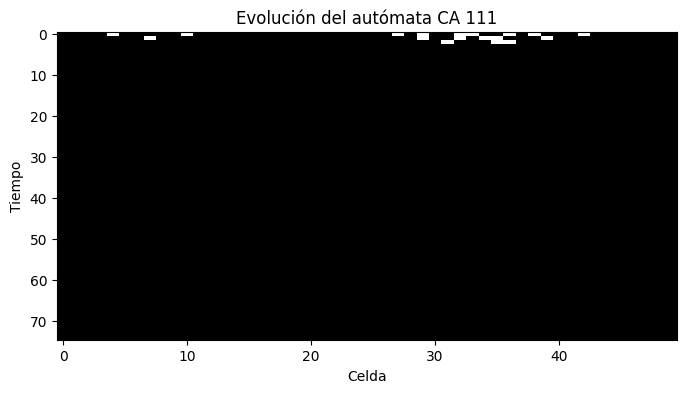

Estado uniforme final:  1


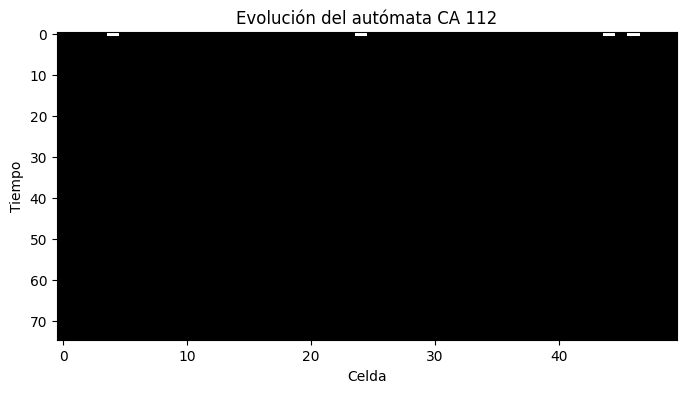

Estado uniforme final:  1


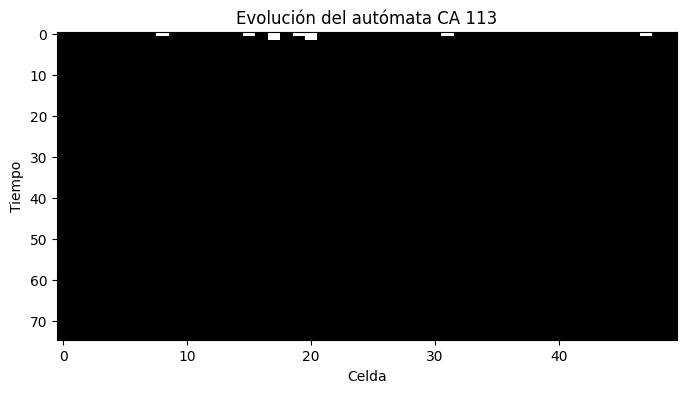

Estado uniforme final:  1


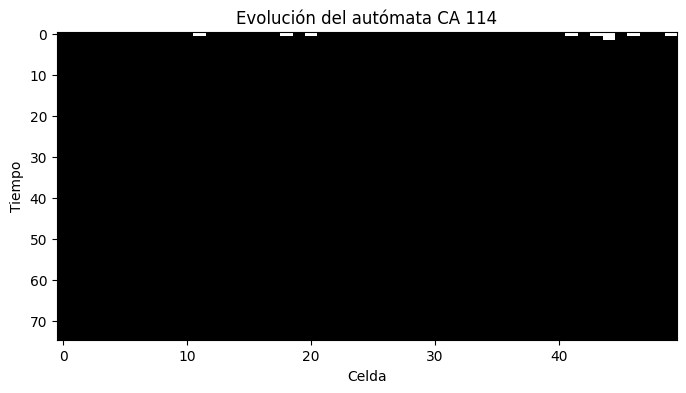

Estado uniforme final:  1


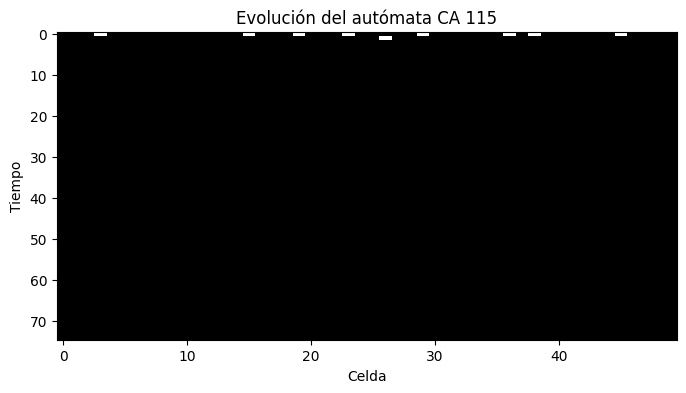

Estado uniforme final:  1


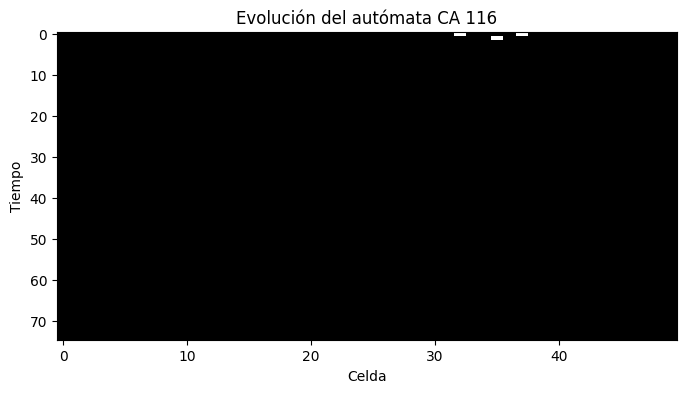

Estado uniforme final:  1


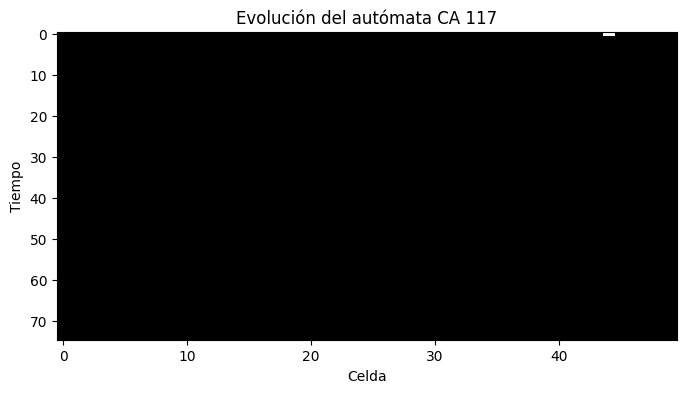

Estado uniforme final:  1


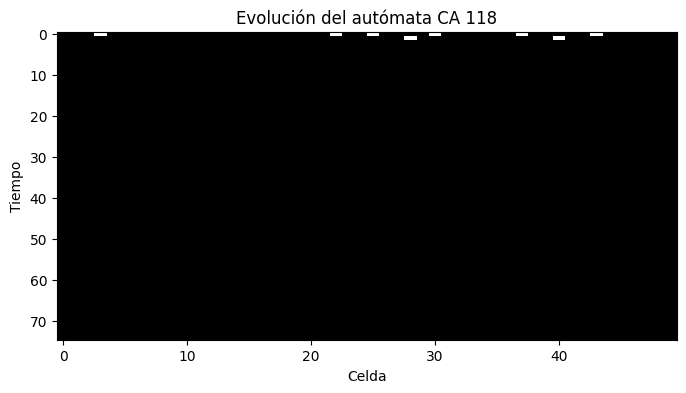

Estado uniforme final:  1


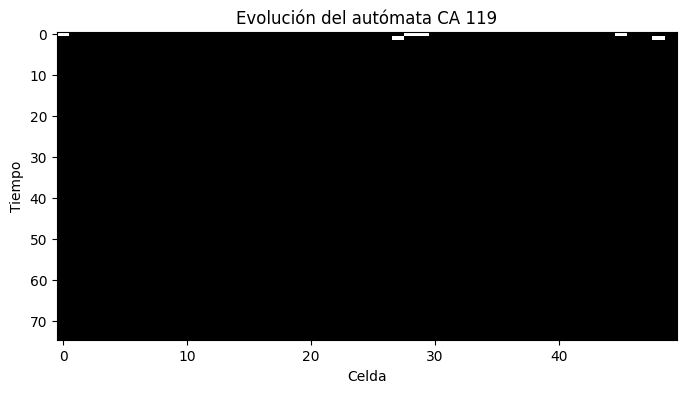

Estado uniforme final:  1


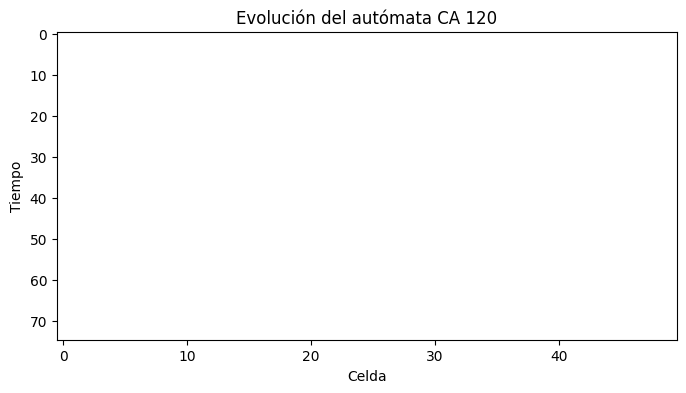

Estado uniforme final:  1


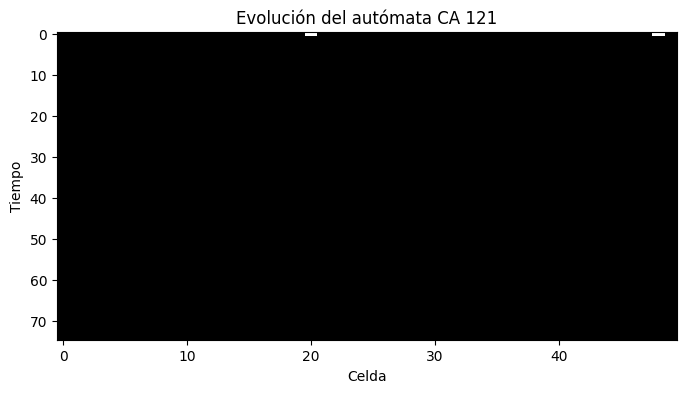

Estado uniforme final:  1


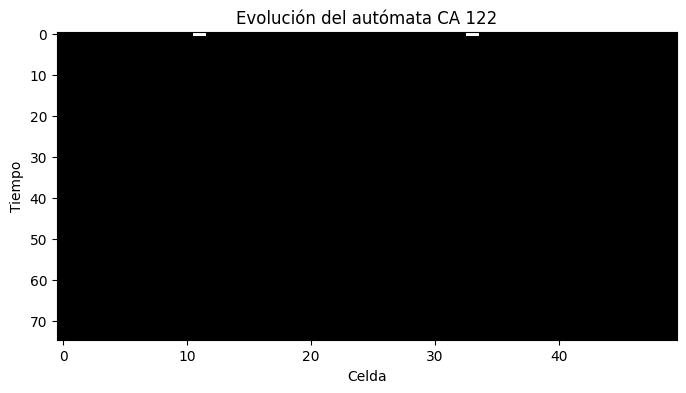

Estado uniforme final:  1


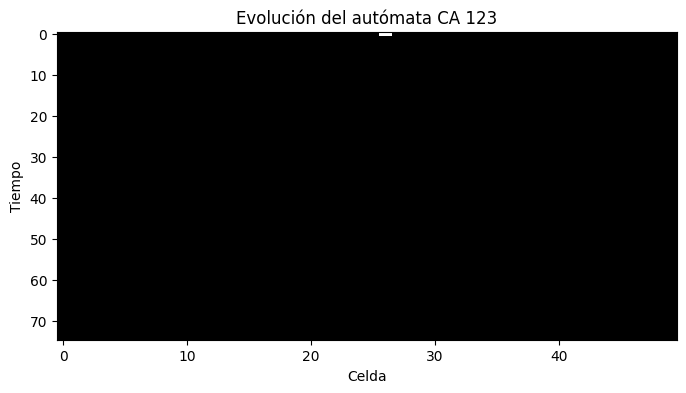

Estado uniforme final:  1


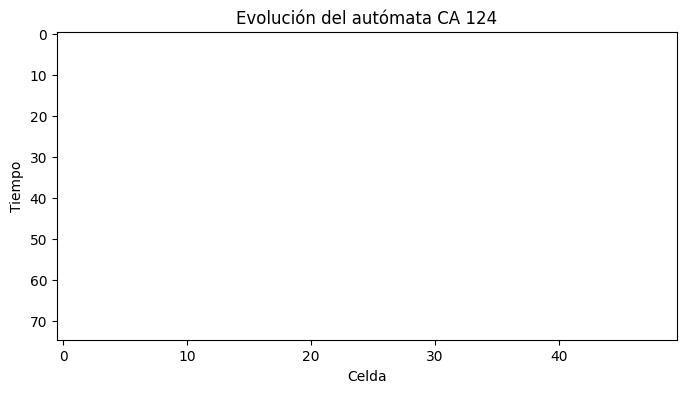

In [21]:
if __name__ == "__main__":
    top3 = GA()
    
    for individual in top3:
        regla = np.array(individual)
    
        # Símbolos para 0 y 1
        simbolo_0 = "□" # Cuadrado blanco
        simbolo_1 = "■" # Cuadrado negro
        
        print("--- Catálogo de Reglas del AC (Índice -> Configuración -> Resultado) ---")
        
        for indice in range(IND_SIZE):
            
            # 1. Obtener la configuración
            config_binaria_str = f'{indice:07b}'
            
            # 2. Convertir a símbolos visuales
            config_visual = "".join([simbolo_1 if b == '1' else simbolo_0 for b in config_binaria_str])
            
            # 3. Obtener el resultado
            resultado = regla[indice]
            resultado_visual = simbolo_1 if resultado == 1 else simbolo_0
            
            # 4. Imprimir la línea
            print(f"Índice {indice:03d}:   {config_visual}   ->   {resultado_visual}")
    
        print("Fitness alcanzado: ", individual.fitness.values[0])
        densities = np.linspace(0.0, 1.0, CA_NUM)
        CAs = []
    
    
        for i in range(CA_NUM):
            numbers = np.random.rand(CA_SIZE)
            ca_binario = (numbers <= densities[i]).astype(int)
            CAs.append(np.expand_dims(ca_binario, axis=0))
    
        majority = [1 if np.sum(ca) >= CA_SIZE/2 else 0 for ca in CAs]
    
    
        rule_dict = {}
        for i in range(len(individual)):
            binario = format(i, f'0{2*VEC_SIZE + 1}b')
            rule_dict[binario] = individual[i]
    
    
        mi_regla = create_transition_rule(rule_dict)
    
        #Evolucionarlos con la regla
        #Evolucionar y visualizar cada autómata
        CAs = Parallel(n_jobs=-1)(delayed(cpl.evolve)(CAs[i], timesteps=CA_TIMESTEPS,apply_rule=mi_regla,r=VEC_SIZE) for i in range(len(CAs)))
    
        for i in range(len(CAs)):
            print("Estado uniforme final: ", majority[i])
            plt.figure(figsize=(8, 4))
            plt.imshow(CAs[i], cmap='binary', interpolation='nearest', aspect='auto')
            plt.xlabel("Celda")
            plt.ylabel("Tiempo")
            plt.title(f"Evolución del autómata CA {i}")
            plt.show()


    PRUEBA 1: prueba a ciegas 
    
    PARÁMETROS:
    Parámetros AG
    IND_SIZE = int(pow(2, 2*VEC_SIZE + 1))
    POP_SIZE = 100
    CXPB, MUTPB, NGEN = 0.84, 0.01, 180

    Parámetros AC
    NUM_STATES = 2
    VEC_SIZE = 3
    CA_NUM = 100
    CA_SIZE = 40
    CA_TIMESTEPS = 80
    
    RESULTADOS:
    Fitness de los mejores cromosomas: 70%, 65%, 63%
    Sobran pasos de evolución, suficiente con 50 o 60
    Cierto patrón a expandir zonas con densidad de cierto color hacia un lado (derecha o izquierda). Negro se ve mejor que blanco?
    Los que no consigue clasificar se queda intercambiando casilla blanca con casilla negra, y hay bastantes falsos positivos negros.
    

    
    PRUEBA 2: autómátas pequeños
    
    PARÁMETROS:
    Parámetros AG
    IND_SIZE = int(pow(NUM_STATES, 2*VEC_SIZE + 1))
    POP_SIZE = 150
    CXPB, MUTPB, NGEN = 0.85, 0.03, 250

    Parámetros AC
    NUM_STATES = 2
    VEC_SIZE = 3
    CA_NUM = 100
    CA_SIZE = 20
    CA_TIMESTEPS = 40

    RESULTADOS:
    Fitness de los mejores cromosomas (simulando la regla con 100 autómátas nuevos): 93%, 90%, 89%
    Siguen sobrando Timesteps, en vez de hacer CA_TIMESTEPS = 2*CA_NUM, quizás mejor CA_TIMESTEPS = 1.5*CA_NUM
    Muy buen rendimiento del algoritmo


    PRUEBA 3: aumentamos tamaño del autómata
    Parámetros AG
    IND_SIZE = int(pow(NUM_STATES, 2*VEC_SIZE + 1))
    POP_SIZE = 180
    CXPB, MUTPB, NGEN = 0.85, 0.03, 320

    Parámetros AC
    NUM_STATES = 2
    VEC_SIZE = 3
    CA_NUM = 125
    CA_SIZE = 50
    CA_TIMESTEPS = 75

    RESULTADOS:
    Fitness de los mejores cromosomas: 97,6%, 97,6%, 96,8%
    En la mayoría siguen sobrando timesteps, pero los hay que requieren unas 50 iteraciones para llegar al estado uniforme, por lo que viene bien dejarles         alguna iteracion más para estudiar si consiguen estabilizarse.
    Gran rendimiento del algoritmo.
    
